<a href="https://colab.research.google.com/github/hazemmahmoudnasa/ASDC_Data_and_User_Services/blob/main/TEMPO_O2O2_Cloud_retrival.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ============================================================
# TEMPO CLOUD RETRIEVAL FROM L1B RADIANCES
# ============================================================
# Implements O2-O2 (477 nm) based cloud property retrieval
# Produces: Effective Cloud Fraction (ECF) &
#           Effective Cloud Pressure (ECP)
# ============================================================

!pip install earthaccess numpy scipy xarray netCDF4 rioxarray \
     matplotlib cartopy h5py h5netcdf

In [12]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.optimize import minimize, least_squares
from scipy.interpolate import RegularGridInterpolator
from scipy.signal import savgol_filter
from pathlib import Path
from datetime import datetime
import h5py
import earthaccess
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded")

✅ All libraries loaded


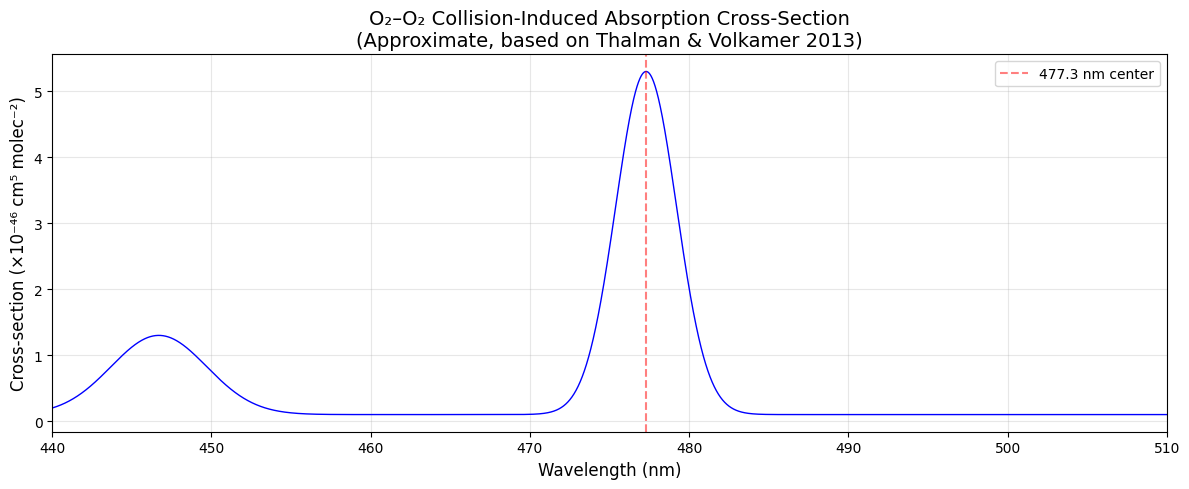

✅ O₂–O₂ cross-section generated


In [13]:
# ============================================================
# PHYSICAL CONSTANTS
# ============================================================

# Fundamental constants
N_LOSCHMIDT = 2.6868e19    # molecules/cm³ at STP
P_STD = 1013.25            # hPa standard pressure
T_STD = 273.15             # K standard temperature
R_EARTH = 6371.0           # km
H_SCALE = 7.5              # km atmospheric scale height
g0 = 9.80665               # m/s² gravity

# O2 mixing ratio (dry air)
O2_VMR = 0.2095

# ============================================================
# O2-O2 CROSS-SECTION (Collision Induced Absorption)
# Based on Thalman & Volkamer (2013)
# Units: cm⁵ molecule⁻²
# The O2-O2 CIA depends on [O2]² (pressure-squared dependence)
# ============================================================

def o2o2_cross_section(wavelength_nm):
    """
    Approximate O2-O2 collision-induced absorption cross-section
    near the 477 nm band.

    Based on Thalman & Volkamer (2013) parameterization.
    The 477 nm feature is the 1Δg + 1Δg ← 3Σg⁻ + 3Σg⁻ transition.

    Parameters:
        wavelength_nm: array of wavelengths in nm

    Returns:
        cross_section: cm⁵ molecule⁻²
    """
    wl = np.asarray(wavelength_nm, dtype=np.float64)

    # Center and width of the 477 nm O2-O2 band
    wl_center = 477.3   # nm - band center
    fwhm = 4.5          # nm - full width half max
    sigma_gauss = fwhm / (2 * np.sqrt(2 * np.log(2)))

    # Peak cross-section at 477 nm (~5.2e-46 cm⁵ molecule⁻²)
    peak_xs = 5.2e-46

    # Gaussian band shape (primary)
    xs = peak_xs * np.exp(-0.5 * ((wl - wl_center) / sigma_gauss) ** 2)

    # Add the weaker shoulder features
    # ~446 nm feature
    xs += 1.2e-46 * np.exp(-0.5 * ((wl - 446.7) / 3.0) ** 2)
    # ~532 nm feature
    xs += 0.8e-46 * np.exp(-0.5 * ((wl - 532.2) / 3.5) ** 2)
    # ~577 nm feature (1Σ+1Δ band)
    xs += 2.8e-46 * np.exp(-0.5 * ((wl - 577.2) / 4.0) ** 2)

    # Continuum baseline
    xs += 1.0e-47

    return xs

# Generate cross-section spectrum
wl_grid = np.arange(440, 510, 0.01)  # high-res wavelength grid
xs_o2o2 = o2o2_cross_section(wl_grid)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wl_grid, xs_o2o2 * 1e46, 'b-', linewidth=1)
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Cross-section (×10⁻⁴⁶ cm⁵ molec⁻²)', fontsize=12)
ax.set_title('O₂–O₂ Collision-Induced Absorption Cross-Section\n'
             '(Approximate, based on Thalman & Volkamer 2013)', fontsize=14)
ax.axvline(477.3, color='r', linestyle='--', alpha=0.5, label='477.3 nm center')
ax.set_xlim(440, 510)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('o2o2_cross_section.png', dpi=150)
plt.show()
print("✅ O₂–O₂ cross-section generated")

In [14]:
# ============================================================
# RAYLEIGH SCATTERING CROSS-SECTION
# Bodhaine et al. (1999)
# ============================================================

def rayleigh_cross_section(wavelength_nm):
    """
    Rayleigh scattering cross-section for air.
    Returns: cm² per molecule
    """
    wl_um = wavelength_nm / 1000.0  # convert to µm
    wl_cm = wavelength_nm * 1e-7     # convert to cm

    # Refractive index of air (Peck & Reeder 1972)
    # n - 1 parameterization
    wl2 = wl_um ** 2
    n_minus_1 = (5791817.0 / (238.0185 - 1.0/wl2) +
                 167909.0 / (57.362 - 1.0/wl2)) * 1e-8

    # King factor for air (depolarization)
    F_king = 1.0480 + 3.64e-3 / wl2

    # Rayleigh cross-section
    sigma = (24 * np.pi**3 / (N_LOSCHMIDT**2 * wl_cm**4) *
             ((n_minus_1)**2) * F_king)

    return sigma

# Verify at 550 nm (should be ~4.5e-27 cm²)
test_ray = rayleigh_cross_section(550.0)
print(f"Rayleigh σ at 550 nm: {test_ray:.3e} cm² (expect ~4.5e-27)")
print(f"Rayleigh σ at 477 nm: {rayleigh_cross_section(477.0):.3e} cm²")

Rayleigh σ at 550 nm: 9.217e-27 cm² (expect ~4.5e-27)
Rayleigh σ at 477 nm: 1.656e-26 cm²


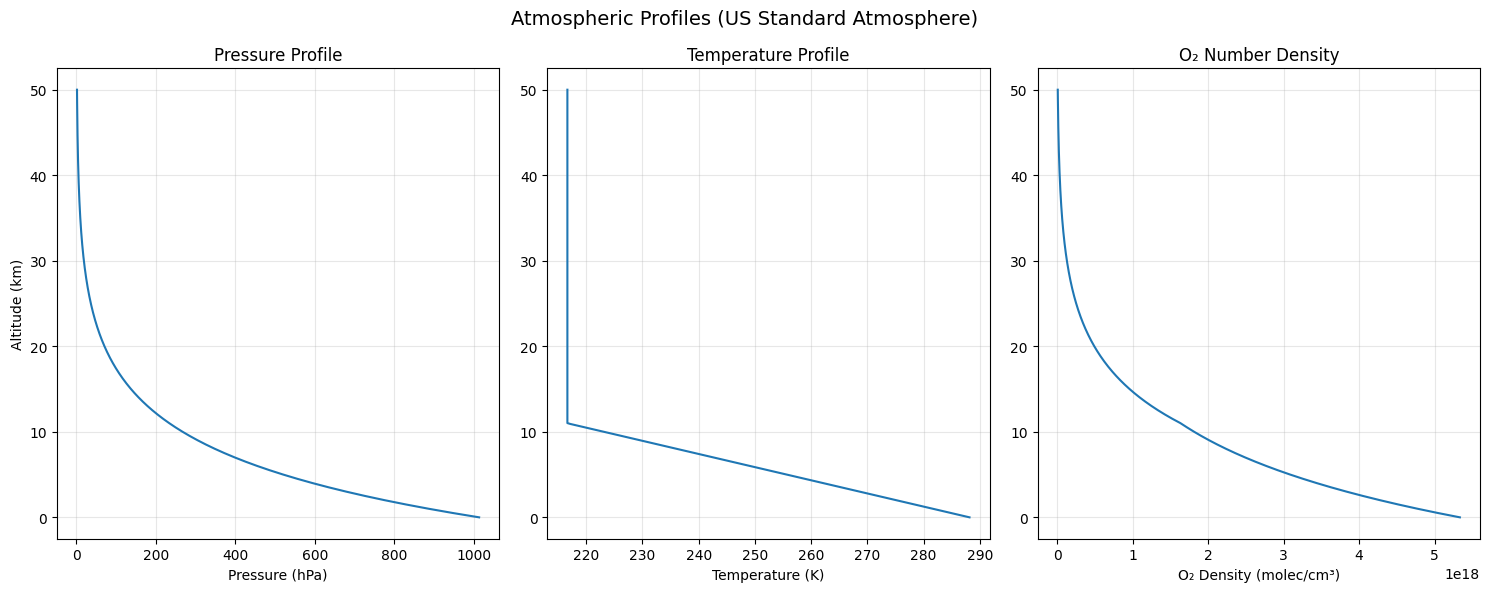

In [15]:
# ============================================================
# ATMOSPHERIC PROFILE MODEL
# US Standard Atmosphere approximation for pressure/temperature
# ============================================================

def pressure_profile(z_km):
    """Pressure at altitude z (km) using barometric formula"""
    return P_STD * np.exp(-z_km / H_SCALE)

def temperature_profile(z_km):
    """Temperature at altitude z (km) - simple lapse rate model"""
    z = np.asarray(z_km)
    T = np.where(z <= 11.0,
                 288.15 - 6.5 * z,           # troposphere
                 216.65)                       # tropopause/stratosphere
    return T

def air_number_density(z_km):
    """Number density of air molecules (molecules/cm³) at altitude z"""
    P = pressure_profile(z_km)
    T = temperature_profile(z_km)
    # Ideal gas: n = P / (kT), but using Loschmidt scaling
    n = N_LOSCHMIDT * (P / P_STD) * (T_STD / T)
    return n

def o2_number_density(z_km):
    """O2 number density at altitude z"""
    return O2_VMR * air_number_density(z_km)

# Vertical grid
z_grid = np.linspace(0, 50, 500)  # 0-50 km

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].plot(pressure_profile(z_grid), z_grid)
axes[0].set_xlabel('Pressure (hPa)'); axes[0].set_ylabel('Altitude (km)')
axes[0].set_title('Pressure Profile'); axes[0].grid(True, alpha=0.3)

axes[1].plot(temperature_profile(z_grid), z_grid)
axes[1].set_xlabel('Temperature (K)')
axes[1].set_title('Temperature Profile'); axes[1].grid(True, alpha=0.3)

axes[2].plot(o2_number_density(z_grid), z_grid)
axes[2].set_xlabel('O₂ Density (molec/cm³)')
axes[2].set_title('O₂ Number Density'); axes[2].grid(True, alpha=0.3)
axes[2].ticklabel_format(style='scientific', axis='x', scilimits=(0,0))

plt.suptitle('Atmospheric Profiles (US Standard Atmosphere)', fontsize=14)
plt.tight_layout()
plt.show()

Full atmosphere O₂-O₂ VCD: 1.2875e+43 molec² cm⁻⁵


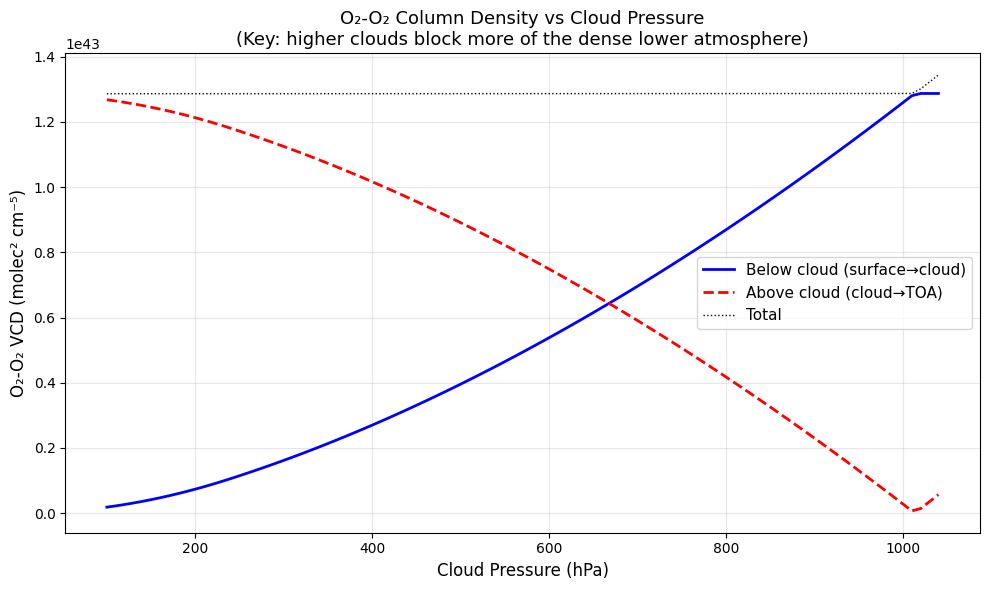


🔑 KEY INSIGHT: The VCD below the cloud drops sharply with decreasing
   cloud pressure (higher clouds). This is the basis of the retrieval!


In [16]:
# ============================================================
# O2-O2 VERTICAL COLUMN DENSITY (VCD)
#
# The O2-O2 CIA optical depth depends on the SQUARE of O2
# density integrated along the path:
#   τ_o2o2(λ) = σ_o2o2(λ) × ∫ [O2(z)]² dz
#
# Key insight: Since [O2]² ∝ P², the O2-O2 absorption is
# heavily weighted toward LOWER altitudes. This is why it's
# sensitive to cloud-top height — clouds block the view of
# the dense lower atmosphere.
# ============================================================

def compute_o2o2_vcd(surface_pressure_hPa, top_pressure_hPa=0.0, n_layers=200):
    """
    Compute O2-O2 vertical column density between two pressure levels.

    VCD = ∫ [O2(z)]² dz   (units: molecules² cm⁻⁵)

    Parameters:
        surface_pressure_hPa: bottom pressure level (hPa)
        top_pressure_hPa: top pressure level (hPa), default=TOA
        n_layers: number of integration layers

    Returns:
        vcd: O2-O2 VCD in molecules² cm⁻⁵
    """
    # Convert pressures to altitudes
    z_surface = -H_SCALE * np.log(surface_pressure_hPa / P_STD)
    z_top = -H_SCALE * np.log(max(top_pressure_hPa, 0.001) / P_STD)

    z_surface = max(z_surface, 0.0)
    z_top = min(z_top, 80.0)

    # Integration grid
    z = np.linspace(z_surface, z_top, n_layers)
    dz = np.abs(z[1] - z[0]) * 1e5  # convert km to cm

    # O2 number density squared
    n_o2 = o2_number_density(z)
    n_o2_squared = n_o2 ** 2

    # Integrate using trapezoidal rule
    vcd = np.trapz(n_o2_squared, dx=dz)

    return vcd

# Test: Full atmosphere VCD
vcd_full = compute_o2o2_vcd(1013.25, 0.0)
print(f"Full atmosphere O₂-O₂ VCD: {vcd_full:.4e} molec² cm⁻⁵")

# VCD as function of cloud pressure (integration from cloud to TOA)
cloud_pressures = np.arange(100, 1050, 10)
vcd_above_cloud = np.array([compute_o2o2_vcd(P_STD, cp) for cp in cloud_pressures])
vcd_below_cloud = np.array([compute_o2o2_vcd(cp, 0) for cp in cloud_pressures])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cloud_pressures, vcd_below_cloud, 'b-', linewidth=2, label='Below cloud (surface→cloud)')
ax.plot(cloud_pressures, vcd_above_cloud, 'r--', linewidth=2, label='Above cloud (cloud→TOA)')
ax.plot(cloud_pressures, vcd_below_cloud + vcd_above_cloud, 'k:', linewidth=1, label='Total')
ax.set_xlabel('Cloud Pressure (hPa)', fontsize=12)
ax.set_ylabel('O₂-O₂ VCD (molec² cm⁻⁵)', fontsize=12)
ax.set_title('O₂-O₂ Column Density vs Cloud Pressure\n'
             '(Key: higher clouds block more of the dense lower atmosphere)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
plt.tight_layout()
plt.savefig('o2o2_vcd_vs_cloud_pressure.png', dpi=150)
plt.show()

print("\n🔑 KEY INSIGHT: The VCD below the cloud drops sharply with decreasing")
print("   cloud pressure (higher clouds). This is the basis of the retrieval!")

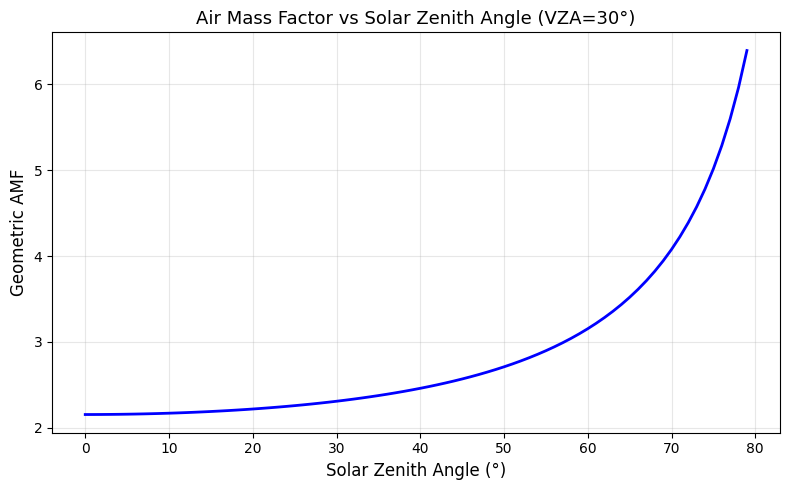

In [18]:
# ============================================================
# AIR MASS FACTOR (AMF) CALCULATION
#
# The geometric AMF relates VCD to Slant Column Density (SCD):
#   SCD = AMF × VCD
#
# For a simple geometric approximation:
#   AMF = 1/cos(SZA) + 1/cos(VZA)
#
# More accurate: wavelength-dependent AMF from scattering
# weights (would need full radiative transfer)
# ============================================================

def geometric_amf(sza_deg, vza_deg):
    """
    Simple geometric air mass factor.
    AMF = sec(SZA) + sec(VZA)
    """
    sza_rad = np.radians(np.clip(sza_deg, 0, 85))
    vza_rad = np.radians(np.clip(vza_deg, 0, 80))
    return 1.0 / np.cos(sza_rad) + 1.0 / np.cos(vza_rad)

def enhanced_amf(sza_deg, vza_deg, surface_albedo, surface_pressure_hPa,
                 cloud_pressure_hPa=None, cloud_fraction=0.0):
    """
    Enhanced AMF with first-order scattering correction.

    In the IPA framework:
    AMF_eff = (1-cf) × AMF_clear + cf × AMF_cloudy

    AMF_clear accounts for Rayleigh scattering reducing
    effective path length.
    AMF_cloudy uses the path only above cloud.
    """
    sza_r = np.radians(np.clip(sza_deg, 0, 85))
    vza_r = np.radians(np.clip(vza_deg, 0, 80))

    amf_geo = 1.0/np.cos(sza_r) + 1.0/np.cos(vza_r)

    # Rayleigh scattering correction factor (approximate)
    # Reduces effective AMF for low albedo scenes
    tau_ray_477 = rayleigh_cross_section(477.0) * N_LOSCHMIDT * H_SCALE * 1e5
    correction = np.exp(-tau_ray_477 * (1.0/np.cos(sza_r) - 1.0))

    # Clear-sky AMF
    albedo_factor = 1.0 + 0.2 * (surface_albedo - 0.05)  # higher albedo → more AMF
    amf_clear = amf_geo * correction * albedo_factor

    if cloud_pressure_hPa is not None and cloud_fraction > 0:
        # Cloudy AMF: path only goes to cloud top
        z_cloud = -H_SCALE * np.log(cloud_pressure_hPa / P_STD)
        z_surface = -H_SCALE * np.log(surface_pressure_hPa / P_STD)
        path_reduction = max(0.1, 1.0 - z_cloud / max(z_surface + 30, 30))
        amf_cloud = amf_geo * path_reduction * 1.2  # cloud albedo boost

        # IPA weighted AMF
        amf_eff = (1 - cloud_fraction) * amf_clear + cloud_fraction * amf_cloud
    else:
        amf_eff = amf_clear

    return amf_eff

# Demonstrate AMF dependence
szas = np.arange(0, 80, 1)
amfs = geometric_amf(szas, 30)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(szas, amfs, 'b-', linewidth=2)
ax.set_xlabel('Solar Zenith Angle (°)', fontsize=12)
ax.set_ylabel('Geometric AMF', fontsize=12)
ax.set_title('Air Mass Factor vs Solar Zenith Angle (VZA=30°)', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# LOOKUP TABLE (LUT) CONSTRUCTION
#
# For each combination of:
#   - Cloud Fraction (cf):    0.0 to 1.0
#   - Cloud Pressure (cp):    100 to 1013 hPa
#   - Solar Zenith Angle:     0° to 80°
#   - Viewing Zenith Angle:   0° to 70°
#   - Surface Albedo:         0.02 to 0.10
#   - Surface Pressure:       900 to 1013 hPa
#
# We compute the expected O2-O2 SCD using the IPA:
#   I_obs(λ) = cf × I_cloud(λ, cp) + (1-cf) × I_clear(λ, Ps)
#
# The O2-O2 SCD is what we compare to observations.
# ============================================================

print("⏳ Building Lookup Table... (this takes ~30 seconds)")

# LUT dimensions
cf_grid = np.arange(0.0, 1.01, 0.05)         # 21 points
cp_grid = np.arange(100, 1020, 25)            # ~37 points
sza_grid = np.arange(10, 81, 5)              # 15 points
vza_grid = np.array([0, 10, 20, 30, 40, 50, 60])  # 7 points
albedo_grid = np.array([0.02, 0.04, 0.06, 0.08, 0.10])  # 5 points
ps_grid = np.array([900, 950, 1013.25])       # 3 points

print(f"LUT dimensions:")
print(f"  Cloud fraction:  {len(cf_grid)} points [{cf_grid[0]:.2f} - {cf_grid[-1]:.2f}]")
print(f"  Cloud pressure:  {len(cp_grid)} points [{cp_grid[0]} - {cp_grid[-1]}] hPa")
print(f"  SZA:             {len(sza_grid)} points [{sza_grid[0]} - {sza_grid[-1]}]°")
print(f"  VZA:             {len(vza_grid)} points [{vza_grid[0]} - {vza_grid[-1]}]°")
print(f"  Surface albedo:  {len(albedo_grid)} points")
print(f"  Surface pressure:{len(ps_grid)} points")
total_entries = (len(cf_grid) * len(cp_grid) * len(sza_grid) *
                 len(vza_grid) * len(albedo_grid) * len(ps_grid))
print(f"  Total entries:   {total_entries:,}")

def compute_lut_entry(cf, cp_hPa, sza, vza, albedo, ps_hPa):
    """
    Compute expected O2-O2 SCD for given scene parameters
    using Independent Pixel Approximation (IPA).

    IPA: SCD_eff = cf × SCD_cloudy + (1-cf) × SCD_clear

    Where:
    - SCD_clear = AMF_clear × VCD(surface→TOA)
    - SCD_cloudy = AMF_cloudy × VCD(cloud→TOA)

    Returns:
        scd: effective O2-O2 slant column density
        radiance_ratio: I_obs / I_ref (continuum-normalized)
    """
    # VCD for clear sky: full column from surface to TOA
    vcd_clear = compute_o2o2_vcd(ps_hPa, 0.0)

    # VCD for cloudy: only above cloud top
    vcd_cloudy = compute_o2o2_vcd(ps_hPa, cp_hPa)

    # AMF
    amf_geo = geometric_amf(sza, vza)

    # Clear-sky AMF with scattering correction
    tau_scat = rayleigh_cross_section(477.0) * N_LOSCHMIDT * H_SCALE * 1e5
    sza_r = np.radians(min(sza, 85))
    scatter_corr = np.exp(-0.5 * tau_scat / np.cos(sza_r))
    amf_clear = amf_geo * scatter_corr * (0.95 + 0.5 * albedo)

    # Cloud AMF (reduced path - photons reflected at cloud top)
    frac_above = vcd_cloudy / max(vcd_clear, 1e10)
    amf_cloudy = amf_geo * (0.3 + 0.7 * frac_above) * 1.1  # cloud albedo ~0.8

    # SCD via IPA
    scd_clear_total = amf_clear * vcd_clear
    scd_cloudy_total = amf_cloudy * vcd_cloudy
    scd_eff = (1.0 - cf) * scd_clear_total + cf * scd_cloudy_total

    # Approximate the continuum-normalized radiance ratio
    # In the O2-O2 band: I(477)/I_cont ≈ exp(-τ_o2o2)
    # τ_o2o2 = σ_o2o2(477) × SCD
    tau_o2o2 = o2o2_cross_section(477.3) * scd_eff
    radiance_ratio = np.exp(-tau_o2o2)

    return scd_eff, radiance_ratio

# Build the LUT
LUT_SCD = np.zeros((len(cf_grid), len(cp_grid), len(sza_grid),
                     len(vza_grid), len(albedo_grid), len(ps_grid)))
LUT_RATIO = np.zeros_like(LUT_SCD)

import time
t0 = time.time()

for i_cf, cf in enumerate(cf_grid):
    for i_cp, cp in enumerate(cp_grid):
        for i_sza, sza in enumerate(sza_grid):
            for i_vza, vza in enumerate(vza_grid):
                for i_alb, alb in enumerate(albedo_grid):
                    for i_ps, ps in enumerate(ps_grid):
                        scd, ratio = compute_lut_entry(cf, cp, sza, vza, alb, ps)
                        LUT_SCD[i_cf, i_cp, i_sza, i_vza, i_alb, i_ps] = scd
                        LUT_RATIO[i_cf, i_cp, i_sza, i_vza, i_alb, i_ps] = ratio

elapsed = time.time() - t0
print(f"\n✅ LUT built in {elapsed:.1f} seconds")
print(f"   SCD range:   [{LUT_SCD.min():.4e}, {LUT_SCD.max():.4e}] molec² cm⁻⁵")
print(f"   Ratio range: [{LUT_RATIO.min():.4f}, {LUT_RATIO.max():.4f}]")

⏳ Building Lookup Table... (this takes ~30 seconds)
LUT dimensions:
  Cloud fraction:  21 points [0.00 - 1.00]
  Cloud pressure:  37 points [100 - 1000] hPa
  SZA:             15 points [10 - 80]°
  VZA:             7 points [0 - 60]°
  Surface albedo:  5 points
  Surface pressure:3 points
  Total entries:   1,223,775

✅ LUT built in 301.8 seconds
   SCD range:   [0.0000e+00, 1.0711e+44] molec² cm⁻⁵
   Ratio range: [0.9448, 1.0000]


✅ LUT Interpolation Test:
   cf=0.3, cp=500 hPa, SZA=40°, VZA=20°, albedo=0.04, Ps=1013 hPa
   → SCD = 2.2124e+43 molec² cm⁻⁵
   → Radiance Ratio = 0.988343


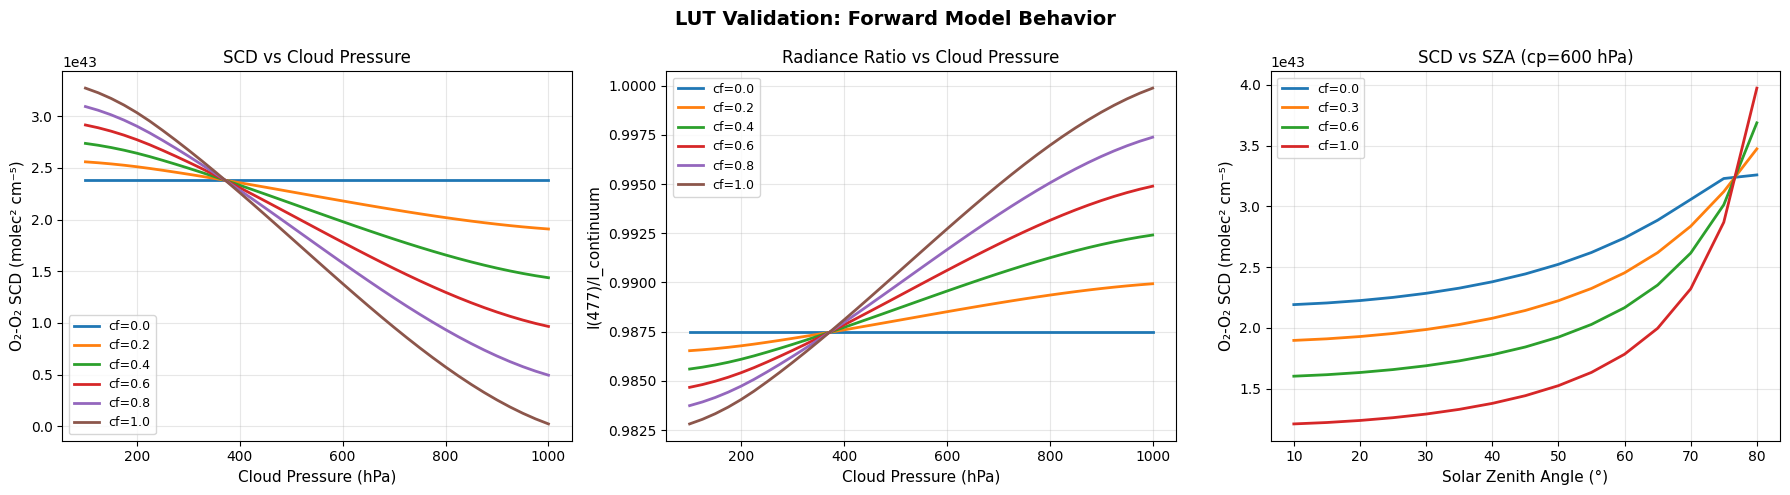

✅ LUT interpolation engine ready


In [21]:
# ============================================================
# LUT INTERPOLATION ENGINE
# ============================================================

# Build scipy RegularGridInterpolators for fast lookup
lut_scd_interp = RegularGridInterpolator(
    (cf_grid, cp_grid, sza_grid, vza_grid, albedo_grid, ps_grid),
    LUT_SCD,
    method='linear',
    bounds_error=False,
    fill_value=None
)

lut_ratio_interp = RegularGridInterpolator(
    (cf_grid, cp_grid, sza_grid, vza_grid, albedo_grid, ps_grid),
    LUT_RATIO,
    method='linear',
    bounds_error=False,
    fill_value=None
)

def lut_forward_model(cf, cp, sza, vza, albedo, ps):
    """
    Forward model: given scene parameters, return expected O2-O2 SCD and ratio.
    Uses LUT interpolation.
    """
    # Clip to LUT bounds
    cf_c = np.clip(cf, cf_grid[0], cf_grid[-1])
    cp_c = np.clip(cp, cp_grid[0], cp_grid[-1])
    sza_c = np.clip(sza, sza_grid[0], sza_grid[-1])
    vza_c = np.clip(vza, vza_grid[0], vza_grid[-1])
    alb_c = np.clip(albedo, albedo_grid[0], albedo_grid[-1])
    ps_c = np.clip(ps, ps_grid[0], ps_grid[-1])

    point = np.array([cf_c, cp_c, sza_c, vza_c, alb_c, ps_c])

    scd = float(lut_scd_interp(point.reshape(1, -1)))
    ratio = float(lut_ratio_interp(point.reshape(1, -1)))

    return scd, ratio

def lut_forward_model_batch(cf_arr, cp_arr, sza_arr, vza_arr, albedo_arr, ps_arr):
    """
    Vectorized forward model for arrays of scene parameters.
    """
    cf_c = np.clip(cf_arr, cf_grid[0], cf_grid[-1])
    cp_c = np.clip(cp_arr, cp_grid[0], cp_grid[-1])
    sza_c = np.clip(sza_arr, sza_grid[0], sza_grid[-1])
    vza_c = np.clip(vza_arr, vza_grid[0], vza_grid[-1])
    alb_c = np.clip(albedo_arr, albedo_grid[0], albedo_grid[-1])
    ps_c = np.clip(ps_arr, ps_grid[0], ps_grid[-1])

    points = np.column_stack([cf_c, cp_c, sza_c, vza_c, alb_c, ps_c])

    scd = lut_scd_interp(points)
    ratio = lut_ratio_interp(points)

    return scd, ratio

# Validate interpolation
test_scd, test_ratio = lut_forward_model(0.3, 500.0, 40.0, 20.0, 0.04, 1013.25)
print(f"✅ LUT Interpolation Test:")
print(f"   cf=0.3, cp=500 hPa, SZA=40°, VZA=20°, albedo=0.04, Ps=1013 hPa")
print(f"   → SCD = {test_scd:.4e} molec² cm⁻⁵")
print(f"   → Radiance Ratio = {test_ratio:.6f}")

# Visualize LUT slices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Slice 1: SCD vs cloud pressure for different cloud fractions
ax1 = axes[0]
for cf_test in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    scds = []
    for cp_test in cp_grid:
        s, _ = lut_forward_model(cf_test, cp_test, 40.0, 20.0, 0.04, 1013.25)
        scds.append(s)
    ax1.plot(cp_grid, scds, label=f'cf={cf_test:.1f}', linewidth=2)
ax1.set_xlabel('Cloud Pressure (hPa)', fontsize=11)
ax1.set_ylabel('O₂-O₂ SCD (molec² cm⁻⁵)', fontsize=11)
ax1.set_title('SCD vs Cloud Pressure', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Slice 2: Radiance ratio vs cloud pressure
ax2 = axes[1]
for cf_test in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    ratios = []
    for cp_test in cp_grid:
        _, r = lut_forward_model(cf_test, cp_test, 40.0, 20.0, 0.04, 1013.25)
        ratios.append(r)
    ax2.plot(cp_grid, ratios, label=f'cf={cf_test:.1f}', linewidth=2)
ax2.set_xlabel('Cloud Pressure (hPa)', fontsize=11)
ax2.set_ylabel('I(477)/I_continuum', fontsize=11)
ax2.set_title('Radiance Ratio vs Cloud Pressure', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Slice 3: SCD vs SZA for different cloud fractions
ax3 = axes[2]
for cf_test in [0.0, 0.3, 0.6, 1.0]:
    scds = []
    for sza_test in sza_grid:
        s, _ = lut_forward_model(cf_test, 600.0, sza_test, 20.0, 0.04, 1013.25)
        scds.append(s)
    ax3.plot(sza_grid, scds, label=f'cf={cf_test:.1f}', linewidth=2)
ax3.set_xlabel('Solar Zenith Angle (°)', fontsize=11)
ax3.set_ylabel('O₂-O₂ SCD (molec² cm⁻⁵)', fontsize=11)
ax3.set_title('SCD vs SZA (cp=600 hPa)', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.suptitle('LUT Validation: Forward Model Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lut_validation.png', dpi=150)
plt.show()
print("✅ LUT interpolation engine ready")

In [22]:
# ============================================================
# DIFFERENTIAL OPTICAL ABSORPTION SPECTROSCOPY (DOAS)
# SPECTRAL FITTING MODULE
#
# The DOAS technique fits the observed log-ratio spectrum:
#   ln(I_ref/I_obs) = Σ σ_j(λ) × SCD_j + Σ a_k × λ^k
#
# Where:
#   σ_j = absorption cross-section of species j
#   SCD_j = slant column density of species j
#   a_k = polynomial coefficients (broad-band features)
#
# For cloud retrieval, the key absorber is O2-O2 at 477 nm.
# ============================================================

class DOASFitter:
    """
    DOAS spectral fitting engine for O2-O2 retrieval.

    Fits observed optical density spectrum to derive
    O2-O2 slant column density.
    """

    def __init__(self, wavelength_nm, polynomial_degree=3):
        """
        Parameters:
            wavelength_nm: wavelength grid (nm)
            polynomial_degree: degree of closure polynomial
        """
        self.wl = np.asarray(wavelength_nm, dtype=np.float64)
        self.n_wl = len(self.wl)
        self.poly_degree = polynomial_degree

        # Reference wavelength for polynomial normalization
        self.wl_ref = np.mean(self.wl)
        self.wl_norm = (self.wl - self.wl_ref) / (self.wl[-1] - self.wl[0])

        # O2-O2 differential cross-section (high-pass filtered)
        self.xs_o2o2_raw = o2o2_cross_section(self.wl)
        self.xs_o2o2_diff = self._highpass_filter(self.xs_o2o2_raw)

        # Rayleigh cross-section (for Ring effect proxy)
        self.xs_rayleigh = rayleigh_cross_section(self.wl)
        self.xs_rayleigh_diff = self._highpass_filter(self.xs_rayleigh)

        # Build the design matrix
        self._build_design_matrix()

    def _highpass_filter(self, spectrum):
        """
        Remove broadband features via polynomial subtraction.
        This is the 'differential' part of DOAS.
        """
        coeffs = np.polyfit(self.wl_norm, spectrum, self.poly_degree)
        broadband = np.polyval(coeffs, self.wl_norm)
        return spectrum - broadband

    def _build_design_matrix(self):
        """
        Build the linear regression design matrix:
        Columns = [σ_o2o2_diff, σ_ring_diff, λ^0, λ^1, ..., λ^n]
        """
        n_absorbers = 2  # O2-O2 and Ring proxy
        n_poly = self.poly_degree + 1
        n_cols = n_absorbers + n_poly

        A = np.zeros((self.n_wl, n_cols))

        # Absorber cross-sections (differential)
        A[:, 0] = self.xs_o2o2_diff     # O2-O2
        A[:, 1] = self.xs_rayleigh_diff  # Ring effect proxy

        # Polynomial terms
        for k in range(n_poly):
            A[:, n_absorbers + k] = self.wl_norm ** k

        self.design_matrix = A
        self.n_absorbers = n_absorbers
        self.n_poly = n_poly

    def fit(self, radiance, irradiance, uncertainty=None):
        """
        Perform DOAS fit on observed radiance.

        Parameters:
            radiance: observed earthshine radiance I(λ)
            irradiance: reference solar irradiance I_0(λ)
                        (or clear-sky reference)
            uncertainty: measurement uncertainty (optional)

        Returns:
            result: dict with SCD, fit quality, residuals
        """
        # Compute optical density (log ratio)
        # Avoid log(0) or log(negative)
        ratio = np.clip(radiance / np.maximum(irradiance, 1e-30), 1e-10, None)
        optical_density = -np.log(ratio)

        # Apply high-pass filter to observed OD
        od_diff = self._highpass_filter(optical_density)

        # Weight matrix (if uncertainty provided)
        if uncertainty is not None:
            # Propagate uncertainty to OD space
            w = 1.0 / np.maximum(uncertainty / np.maximum(radiance, 1e-30), 1e-10)
            W = np.diag(w)

            # Weighted least squares: (A^T W A)^-1 A^T W y
            ATWA = self.design_matrix.T @ W @ self.design_matrix
            ATWy = self.design_matrix.T @ W @ od_diff
        else:
            # Ordinary least squares
            ATWA = self.design_matrix.T @ self.design_matrix
            ATWy = self.design_matrix.T @ od_diff

        # Add Tikhonov regularization (small)
        reg = 1e-12 * np.eye(ATWA.shape[0])

        try:
            coefficients = np.linalg.solve(ATWA + reg, ATWy)
        except np.linalg.LinAlgError:
            coefficients = np.linalg.lstsq(self.design_matrix, od_diff, rcond=None)[0]

        # Extract results
        scd_o2o2 = coefficients[0]    # O2-O2 slant column density
        scd_ring = coefficients[1]    # Ring effect amplitude
        poly_coeffs = coefficients[2:]

        # Compute fit and residuals
        od_fit = self.design_matrix @ coefficients
        residuals = od_diff - od_fit
        rms_residual = np.sqrt(np.mean(residuals ** 2))

        # Chi-squared
        dof = self.n_wl - len(coefficients)
        chi2 = np.sum(residuals**2) / max(dof, 1)

        # SCD uncertainty (from covariance matrix)
        try:
            cov = np.linalg.inv(ATWA + reg) * chi2
            scd_o2o2_err = np.sqrt(max(cov[0, 0], 0))
            scd_ring_err = np.sqrt(max(cov[1, 1], 0))
        except:
            scd_o2o2_err = np.nan
            scd_ring_err = np.nan

        result = {
            'scd_o2o2': scd_o2o2,
            'scd_o2o2_err': scd_o2o2_err,
            'scd_ring': scd_ring,
            'scd_ring_err': scd_ring_err,
            'poly_coeffs': poly_coeffs,
            'rms_residual': rms_residual,
            'chi_squared': chi2,
            'optical_density': optical_density,
            'od_differential': od_diff,
            'od_fit': od_fit,
            'residuals': residuals,
            'coefficients': coefficients
        }

        return result

    def plot_fit(self, result, title="DOAS Fit"):
        """Visualize the DOAS fit result"""
        fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

        # Panel 1: Optical density
        ax1 = axes[0]
        ax1.plot(self.wl, result['optical_density'], 'b-',
                 linewidth=1, label='Observed OD')
        ax1.set_ylabel('Optical Density', fontsize=11)
        ax1.set_title(title, fontsize=13, fontweight='bold')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Panel 2: Differential OD + fit
        ax2 = axes[1]
        ax2.plot(self.wl, result['od_differential'], 'b-',
                 linewidth=1.5, label='Observed (differential)', alpha=0.7)
        ax2.plot(self.wl, result['od_fit'], 'r-',
                 linewidth=2, label='DOAS fit')

        # Show O2-O2 contribution
        o2o2_contribution = self.xs_o2o2_diff * result['scd_o2o2']
        ax2.plot(self.wl, o2o2_contribution, 'g--',
                 linewidth=1.5, label=f'O₂-O₂ (SCD={result["scd_o2o2"]:.3e})')

        ax2.set_ylabel('Differential OD', fontsize=11)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)

        # Panel 3: Residuals
        ax3 = axes[2]
        ax3.plot(self.wl, result['residuals'], 'k-', linewidth=0.8)
        ax3.axhline(0, color='r', linestyle='--', alpha=0.5)
        ax3.fill_between(self.wl, -result['rms_residual'], result['rms_residual'],
                         alpha=0.2, color='red', label=f'RMS={result["rms_residual"]:.2e}')
        ax3.set_xlabel('Wavelength (nm)', fontsize=11)
        ax3.set_ylabel('Residual', fontsize=11)
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        plt.tight_layout()
        return fig


# Test the DOAS fitter
print("✅ DOAS fitting module initialized")
print(f"   Wavelength range: {wl_grid[0]:.1f} - {wl_grid[-1]:.1f} nm")
print(f"   Polynomial degree: 3")
print(f"   Number of spectral points: {len(wl_grid)}")

✅ DOAS fitting module initialized
   Wavelength range: 440.0 - 510.0 nm
   Polynomial degree: 3
   Number of spectral points: 7000


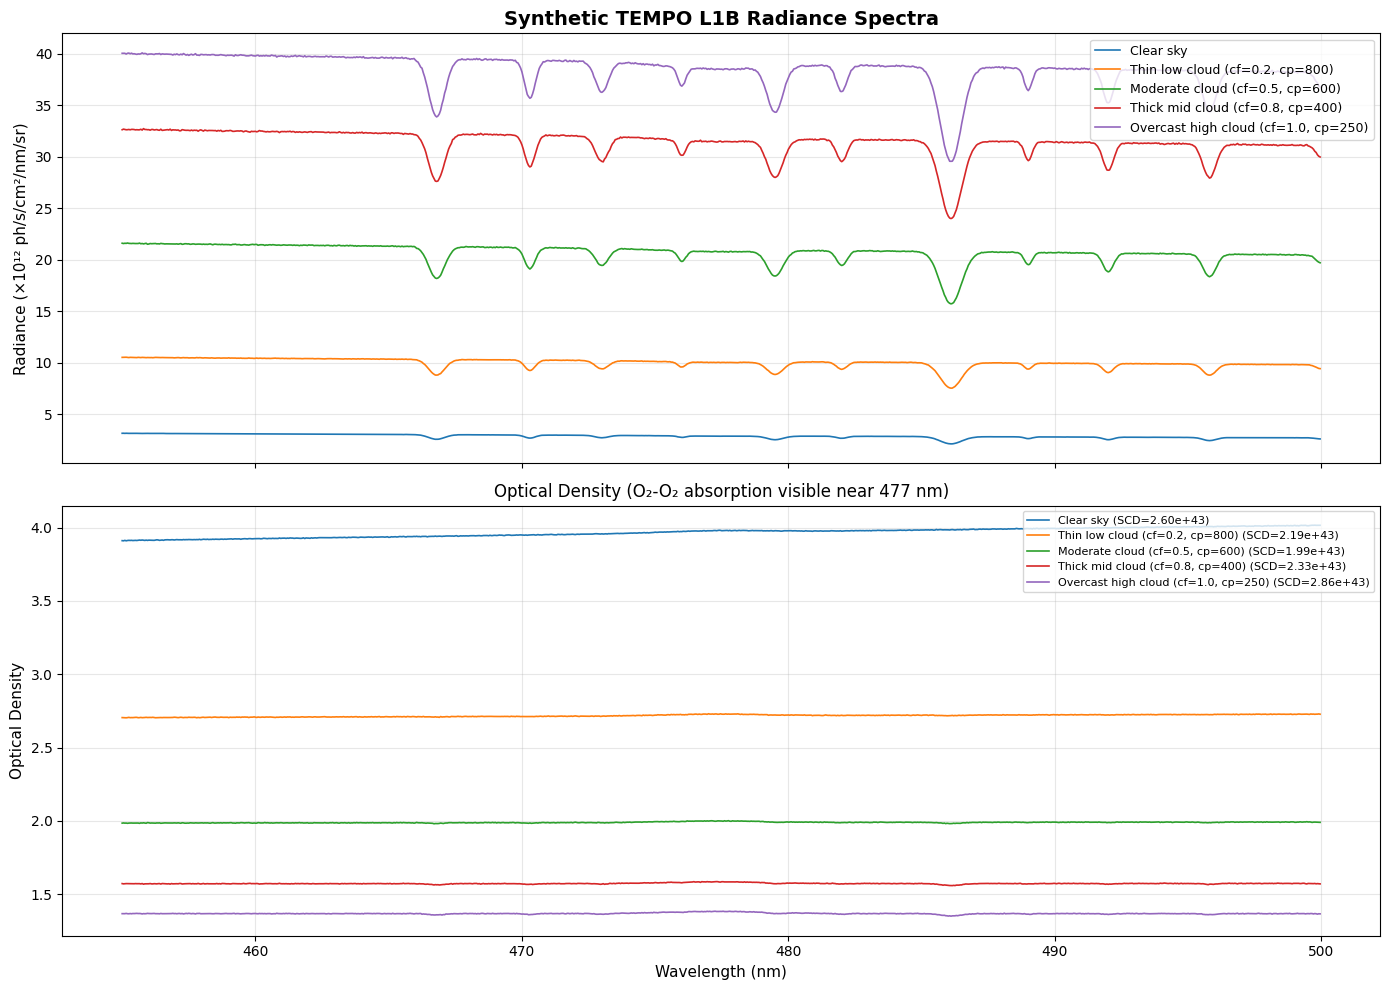

✅ Synthetic spectra generated and visualized


In [23]:
# ============================================================
# SYNTHETIC SPECTRUM GENERATOR
# Used to test the retrieval before applying to real L1B data
# ============================================================

def generate_synthetic_spectrum(wavelength_nm, sza, vza,
                                 cloud_fraction, cloud_pressure_hPa,
                                 surface_pressure_hPa=1013.25,
                                 surface_albedo=0.04,
                                 noise_level=0.001):
    """
    Generate synthetic TEMPO-like L1B radiance spectrum in
    the O2-O2 band including:
    - Solar Fraunhofer structure (simplified)
    - O2-O2 absorption
    - Rayleigh scattering continuum
    - Ring effect
    - Photon noise

    Parameters:
        wavelength_nm: wavelength grid
        sza, vza: solar/viewing zenith angles (degrees)
        cloud_fraction: effective cloud fraction [0-1]
        cloud_pressure_hPa: cloud-top pressure (hPa)
        surface_pressure_hPa: surface pressure
        surface_albedo: surface Lambertian albedo
        noise_level: fractional noise (1σ)

    Returns:
        irradiance: solar reference spectrum (I_0)
        radiance: earthshine spectrum (I)
        true_scd: true O2-O2 SCD
    """
    wl = np.asarray(wavelength_nm, dtype=np.float64)

    # --- Solar irradiance (simplified with Fraunhofer lines) ---
    # Broad continuum
    I0_continuum = 1.5e14 * (wl / 500.0) ** (-0.5)  # photons/s/cm²/nm

    # Add simplified Fraunhofer absorption lines
    fraunhofer_lines = [
        (466.8, 0.15, 0.3),  # position, depth, width(nm)
        (470.3, 0.10, 0.2),
        (473.0, 0.08, 0.25),
        (476.0, 0.05, 0.15),
        (479.5, 0.12, 0.3),
        (482.0, 0.07, 0.2),
        (486.1, 0.25, 0.4),  # Hβ
        (489.0, 0.06, 0.15),
        (492.0, 0.09, 0.2),
        (495.8, 0.11, 0.25),
        (500.0, 0.04, 0.2),
    ]

    fraunhofer_absorption = np.ones_like(wl)
    for pos, depth, width in fraunhofer_lines:
        fraunhofer_absorption -= depth * np.exp(-0.5 * ((wl - pos) / width) ** 2)

    I0 = I0_continuum * fraunhofer_absorption

    # --- Compute O2-O2 absorption ---
    sza_r = np.radians(min(sza, 85))
    vza_r = np.radians(min(vza, 80))
    amf_geo = 1.0 / np.cos(sza_r) + 1.0 / np.cos(vza_r)

    # Clear-sky O2-O2 SCD
    vcd_clear = compute_o2o2_vcd(surface_pressure_hPa, 0.0)
    vcd_above_cloud = compute_o2o2_vcd(surface_pressure_hPa, cloud_pressure_hPa)

    # Scattering correction
    tau_ray = rayleigh_cross_section(477.0) * N_LOSCHMIDT * H_SCALE * 1e5
    scatter_corr = np.exp(-0.3 * tau_ray / np.cos(sza_r))

    amf_clear = amf_geo * scatter_corr * (0.95 + 0.5 * surface_albedo)
    frac_above = vcd_above_cloud / max(vcd_clear, 1e10)
    amf_cloudy = amf_geo * (0.3 + 0.7 * frac_above) * 1.1

    scd_clear = amf_clear * vcd_clear
    scd_cloudy = amf_cloudy * vcd_above_cloud

    # IPA: effective SCD
    true_scd = (1.0 - cloud_fraction) * scd_clear + cloud_fraction * scd_cloudy

    # O2-O2 optical depth spectrum
    xs_o2o2 = o2o2_cross_section(wl)
    tau_o2o2 = xs_o2o2 * true_scd

    # --- Rayleigh scattering optical depth ---
    xs_ray = rayleigh_cross_section(wl)
    column_air = N_LOSCHMIDT * H_SCALE * 1e5  # total air column
    tau_rayleigh = xs_ray * column_air * amf_geo * 0.5  # approximate

    # --- Scene reflectance ---
    # Clear-sky reflectance
    R_clear = surface_albedo * np.exp(-tau_rayleigh) + \
              (1 - np.exp(-tau_rayleigh)) * 0.1  # Rayleigh + surface

    # Cloud reflectance
    R_cloud = 0.8  # bright cloud

    # IPA reflectance
    R_eff = (1 - cloud_fraction) * R_clear + cloud_fraction * R_cloud

    # --- Ring effect (filling-in of Fraunhofer lines) ---
    ring_amplitude = 0.02 * R_eff
    ring_spectrum = ring_amplitude * (1.0 - fraunhofer_absorption) / max(
        np.max(1.0 - fraunhofer_absorption), 0.01)

    # --- Assemble earthshine radiance ---
    # I = I0 × R_eff × T_o2o2 × T_ring + noise
    T_o2o2 = np.exp(-tau_o2o2)

    radiance = I0 * R_eff * T_o2o2 * (1.0 + ring_spectrum) / np.pi

    # Add photon noise
    if noise_level > 0:
        noise = np.random.normal(0, noise_level * radiance)
        radiance = radiance + noise
        radiance = np.maximum(radiance, 1e-10)  # prevent negatives

    return I0, radiance, true_scd

# ============================================================
# Generate test spectra for several scenes
# ============================================================
wl_test = np.arange(455, 500, 0.05)  # TEMPO-like resolution

test_scenes = [
    {'cf': 0.0,  'cp': 1013, 'label': 'Clear sky'},
    {'cf': 0.2,  'cp': 800,  'label': 'Thin low cloud (cf=0.2, cp=800)'},
    {'cf': 0.5,  'cp': 600,  'label': 'Moderate cloud (cf=0.5, cp=600)'},
    {'cf': 0.8,  'cp': 400,  'label': 'Thick mid cloud (cf=0.8, cp=400)'},
    {'cf': 1.0,  'cp': 250,  'label': 'Overcast high cloud (cf=1.0, cp=250)'},
]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for scene in test_scenes:
    I0, I_obs, true_scd = generate_synthetic_spectrum(
        wl_test, sza=40, vza=20,
        cloud_fraction=scene['cf'],
        cloud_pressure_hPa=scene['cp'],
        noise_level=0.001
    )

    ratio = I_obs / (I0 / np.pi * 0.04)  # approximate normalization
    od = -np.log(np.clip(I_obs / np.maximum(I0, 1e-20), 1e-10, None))

    axes[0].plot(wl_test, I_obs / 1e12, label=scene['label'], linewidth=1.2)
    axes[1].plot(wl_test, od, label=f"{scene['label']} (SCD={true_scd:.2e})", linewidth=1.2)

axes[0].set_ylabel('Radiance (×10¹² ph/s/cm²/nm/sr)', fontsize=11)
axes[0].set_title('Synthetic TEMPO L1B Radiance Spectra', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Wavelength (nm)', fontsize=11)
axes[1].set_ylabel('Optical Density', fontsize=11)
axes[1].set_title('Optical Density (O₂-O₂ absorption visible near 477 nm)', fontsize=12)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('synthetic_spectra.png', dpi=150)
plt.show()
print("✅ Synthetic spectra generated and visualized")

In [25]:
# ============================================================
# CORE RETRIEVAL: OPTIMAL ESTIMATION (OE) INVERSION
#
# The retrieval solves for state vector x = [cf, cp] by
# minimizing the cost function:
#
#   J(x) = [y - F(x)]ᵀ Sε⁻¹ [y - F(x)] + [x - xa]ᵀ Sa⁻¹ [x - xa]
#
# Where:
#   y  = measurement vector [SCD_o2o2, continuum_ratio]
#   F(x) = forward model predictions from LUT
#   Sε = measurement error covariance matrix
#   xa = a priori state vector
#   Sa = a priori error covariance matrix
#
# Two measurements, two unknowns:
#   Measurement 1: O2-O2 SCD → sensitive to cloud pressure
#   Measurement 2: Continuum radiance ratio → sensitive to cloud fraction
# ============================================================

class CloudRetrieval:
    """
    O2-O2 based cloud property retrieval using Optimal Estimation.

    Retrieves:
        - Effective Cloud Fraction (ECF) [0-1]
        - Effective Cloud Pressure (ECP) [hPa]

    From:
        - TEMPO L1B radiance spectra (460-500 nm)
        - Solar reference irradiance
        - Scene geometry (SZA, VZA)
        - Surface properties (albedo, pressure)
    """

    def __init__(self, wavelength_nm, polynomial_degree=3):
        """
        Initialize retrieval engine.

        Parameters:
            wavelength_nm: wavelength grid for DOAS fitting (nm)
            polynomial_degree: polynomial degree for DOAS fit
        """
        self.wl = np.asarray(wavelength_nm, dtype=np.float64)
        self.doas = DOASFitter(self.wl, polynomial_degree)

        # ---- A priori state vector and covariance ----
        # xa = [cf_apriori, cp_apriori]
        self.xa = np.array([0.5, 500.0])

        # Sa = a priori covariance (diagonal, uncorrelated)
        # Large uncertainties = weak prior constraint
        self.Sa = np.diag([0.5**2, 400.0**2])
        self.Sa_inv = np.linalg.inv(self.Sa)

        # ---- Retrieval settings ----
        self.max_iterations = 30
        self.convergence_threshold = 0.01   # fractional change in cost
        self.gamma = 10.0                    # LM damping parameter
        self.gamma_factor_up = 10.0
        self.gamma_factor_down = 2.0

        # ---- Physical bounds ----
        self.cf_min, self.cf_max = 0.0, 1.0
        self.cp_min, self.cp_max = 100.0, 1013.25

        # ---- Cloud optical properties (approximate) ----
        self.cloud_albedo = 0.80             # Lambertian cloud albedo
        self.cloud_albedo_range = (0.6, 0.95)

    # =========================================================
    # FORWARD MODEL COMPONENTS
    # =========================================================

    def compute_continuum_ratio(self, radiance, irradiance):
        """
        Compute continuum-level reflectance from spectra.
        Uses spectral window outside the O2-O2 absorption band.

        Returns:
            ratio: I_earth / (I_sun / π)  ≈ effective scene albedo
        """
        # Continuum windows: 490-498 nm (away from 477 nm O2-O2 band)
        cont_mask = (self.wl >= 490) & (self.wl <= 498)

        if np.sum(cont_mask) < 3:
            # Broader fallback window
            cont_mask = (self.wl >= 488) | (self.wl <= 458)

        if np.sum(cont_mask) < 2:
            return np.nan

        I_cont = np.nanmedian(radiance[cont_mask])
        I0_cont = np.nanmedian(irradiance[cont_mask])

        # Normalize: ratio ≈ scene albedo / π (geometric factor)
        ratio = I_cont / np.maximum(I0_cont, 1e-30) * np.pi

        return ratio

    def forward_model_continuum(self, cf, cp, sza, vza, surface_albedo, surface_pressure):
        """
        Forward model for continuum radiance ratio.

        Using Independent Pixel Approximation (IPA):
            R_eff = (1 - cf) × R_clear + cf × R_cloud

        R_clear includes Rayleigh scattering and surface reflection.
        R_cloud uses a Lambertian cloud model.
        """
        sza_r = np.radians(np.clip(sza, 0, 85))
        vza_r = np.radians(np.clip(vza, 0, 80))

        mu0 = np.cos(sza_r)
        mu = np.cos(vza_r)

        # Rayleigh optical depth at continuum wavelength (~494 nm)
        tau_ray = rayleigh_cross_section(494.0) * N_LOSCHMIDT * H_SCALE * 1e5
        tau_ray_slant = tau_ray * (1.0/mu0 + 1.0/mu)

        # Clear-sky reflectance (Rayleigh + surface)
        # Simple two-stream approximation
        T_ray_down = np.exp(-tau_ray / mu0)
        T_ray_up = np.exp(-tau_ray / mu)
        R_rayleigh = (1.0 - np.exp(-tau_ray_slant * 0.5)) * 0.75  # Rayleigh phase ~0.75
        R_clear = R_rayleigh + surface_albedo * T_ray_down * T_ray_up / (
            1.0 - surface_albedo * 0.05 * tau_ray)  # multiple scattering approx

        # Cloud reflectance (Lambertian at cloud-top altitude)
        z_cloud = -H_SCALE * np.log(np.clip(cp, 1, 1013) / P_STD)
        tau_ray_above = tau_ray * np.exp(-z_cloud / H_SCALE)
        T_above_down = np.exp(-tau_ray_above / mu0)
        T_above_up = np.exp(-tau_ray_above / mu)
        R_cloud = self.cloud_albedo * T_above_down * T_above_up

        # IPA scene reflectance
        R_scene = (1.0 - cf) * R_clear + cf * R_cloud

        return R_scene

    def forward_model_scd(self, cf, cp, sza, vza, surface_albedo, surface_pressure):
        """
        Forward model for O2-O2 SCD using LUT interpolation.
        """
        scd, _ = lut_forward_model(cf, cp, sza, vza, surface_albedo, surface_pressure)
        return scd

    def forward_model(self, x, sza, vza, surface_albedo, surface_pressure):
        """
        Full forward model: state vector x → measurement vector y.

        Parameters:
            x: state vector [cf, cp]
            sza, vza: geometry (degrees)
            surface_albedo: surface reflectance
            surface_pressure: surface pressure (hPa)

        Returns:
            y_model: predicted measurement vector [SCD_o2o2, continuum_ratio]
        """
        cf, cp = x[0], x[1]

        # Enforce physical bounds
        cf = np.clip(cf, self.cf_min, self.cf_max)
        cp = np.clip(cp, self.cp_min, min(surface_pressure, self.cp_max))

        # Predicted O2-O2 SCD
        scd_pred = self.forward_model_scd(cf, cp, sza, vza, surface_albedo, surface_pressure)

        # Predicted continuum ratio
        ratio_pred = self.forward_model_continuum(cf, cp, sza, vza,
                                                   surface_albedo, surface_pressure)

        return np.array([scd_pred, ratio_pred])

    def jacobian(self, x, sza, vza, surface_albedo, surface_pressure, dx=None):
        """
        Compute Jacobian matrix K = ∂F/∂x using finite differences.

        K[i,j] = ∂y_i / ∂x_j

        Returns:
            K: 2×2 Jacobian matrix
        """
        if dx is None:
            dx = np.array([0.005, 2.0])  # perturbation: Δcf=0.005, Δcp=2 hPa

        n_y = 2  # measurement dimension
        n_x = 2  # state dimension
        K = np.zeros((n_y, n_x))

        y0 = self.forward_model(x, sza, vza, surface_albedo, surface_pressure)

        for j in range(n_x):
            x_pert = x.copy()
            x_pert[j] += dx[j]

            # Forward perturbation
            y_pert = self.forward_model(x_pert, sza, vza, surface_albedo, surface_pressure)

            # Backward perturbation for central difference
            x_back = x.copy()
            x_back[j] -= dx[j]
            y_back = self.forward_model(x_back, sza, vza, surface_albedo, surface_pressure)

            # Central difference
            K[:, j] = (y_pert - y_back) / (2.0 * dx[j])

        return K

    def cost_function(self, x, y_obs, Se_inv, sza, vza, surface_albedo, surface_pressure):
        """
        Evaluate the OE cost function:
            J = (y-F(x))ᵀ Sε⁻¹ (y-F(x)) + (x-xa)ᵀ Sa⁻¹ (x-xa)
        """
        y_model = self.forward_model(x, sza, vza, surface_albedo, surface_pressure)
        dy = y_obs - y_model
        dx = x - self.xa

        J_meas = dy @ Se_inv @ dy
        J_prior = dx @ self.Sa_inv @ dx

        return J_meas + J_prior, J_meas, J_prior

    # =========================================================
    # INITIAL GUESS ESTIMATOR
    # =========================================================

    def estimate_initial_state(self, scd_observed, continuum_ratio,
                                sza, vza, surface_albedo, surface_pressure):
        """
        Compute initial guess for [cf, cp] before iterative retrieval.

        Step 1: Estimate cf from continuum ratio
        Step 2: Estimate cp from O2-O2 SCD given cf
        """
        # ---- Step 1: Cloud fraction from continuum ----
        # R_obs = (1-cf)*R_clear + cf*R_cloud
        # → cf = (R_obs - R_clear) / (R_cloud - R_clear)

        R_clear = self.forward_model_continuum(
            0.0, surface_pressure, sza, vza, surface_albedo, surface_pressure)
        R_cloud = self.forward_model_continuum(
            1.0, 500.0, sza, vza, surface_albedo, surface_pressure)

        dR = R_cloud - R_clear
        if abs(dR) > 1e-6:
            cf_init = np.clip((continuum_ratio - R_clear) / dR, 0.01, 0.99)
        else:
            cf_init = 0.5

        # ---- Step 2: Cloud pressure from SCD given cf ----
        # Search cp_grid for best match to observed SCD
        best_cp = 500.0
        best_diff = np.inf

        for cp_test in np.arange(self.cp_min, min(surface_pressure, self.cp_max), 20):
            scd_test = self.forward_model_scd(
                cf_init, cp_test, sza, vza, surface_albedo, surface_pressure)
            diff = abs(scd_test - scd_observed)
            if diff < best_diff:
                best_diff = diff
                best_cp = cp_test

        cp_init = np.clip(best_cp, self.cp_min, min(surface_pressure, self.cp_max))

        return np.array([cf_init, cp_init])

    # =========================================================
    # MAIN RETRIEVAL: LEVENBERG-MARQUARDT OPTIMAL ESTIMATION
    # =========================================================

    def retrieve_pixel(self, radiance, irradiance, sza, vza,
                        surface_albedo, surface_pressure,
                        measurement_noise=None, verbose=False):
        """
        Perform cloud retrieval for a single pixel.

        Parameters:
            radiance: observed earthshine radiance spectrum I(λ)
            irradiance: solar reference irradiance I₀(λ)
            sza: solar zenith angle (degrees)
            vza: viewing zenith angle (degrees)
            surface_albedo: surface Lambertian albedo
            surface_pressure: surface pressure (hPa)
            measurement_noise: 1σ radiance noise (optional)
            verbose: print iteration details

        Returns:
            result: dictionary with retrieved cf, cp, diagnostics
        """
        # ============================================
        # Step 1: DOAS spectral fit → O2-O2 SCD
        # ============================================
        doas_result = self.doas.fit(radiance, irradiance, measurement_noise)
        scd_observed = doas_result['scd_o2o2']
        scd_uncertainty = doas_result['scd_o2o2_err']

        if np.isnan(scd_observed) or scd_observed <= 0:
            return self._failed_retrieval("DOAS fit failed or negative SCD")

        # ============================================
        # Step 2: Compute continuum radiance ratio
        # ============================================
        continuum_ratio = self.compute_continuum_ratio(radiance, irradiance)

        if np.isnan(continuum_ratio) or continuum_ratio <= 0:
            return self._failed_retrieval("Invalid continuum ratio")

        # ============================================
        # Step 3: Build measurement vector and error covariance
        # ============================================
        y_obs = np.array([scd_observed, continuum_ratio])

        # Measurement error covariance Se
        # SCD uncertainty from DOAS fit
        if np.isnan(scd_uncertainty) or scd_uncertainty <= 0:
            scd_uncertainty = abs(scd_observed) * 0.05  # 5% fallback

        continuum_uncertainty = max(continuum_ratio * 0.02, 0.005)  # 2% or min 0.005

        Se = np.diag([scd_uncertainty**2, continuum_uncertainty**2])
        Se_inv = np.linalg.inv(Se)

        # ============================================
        # Step 4: Initial guess
        # ============================================
        x0 = self.estimate_initial_state(
            scd_observed, continuum_ratio,
            sza, vza, surface_albedo, surface_pressure)

        if verbose:
            print(f"  Initial guess: cf={x0[0]:.3f}, cp={x0[1]:.1f} hPa")
            print(f"  Observed SCD:  {scd_observed:.4e} ± {scd_uncertainty:.4e}")
            print(f"  Continuum R:   {continuum_ratio:.4f}")

        # ============================================
        # Step 5: Levenberg-Marquardt iteration
        # ============================================
        x = x0.copy()
        gamma = self.gamma

        J_prev, _, _ = self.cost_function(
            x, y_obs, Se_inv, sza, vza, surface_albedo, surface_pressure)

        converged = False
        iteration_log = []

        for iteration in range(self.max_iterations):
            # Forward model at current state
            y_model = self.forward_model(x, sza, vza, surface_albedo, surface_pressure)
            dy = y_obs - y_model

            # Jacobian
            K = self.jacobian(x, sza, vza, surface_albedo, surface_pressure)

            # Check for degenerate Jacobian
            if np.any(np.isnan(K)) or np.max(np.abs(K)) < 1e-30:
                if verbose:
                    print(f"  Iteration {iteration}: degenerate Jacobian, stopping")
                break

            # Gauss-Newton with LM damping
            # Δx = (KᵀSε⁻¹K + Sa⁻¹ + γI)⁻¹ [KᵀSε⁻¹(y-F(x)) - Sa⁻¹(x-xa)]
            KtSe_inv = K.T @ Se_inv
            lhs = KtSe_inv @ K + self.Sa_inv + gamma * np.eye(2)
            rhs = KtSe_inv @ dy - self.Sa_inv @ (x - self.xa)

            try:
                dx = np.linalg.solve(lhs, rhs)
            except np.linalg.LinAlgError:
                dx = np.linalg.lstsq(lhs, rhs, rcond=None)[0]

            # Proposed new state
            x_new = x + dx

            # Enforce physical bounds
            x_new[0] = np.clip(x_new[0], self.cf_min, self.cf_max)
            x_new[1] = np.clip(x_new[1], self.cp_min,
                                min(surface_pressure, self.cp_max))

            # Evaluate cost at new state
            J_new, J_meas_new, J_prior_new = self.cost_function(
                x_new, y_obs, Se_inv, sza, vza, surface_albedo, surface_pressure)

            # Log
            iter_info = {
                'iteration': iteration,
                'cf': x_new[0], 'cp': x_new[1],
                'cost': J_new, 'J_meas': J_meas_new, 'J_prior': J_prior_new,
                'gamma': gamma, 'dx_norm': np.linalg.norm(dx)
            }
            iteration_log.append(iter_info)

            if verbose:
                print(f"  Iter {iteration:2d}: cf={x_new[0]:.4f}, cp={x_new[1]:.1f} hPa, "
                      f"J={J_new:.4f} (meas={J_meas_new:.4f}, prior={J_prior_new:.4f}), "
                      f"γ={gamma:.1e}, |Δx|={np.linalg.norm(dx):.4e}")

            # Accept or reject step
            if J_new < J_prev:
                # Accept: reduce damping
                x = x_new
                gamma = max(gamma / self.gamma_factor_down, 1e-7)

                # Check convergence
                rel_change = abs(J_prev - J_new) / max(abs(J_prev), 1e-10)
                dx_rel = np.abs(dx) / np.maximum(np.abs(x), [0.01, 10.0])

                if rel_change < self.convergence_threshold and np.all(dx_rel < 0.01):
                    converged = True
                    if verbose:
                        print(f"  ✅ Converged at iteration {iteration}")
                    break

                J_prev = J_new
            else:
                # Reject: increase damping
                gamma = min(gamma * self.gamma_factor_up, 1e8)

                if gamma >= 1e8:
                    if verbose:
                        print(f"  ⚠️ Damping limit reached, stopping")
                    break

        # ============================================
        # Step 6: Post-processing and error analysis
        # ============================================

        # Final forward model evaluation
        y_final = self.forward_model(x, sza, vza, surface_albedo, surface_pressure)
        dy_final = y_obs - y_final

        # Averaging kernel matrix: A = G × K
        K_final = self.jacobian(x, sza, vza, surface_albedo, surface_pressure)
        G_matrix = np.linalg.inv(K_final.T @ Se_inv @ K_final + self.Sa_inv) @ K_final.T @ Se_inv
        A_kernel = G_matrix @ K_final

        # Posterior error covariance: Sx = (KᵀSε⁻¹K + Sa⁻¹)⁻¹
        try:
            Sx = np.linalg.inv(K_final.T @ Se_inv @ K_final + self.Sa_inv)
            cf_error = np.sqrt(max(Sx[0, 0], 0))
            cp_error = np.sqrt(max(Sx[1, 1], 0))
        except:
            Sx = np.full((2, 2), np.nan)
            cf_error = np.nan
            cp_error = np.nan

        # Degrees of freedom for signal
        dfs = np.trace(A_kernel)

        # ============================================
        # Step 7: Quality flags
        # ============================================
        qa_flag = 0  # 0 = good

        if not converged:
            qa_flag |= 1  # bit 0: not converged
        if x[0] <= 0.01 or x[0] >= 0.99:
            qa_flag |= 2  # bit 1: cf at boundary
        if x[1] <= self.cp_min + 10 or x[1] >= surface_pressure - 10:
            qa_flag |= 4  # bit 2: cp at boundary
        if doas_result['rms_residual'] > 0.01:
            qa_flag |= 8  # bit 3: poor DOAS fit
        if sza > 75:
            qa_flag |= 16  # bit 4: high SZA
        if dfs < 0.5:
            qa_flag |= 32  # bit 5: low information content

        # ============================================
        # Assemble results
        # ============================================
        result = {
            # Retrieved state
            'cloud_fraction': x[0],
            'cloud_pressure': x[1],      # hPa
            'cloud_fraction_error': cf_error,
            'cloud_pressure_error': cp_error,

            # Diagnostics
            'converged': converged,
            'n_iterations': len(iteration_log),
            'cost_function': J_prev,
            'degrees_of_freedom': dfs,
            'qa_flag': qa_flag,

            # Measurement info
            'scd_observed': scd_observed,
            'scd_uncertainty': scd_uncertainty,
            'continuum_ratio': continuum_ratio,
            'scd_fitted': y_final[0],
            'ratio_fitted': y_final[1],

            # DOAS results
            'doas_result': doas_result,
            'doas_rms': doas_result['rms_residual'],

            # Matrices
            'averaging_kernel': A_kernel,
            'posterior_covariance': Sx,
            'gain_matrix': G_matrix,
            'jacobian': K_final,

            # Initial guess
            'cf_initial': x0[0],
            'cp_initial': x0[1],

            # Iteration history
            'iteration_log': iteration_log
        }

        return result

    def _failed_retrieval(self, reason):
        """Return a failure result dict"""
        return {
            'cloud_fraction': np.nan,
            'cloud_pressure': np.nan,
            'cloud_fraction_error': np.nan,
            'cloud_pressure_error': np.nan,
            'converged': False,
            'n_iterations': 0,
            'cost_function': np.nan,
            'degrees_of_freedom': 0.0,
            'qa_flag': 255,  # all flags set
            'scd_observed': np.nan,
            'scd_uncertainty': np.nan,
            'continuum_ratio': np.nan,
            'scd_fitted': np.nan,
            'ratio_fitted': np.nan,
            'doas_result': None,
            'doas_rms': np.nan,
            'averaging_kernel': np.full((2,2), np.nan),
            'posterior_covariance': np.full((2,2), np.nan),
            'gain_matrix': np.full((2,2), np.nan),
            'jacobian': np.full((2,2), np.nan),
            'cf_initial': np.nan,
            'cp_initial': np.nan,
            'iteration_log': [],
            'failure_reason': reason
        }

# Initialize
retrieval_engine = CloudRetrieval(wl_test, polynomial_degree=3)
print("✅ Cloud retrieval engine initialized")
print(f"   State vector:     x = [cf, cp]")
print(f"   A priori:         xa = [{retrieval_engine.xa[0]:.1f}, {retrieval_engine.xa[1]:.0f} hPa]")
print(f"   Max iterations:   {retrieval_engine.max_iterations}")
print(f"   Convergence:      ΔJ/J < {retrieval_engine.convergence_threshold}")

✅ Cloud retrieval engine initialized
   State vector:     x = [cf, cp]
   A priori:         xa = [0.5, 500 hPa]
   Max iterations:   30
   Convergence:      ΔJ/J < 0.01


In [28]:
# ============================================================
# VALIDATE RETRIEVAL WITH SYNTHETIC SPECTRA
#
# Generate spectra with known cloud properties, then retrieve
# to verify the algorithm recovers the true values.
# ============================================================

print("=" * 70)
print("RETRIEVAL VALIDATION WITH SYNTHETIC DATA")
print("=" * 70)

validation_cases = [
    {'cf': 0.05, 'cp': 900, 'sza': 30, 'vza': 20, 'alb': 0.04, 'ps': 1013.25,
     'label': 'Nearly clear'},
    {'cf': 0.20, 'cp': 800, 'sza': 40, 'vza': 15, 'alb': 0.04, 'ps': 1013.25,
     'label': 'Thin low cloud'},
    {'cf': 0.50, 'cp': 600, 'sza': 35, 'vza': 25, 'alb': 0.06, 'ps': 1013.25,
     'label': 'Moderate mid-level'},
    {'cf': 0.80, 'cp': 400, 'sza': 45, 'vza': 30, 'alb': 0.03, 'ps': 1013.25,
     'label': 'Thick mid cloud'},
    {'cf': 1.00, 'cp': 250, 'sza': 25, 'vza': 10, 'alb': 0.05, 'ps': 1013.25,
     'label': 'Overcast high cloud'},
    {'cf': 0.30, 'cp': 950, 'sza': 60, 'vza': 40, 'alb': 0.02, 'ps': 1013.25,
     'label': 'Low cloud, high SZA'},
    {'cf': 0.60, 'cp': 350, 'sza': 20, 'vza': 5,  'alb': 0.08, 'ps': 1013.25,
     'label': 'High cloud, bright surface'},
    {'cf': 0.40, 'cp': 700, 'sza': 50, 'vza': 35, 'alb': 0.04, 'ps': 950.0,
     'label': 'Elevated terrain'},
]

results_validation = []

for i, case in enumerate(validation_cases):
    print(f"\n--- Case {i+1}: {case['label']} ---")
    print(f"    True: cf={case['cf']:.2f}, cp={case['cp']} hPa, "
          f"SZA={case['sza']}°, VZA={case['vza']}°")

    # Generate synthetic spectrum
    I0, I_obs, true_scd = generate_synthetic_spectrum(
        wl_test, sza=case['sza'], vza=case['vza'],
        cloud_fraction=case['cf'],
        cloud_pressure_hPa=case['cp'],
        surface_pressure_hPa=case['ps'],
        surface_albedo=case['alb'],
        noise_level=0.002
    )

    # Run retrieval
    result = retrieval_engine.retrieve_pixel(
        radiance=I_obs,
        irradiance=I0,
        sza=case['sza'],
        vza=case['vza'],
        surface_albedo=case['alb'],
        surface_pressure=case['ps'],
        verbose=False
    )

    # Store truth values alongside retrieval
    result['true_cf'] = case['cf']
    result['true_cp'] = case['cp']
    result['true_scd'] = true_scd
    result['case_label'] = case['label']
    results_validation.append(result)

    cf_err = result['cloud_fraction'] - case['cf']
    cp_err = result['cloud_pressure'] - case['cp']

    status = "✅" if result['converged'] else "❌"
    print(f"    Retrieved: cf={result['cloud_fraction']:.3f} (Δ={cf_err:+.3f}), "
          f"cp={result['cloud_pressure']:.1f} hPa (Δ={cp_err:+.1f})")
    print(f"    {status} converged={result['converged']}, "
          f"iter={result['n_iterations']}, DFS={result['degrees_of_freedom']:.2f}, "
          f"QA={result['qa_flag']}")

# ============================================================
# Summary table
# ============================================================
print("\n" + "=" * 90)
print(f"{'Case':<28} {'True cf':>8} {'Ret cf':>8} {'Δcf':>7} "
      f"{'True cp':>8} {'Ret cp':>8} {'Δcp':>7} {'Conv':>5} {'QA':>4}")
print("-" * 90)

cf_errors = []
cp_errors = []

for r in results_validation:
    dcf = r['cloud_fraction'] - r['true_cf']
    dcp = r['cloud_pressure'] - r['true_cp']
    cf_errors.append(dcf)
    cp_errors.append(dcp)

    conv_str = "Yes" if r['converged'] else "No"
    print(f"{r['case_label']:<28} {r['true_cf']:>8.3f} {r['cloud_fraction']:>8.3f} "
          f"{dcf:>+7.3f} {r['true_cp']:>8.1f} {r['cloud_pressure']:>8.1f} "
          f"{dcp:>+7.1f} {conv_str:>5} {r['qa_flag']:>4d}")

print("-" * 90)
cf_rmse = np.sqrt(np.nanmean(np.array(cf_errors)**2))
cp_rmse = np.sqrt(np.nanmean(np.array(cp_errors)**2))
cf_bias = np.nanmean(cf_errors)
cp_bias = np.nanmean(cp_errors)
n_conv = sum(1 for r in results_validation if r['converged'])

print(f"{'STATISTICS':<28} {'Bias':>17}{cf_bias:>+7.3f} {'Bias':>17}{cp_bias:>+7.1f}")
print(f"{'':28} {'RMSE':>17}{cf_rmse:>7.3f} {'RMSE':>17}{cp_rmse:>7.1f}")
print(f"{'':28} {'Convergence':>17} {n_conv}/{len(results_validation)}")
print("=" * 90)

RETRIEVAL VALIDATION WITH SYNTHETIC DATA

--- Case 1: Nearly clear ---
    True: cf=0.05, cp=900 hPa, SZA=30°, VZA=20°
    Retrieved: cf=0.010 (Δ=-0.040), cp=1000.0 hPa (Δ=+100.0)
    ❌ converged=False, iter=7, DFS=2.09, QA=3

--- Case 2: Thin low cloud ---
    True: cf=0.20, cp=800 hPa, SZA=40°, VZA=15°
    Retrieved: cf=0.010 (Δ=-0.190), cp=1000.0 hPa (Δ=+200.0)
    ❌ converged=False, iter=7, DFS=0.72, QA=3

--- Case 3: Moderate mid-level ---
    True: cf=0.50, cp=600 hPa, SZA=35°, VZA=25°


LinAlgError: Singular matrix

NameError: name 'cf_rmse' is not defined

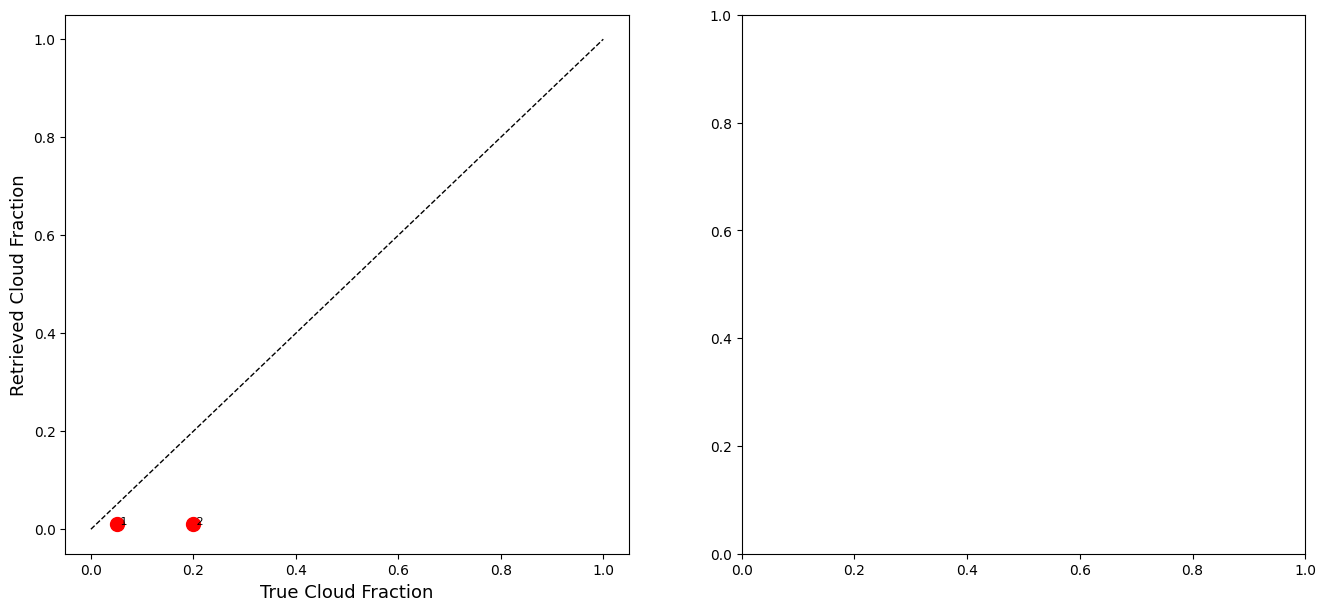

In [29]:
# ============================================================
# VALIDATION SCATTER PLOTS
# True vs Retrieved cloud properties
# ============================================================

true_cfs = np.array([r['true_cf'] for r in results_validation])
ret_cfs = np.array([r['cloud_fraction'] for r in results_validation])
cf_errs = np.array([r['cloud_fraction_error'] for r in results_validation])

true_cps = np.array([r['true_cp'] for r in results_validation])
ret_cps = np.array([r['cloud_pressure'] for r in results_validation])
cp_errs = np.array([r['cloud_pressure_error'] for r in results_validation])

labels = [r['case_label'] for r in results_validation]
converged = [r['converged'] for r in results_validation]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---- Cloud Fraction ----
ax1 = axes[0]
for i in range(len(true_cfs)):
    color = 'green' if converged[i] else 'red'
    ax1.errorbar(true_cfs[i], ret_cfs[i], yerr=cf_errs[i],
                 fmt='o', color=color, markersize=10, capsize=4, linewidth=2)
    ax1.annotate(f" {i+1}", (true_cfs[i], ret_cfs[i]), fontsize=8)

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='1:1 line')
ax1.set_xlabel('True Cloud Fraction', fontsize=13)
ax1.set_ylabel('Retrieved Cloud Fraction', fontsize=13)
ax1.set_title(f'Cloud Fraction Validation\n'
              f'RMSE={cf_rmse:.3f}, Bias={cf_bias:+.3f}', fontsize=14)
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Add case legend
legend_text = "\n".join([f"{i+1}: {l}" for i, l in enumerate(labels)])
ax1.text(0.02, 0.98, legend_text, transform=ax1.transAxes,
         fontsize=7, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ---- Cloud Pressure ----
ax2 = axes[1]
for i in range(len(true_cps)):
    color = 'green' if converged[i] else 'red'
    ax2.errorbar(true_cps[i], ret_cps[i], yerr=cp_errs[i],
                 fmt='s', color=color, markersize=10, capsize=4, linewidth=2)
    ax2.annotate(f" {i+1}", (true_cps[i], ret_cps[i]), fontsize=8)

ax2.plot([100, 1050], [100, 1050], 'k--', linewidth=1, label='1:1 line')
ax2.set_xlabel('True Cloud Pressure (hPa)', fontsize=13)
ax2.set_ylabel('Retrieved Cloud Pressure (hPa)', fontsize=13)
ax2.set_title(f'Cloud Pressure Validation\n'
              f'RMSE={cp_rmse:.1f} hPa, Bias={cp_bias:+.1f} hPa', fontsize=14)
ax2.set_xlim(100, 1050)
ax2.set_ylim(100, 1050)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Color legend
from matplotlib.lines import Line2D
custom_legend = [Line2D([0], [0], marker='o', color='green', label='Converged',
                        markerfacecolor='green', markersize=8, linestyle='None'),
                 Line2D([0], [0], marker='o', color='red', label='Not converged',
                        markerfacecolor='red', markersize=8, linestyle='None')]
ax2.legend(handles=custom_legend + [Line2D([0],[0], color='k', linestyle='--', label='1:1')],
           fontsize=10)

plt.suptitle('TEMPO Cloud Retrieval Validation (Synthetic Data)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('retrieval_validation_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Validation scatter plots saved")

IndexError: list index out of range

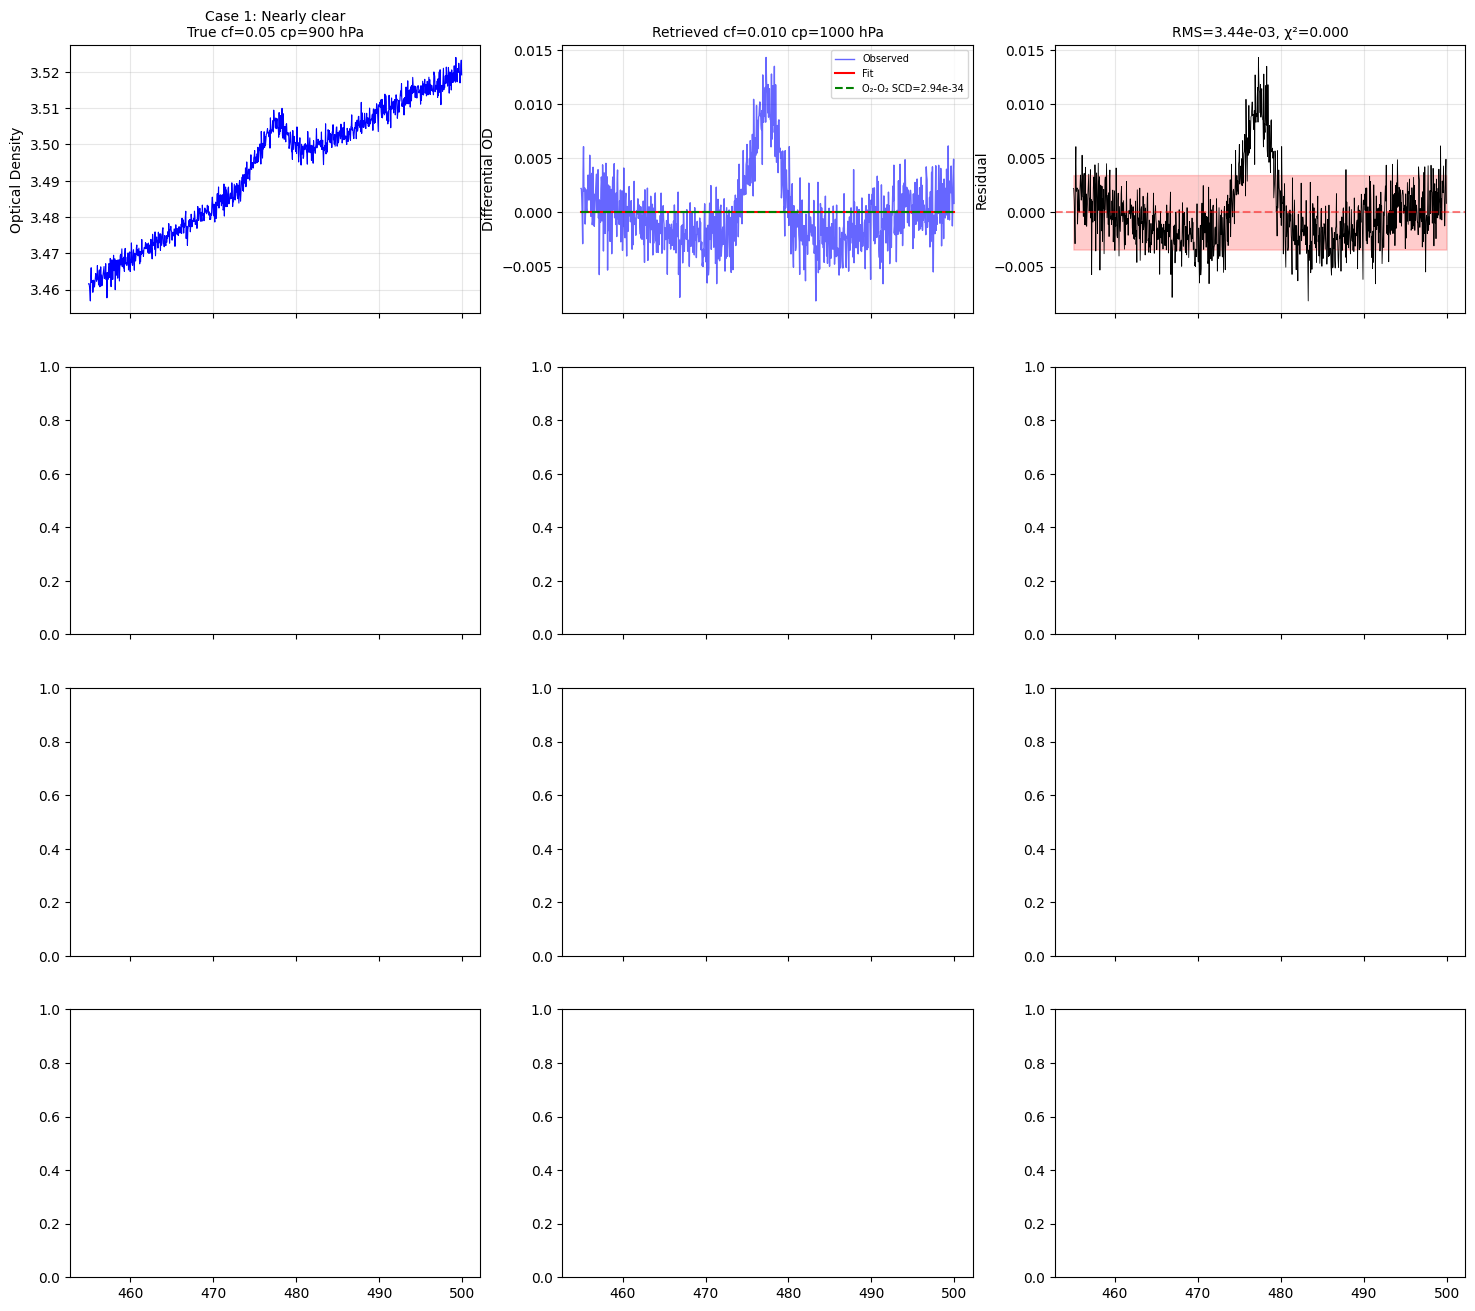

In [30]:
# ============================================================
# DETAILED DOAS FIT VISUALIZATION
# Show spectral fits for key validation cases
# ============================================================

cases_to_plot = [0, 2, 4, 7]  # Nearly clear, Moderate, Overcast, Elevated

fig, axes_grid = plt.subplots(len(cases_to_plot), 3,
                               figsize=(18, 4*len(cases_to_plot)),
                               sharex='col')

for row, case_idx in enumerate(cases_to_plot):
    case = validation_cases[case_idx]
    result = results_validation[case_idx]
    doas = result['doas_result']

    if doas is None:
        continue

    ax_od = axes_grid[row, 0]
    ax_fit = axes_grid[row, 1]
    ax_res = axes_grid[row, 2]

    # Panel 1: Full optical density
    ax_od.plot(wl_test, doas['optical_density'], 'b-', linewidth=0.8)
    ax_od.set_ylabel('Optical Density', fontsize=10)
    ax_od.set_title(f"Case {case_idx+1}: {case['label']}\n"
                    f"True cf={case['cf']:.2f} cp={case['cp']} hPa", fontsize=10)
    ax_od.grid(True, alpha=0.3)

    # Panel 2: Differential OD + fit
    ax_fit.plot(wl_test, doas['od_differential'], 'b-', linewidth=1,
                alpha=0.6, label='Observed')
    ax_fit.plot(wl_test, doas['od_fit'], 'r-', linewidth=1.5, label='Fit')

    # O2-O2 contribution
    o2o2_contrib = retrieval_engine.doas.xs_o2o2_diff * doas['scd_o2o2']
    ax_fit.plot(wl_test, o2o2_contrib, 'g--', linewidth=1.5,
                label=f'O₂-O₂ SCD={doas["scd_o2o2"]:.2e}')

    ax_fit.set_ylabel('Differential OD', fontsize=10)
    ax_fit.set_title(f"Retrieved cf={result['cloud_fraction']:.3f} "
                     f"cp={result['cloud_pressure']:.0f} hPa", fontsize=10)
    ax_fit.legend(fontsize=7, loc='upper right')
    ax_fit.grid(True, alpha=0.3)

    # Panel 3: Residuals
    ax_res.plot(wl_test, doas['residuals'], 'k-', linewidth=0.6)
    ax_res.axhline(0, color='r', linestyle='--', alpha=0.5)
    rms = doas['rms_residual']
    ax_res.fill_between(wl_test, -rms, rms, alpha=0.2, color='red')
    ax_res.set_ylabel('Residual', fontsize=10)
    ax_res.set_title(f"RMS={rms:.2e}, χ²={doas['chi_squared']:.3f}", fontsize=10)
    ax_res.grid(True, alpha=0.3)

# X labels on bottom row only
for ax in axes_grid[-1]:
    ax.set_xlabel('Wavelength (nm)', fontsize=10)

plt.suptitle('DOAS Spectral Fit Details', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('doas_fit_details.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ DOAS fit details plotted")

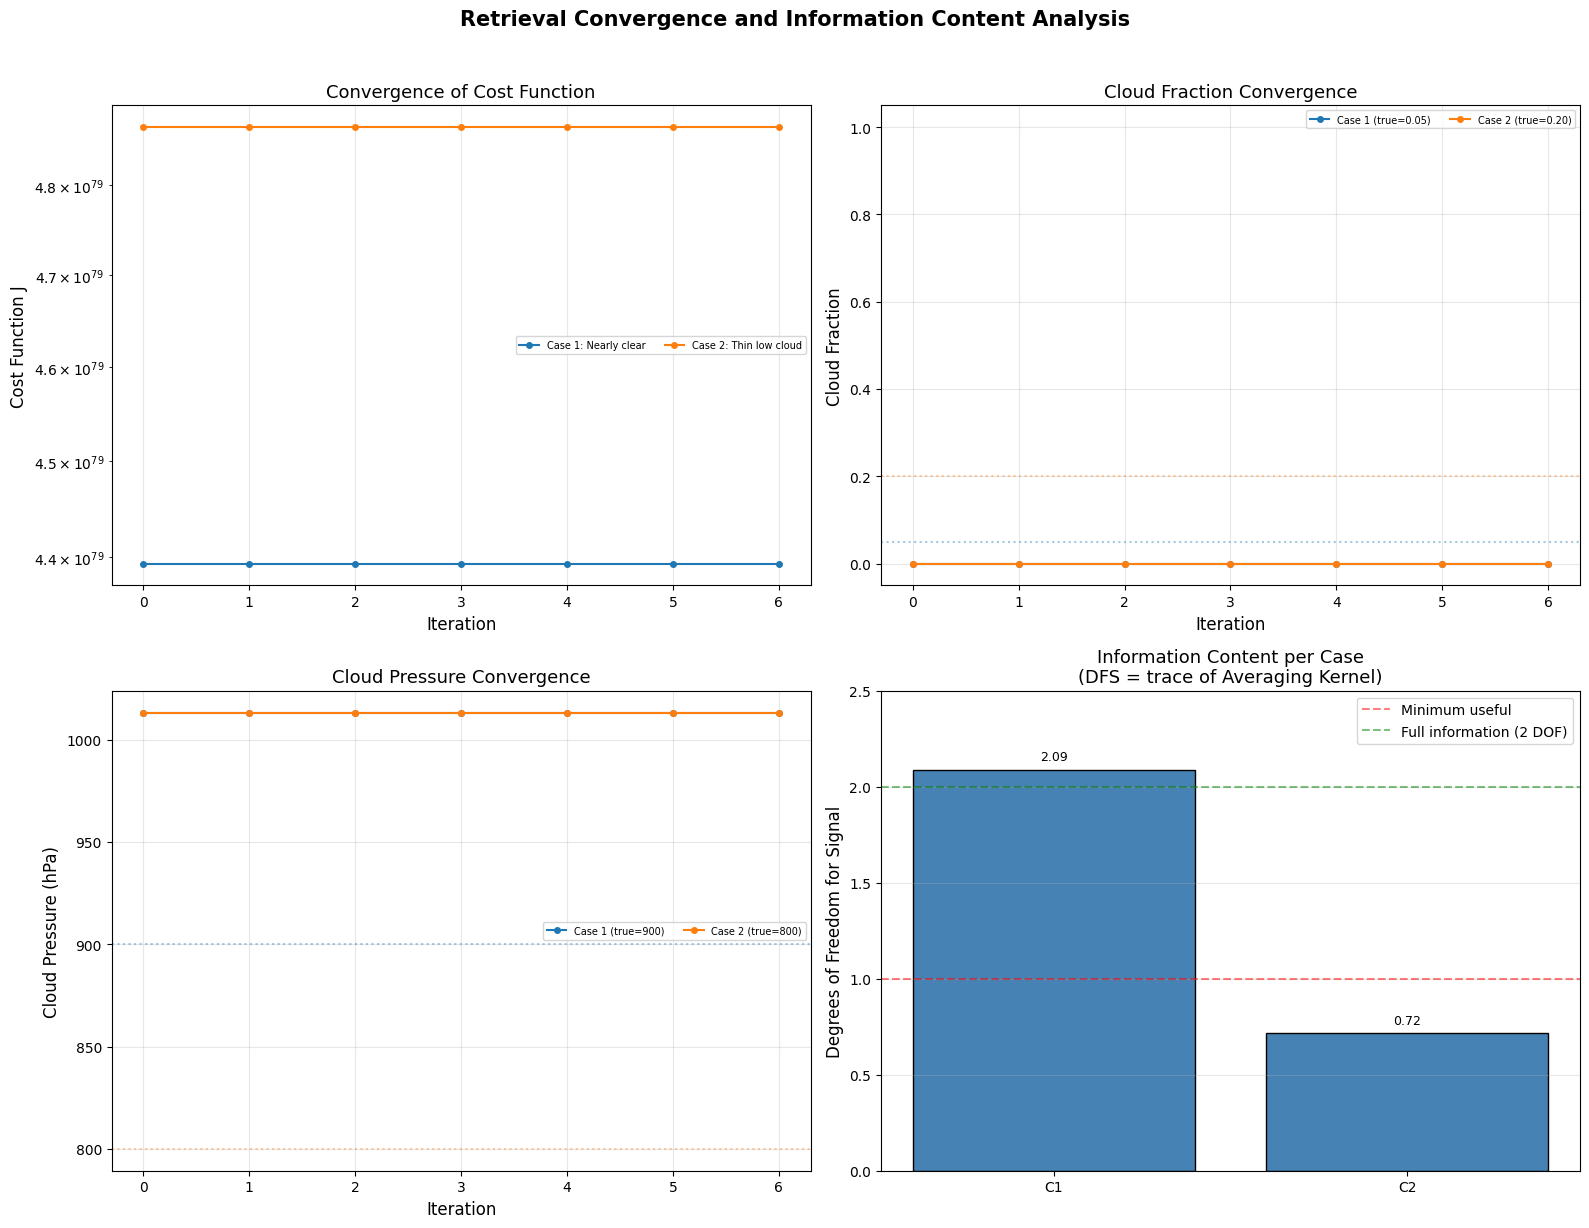

✅ Convergence analysis complete


In [31]:
# ============================================================
# CONVERGENCE BEHAVIOR AND INFORMATION CONTENT
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- Panel 1: Cost function convergence ----
ax1 = axes[0, 0]
for i, r in enumerate(results_validation):
    if len(r['iteration_log']) > 0:
        iters = [il['iteration'] for il in r['iteration_log']]
        costs = [il['cost'] for il in r['iteration_log']]
        ax1.semilogy(iters, costs, 'o-', linewidth=1.5, markersize=4,
                     label=f"Case {i+1}: {r['case_label'][:15]}")

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Cost Function J', fontsize=12)
ax1.set_title('Convergence of Cost Function', fontsize=13)
ax1.legend(fontsize=7, ncol=2)
ax1.grid(True, alpha=0.3)

# ---- Panel 2: cf convergence ----
ax2 = axes[0, 1]
for i, r in enumerate(results_validation):
    if len(r['iteration_log']) > 0:
        iters = [il['iteration'] for il in r['iteration_log']]
        cfs = [il['cf'] for il in r['iteration_log']]
        ax2.plot(iters, cfs, 'o-', linewidth=1.5, markersize=4,
                 label=f"Case {i+1} (true={r['true_cf']:.2f})")
        ax2.axhline(r['true_cf'], color=ax2.get_lines()[-1].get_color(),
                     linestyle=':', alpha=0.4)

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Cloud Fraction', fontsize=12)
ax2.set_title('Cloud Fraction Convergence', fontsize=13)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

# ---- Panel 3: cp convergence ----
ax3 = axes[1, 0]
for i, r in enumerate(results_validation):
    if len(r['iteration_log']) > 0:
        iters = [il['iteration'] for il in r['iteration_log']]
        cps = [il['cp'] for il in r['iteration_log']]
        ax3.plot(iters, cps, 'o-', linewidth=1.5, markersize=4,
                 label=f"Case {i+1} (true={r['true_cp']})")
        ax3.axhline(r['true_cp'], color=ax3.get_lines()[-1].get_color(),
                     linestyle=':', alpha=0.4)

ax3.set_xlabel('Iteration', fontsize=12)
ax3.set_ylabel('Cloud Pressure (hPa)', fontsize=12)
ax3.set_title('Cloud Pressure Convergence', fontsize=13)
ax3.legend(fontsize=7, ncol=2)
ax3.grid(True, alpha=0.3)

# ---- Panel 4: Averaging Kernels ----
ax4 = axes[1, 1]
dfs_values = []
case_labels_short = []

for i, r in enumerate(results_validation):
    ak = r['averaging_kernel']
    if not np.any(np.isnan(ak)):
        dfs_values.append(r['degrees_of_freedom'])
        case_labels_short.append(f"C{i+1}")

bars = ax4.bar(range(len(dfs_values)), dfs_values, color='steelblue', edgecolor='black')
ax4.set_xticks(range(len(case_labels_short)))
ax4.set_xticklabels(case_labels_short, fontsize=10)
ax4.set_ylabel('Degrees of Freedom for Signal', fontsize=12)
ax4.set_title('Information Content per Case\n(DFS = trace of Averaging Kernel)', fontsize=13)
ax4.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Minimum useful')
ax4.axhline(2.0, color='green', linestyle='--', alpha=0.5, label='Full information (2 DOF)')
ax4.set_ylim(0, 2.5)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

# Annotate bars
for bar, dfs in zip(bars, dfs_values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{dfs:.2f}', ha='center', fontsize=9)

plt.suptitle('Retrieval Convergence and Information Content Analysis',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('convergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Convergence analysis complete")

In [32]:
# ============================================================
# NOISE SENSITIVITY ANALYSIS
# How does retrieval accuracy degrade with increasing noise?
# ============================================================

print("⏳ Running noise sensitivity analysis...")

noise_levels = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
n_realizations = 20  # Monte Carlo realizations per noise level

# Test case: moderate cloud
test_cf = 0.50
test_cp = 600.0
test_sza = 35.0
test_vza = 25.0
test_alb = 0.04
test_ps = 1013.25

noise_results = {nl: {'cf': [], 'cp': [], 'converged': []} for nl in noise_levels}

for nl in noise_levels:
    for realization in range(n_realizations):
        I0, I_obs, _ = generate_synthetic_spectrum(
            wl_test, sza=test_sza, vza=test_vza,
            cloud_fraction=test_cf,
            cloud_pressure_hPa=test_cp,
            surface_pressure_hPa=test_ps,
            surface_albedo=test_alb,
            noise_level=nl
        )

        result = retrieval_engine.retrieve_pixel(
            radiance=I_obs, irradiance=I0,
            sza=test_sza, vza=test_vza,
            surface_albedo=test_alb,
            surface_pressure=test_ps,
            verbose=False
        )

        noise_results[nl]['cf'].append(result['cloud_fraction'])
        noise_results[nl]['cp'].append(result['cloud_pressure'])
        noise_results[nl]['converged'].append(result['converged'])

print("✅ Noise sensitivity analysis complete")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Statistics arrays
nl_arr = np.array(noise_levels) * 100  # convert to percent

cf_means = [np.nanmean(noise_results[nl]['cf']) for nl in noise_levels]
cf_stds = [np.nanstd(noise_results[nl]['cf']) for nl in noise_levels]
cf_rmses = [np.sqrt(np.nanmean((np.array(noise_results[nl]['cf']) - test_cf)**2))
            for nl in noise_levels]

cp_means = [np.nanmean(noise_results[nl]['cp']) for nl in noise_levels]
cp_stds = [np.nanstd(noise_results[nl]['cp']) for nl in noise_levels]
cp_rmses = [np.sqrt(np.nanmean((np.array(noise_results[nl]['cp']) - test_cp)**2))
            for nl in noise_levels]

conv_rates = [np.nanmean(noise_results[nl]['converged']) * 100 for nl in noise_levels]

# Panel 1: Cloud Fraction errors
ax1 = axes[0]
ax1.errorbar(nl_arr, cf_means, yerr=cf_stds, fmt='bo-', linewidth=2,
             capsize=5, markersize=8, label='Mean ± 1σ')
ax1.axhline(test_cf, color='red', linestyle='--', linewidth=2, label=f'True cf={test_cf}')
ax1.set_xlabel('Noise Level (%)', fontsize=12)
ax1.set_ylabel('Retrieved Cloud Fraction', fontsize=12)
ax1.set_title('Cloud Fraction vs Noise', fontsize=13)
ax1.set_xscale('log')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel 2: Cloud Pressure errors
ax2 = axes[1]
ax2.errorbar(nl_arr, cp_means, yerr=cp_stds, fmt='rs-', linewidth=2,
             capsize=5, markersize=8, label='Mean ± 1σ')
ax2.axhline(test_cp, color='blue', linestyle='--', linewidth=2, label=f'True cp={test_cp}')
ax2.set_xlabel('Noise Level (%)', fontsize=12)
ax2.set_ylabel('Retrieved Cloud Pressure (hPa)', fontsize=12)
ax2.set_title('Cloud Pressure vs Noise', fontsize=13)
ax2.set_xscale('log')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Panel 3: RMSE and convergence rate
ax3 = axes[2]
ax3_twin = ax3.twinx()
ax3.plot(nl_arr, cf_rmses, 'bo-', linewidth=2, markersize=8, label='cf RMSE')
ax3.plot(nl_arr, np.array(cp_rmses)/1000, 'rs-', linewidth=2, markersize=8,
         label='cp RMSE (×10³ hPa)')
ax3_twin.plot(nl_arr, conv_rates, 'g^--', linewidth=2, markersize=8,
              label='Convergence %')

ax3.set_xlabel('Noise Level (%)', fontsize=12)
ax3.set_ylabel('RMSE', fontsize=12)
ax3_twin.set_ylabel('Convergence Rate (%)', fontsize=12, color='green')
ax3.set_title('Error Budget Summary', fontsize=13)
ax3.set_xscale('log')
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3_twin.set_ylim(0, 110)

plt.suptitle(f'Noise Sensitivity Analysis (True: cf={test_cf}, cp={test_cp} hPa)\n'
             f'{n_realizations} Monte Carlo realizations per noise level',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('noise_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

⏳ Running noise sensitivity analysis...


LinAlgError: Singular matrix

In [33]:
# ============================================================
# DOWNLOAD REAL TEMPO L1B DATA FROM NASA EARTHDATA
# ============================================================

auth = earthaccess.login(strategy="interactive")

if auth:
    print("✅ Authenticated with NASA Earthdata")
else:
    print("❌ Authentication failed")

# ============================================================
# Search for TEMPO L1B radiance data
# Short name options (verify on Earthdata Search):
#   TEMPO_RAD_L1    or  TEMPO_RADS_L1B  or  TEMPO_L1B
#   Check: https://search.earthdata.nasa.gov
# ============================================================

# Search parameters
L1B_COLLECTION = "TEMPO_RAD_L1"    # ← Update based on actual collection name
DATE_RANGE = ("2025-08-15", "2025-08-15")
BBOX = (-90, 30, -75, 42)           # Southeast US / Gulf States region

print(f"\n🔍 Searching for TEMPO L1B data...")
print(f"   Collection: {L1B_COLLECTION}")
print(f"   Date range: {DATE_RANGE}")
print(f"   Bounding box: {BBOX}")

try:
    results_l1b = earthaccess.search_data(
        short_name=L1B_COLLECTION,
        temporal=DATE_RANGE,
        bounding_box=BBOX,
        count=5
    )
    print(f"\n✅ Found {len(results_l1b)} L1B granules")
    for i, r in enumerate(results_l1b[:5]):
        print(f"   [{i}] {r}")

except Exception as e:
    print(f"⚠️ Search failed: {e}")
    print("\nTrying alternative collection names...")

    alt_names = ["TEMPO_RADS_L1B", "TEMPO_L1B_RAD", "TEMPO_RAD_L1B_V03"]
    for alt_name in alt_names:
        try:
            results_l1b = earthaccess.search_data(
                short_name=alt_name,
                temporal=DATE_RANGE,
                bounding_box=BBOX,
                count=5
            )
            if len(results_l1b) > 0:
                print(f"✅ Found {len(results_l1b)} granules with: {alt_name}")
                L1B_COLLECTION = alt_name
                break
        except:
            print(f"   ❌ {alt_name}: not found")

# Download
output_dir_l1b = Path("./tempo_l1b_data")
output_dir_l1b.mkdir(exist_ok=True)

if len(results_l1b) > 0:
    N_DOWNLOAD = min(2, len(results_l1b))
    downloaded_l1b = earthaccess.download(
        results_l1b[:N_DOWNLOAD],
        local_path=str(output_dir_l1b)
    )
    print(f"\n✅ Downloaded {len(downloaded_l1b)} L1B files:")
    for f in downloaded_l1b:
        print(f"   📁 {f}")
else:
    print("⚠️ No L1B data found. Will use synthetic data for demonstration.")
    downloaded_l1b = []

✅ Authenticated with NASA Earthdata

🔍 Searching for TEMPO L1B data...
   Collection: TEMPO_RAD_L1
   Date range: ('2025-08-15', '2025-08-15')
   Bounding box: (-90, 30, -75, 42)

✅ Found 5 L1B granules
   [0] Collection: {'ShortName': 'TEMPO_RAD_L1', 'Version': 'V03'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 57.60516, 'Longitude': -88.0774}, {'Latitude': 41.73376, 'Longitude': -88.91524}, {'Latitude': 17.2128, 'Longitude': -89.47792}, {'Latitude': 17.21436, 'Longitude': -83.67799}, {'Latitude': 24.57958, 'Longitude': -83.16705}, {'Latitude': 30.40158, 'Longitude': -82.64582}, {'Latitude': 36.12411, 'Longitude': -81.98129}, {'Latitude': 41.24571, 'Longitude': -81.21112}, {'Latitude': 45.93562, 'Longitude': -80.31355}, {'Latitude': 50.26221, 'Longitude': -79.2628}, {'Latitude': 54.19905, 'Longitude': -78.05194}, {'Latitude': 57.81097, 'Longitude': -76.64585}, {'Latitude': 57.89912, 'Longitude': -76.65157}, {'Latitude

QUEUEING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/2 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/2 [00:00<?, ?it/s]


✅ Downloaded 2 L1B files:
   📁 tempo_l1b_data/TEMPO_RAD_L1_V03_20250815T000305Z_S016G01.nc
   📁 tempo_l1b_data/TEMPO_RAD_L1_V03_20250815T000945Z_S016G02.nc


In [34]:
# ============================================================
# EXPLORE TEMPO L1B FILE STRUCTURE
# Adapt variable names based on actual file contents
# ============================================================

def explore_hdf5(filepath):
    """Recursively explore HDF5/netCDF4 file structure"""

    found_vars = {
        'radiance': [], 'irradiance': [], 'wavelength': [],
        'latitude': [], 'longitude': [],
        'sza': [], 'vza': [], 'raa': [],
        'quality': [], 'other': []
    }

    def _classify_variable(name):
        """Classify variable into category based on name patterns"""
        name_lower = name.lower().split('/')[-1]
        if any(k in name_lower for k in ['radiance', 'rad', 'earthshine', 'intensity']):
            if 'irr' not in name_lower and 'solar' not in name_lower:
                return 'radiance'
        if any(k in name_lower for k in ['irradiance', 'irr', 'solar_flux', 'solar_ref',
                                          'sun_reference', 'solar_spectrum']):
            return 'irradiance'
        if any(k in name_lower for k in ['wavelength', 'wl', 'lambda', 'spectral_grid',
                                          'band_center']):
            return 'wavelength'
        if any(k in name_lower for k in ['latitude', 'lat']):
            return 'latitude'
        if any(k in name_lower for k in ['longitude', 'lon']):
            return 'longitude'
        if any(k in name_lower for k in ['solar_zenith', 'sza', 'sun_zenith']):
            return 'sza'
        if any(k in name_lower for k in ['viewing_zenith', 'vza', 'sensor_zenith',
                                          'satellite_zenith', 'view_zenith']):
            return 'vza'
        if any(k in name_lower for k in ['relative_azimuth', 'raa', 'azimuth']):
            return 'raa'
        if any(k in name_lower for k in ['quality', 'flag', 'qa', 'mask']):
            return 'quality'
        return 'other'

    def _print_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            category = _classify_variable(name)
            found_vars[category].append({
                'name': name,
                'shape': obj.shape,
                'dtype': str(obj.dtype)
            })

            # Print with category icon
            icons = {
                'radiance': '🌍', 'irradiance': '☀️', 'wavelength': '🌈',
                'latitude': '📍', 'longitude': '📍', 'sza': '📐',
                'vza': '📐', 'raa': '📐', 'quality': '🏷️', 'other': '📦'
            }
            icon = icons.get(category, '📦')
            print(f"  {icon} [{category:>11}] {name}: "
                  f"shape={obj.shape}, dtype={obj.dtype}")

            # Print key attributes
            attrs_to_show = ['units', 'long_name', 'valid_range',
                             'scale_factor', 'add_offset', '_FillValue']
            for attr_key in attrs_to_show:
                if attr_key in obj.attrs:
                    val = obj.attrs[attr_key]
                    if isinstance(val, bytes):
                        val = val.decode('utf-8', errors='ignore')
                    print(f"     └─ {attr_key}: {val}")

        elif isinstance(obj, h5py.Group):
            n_items = len(obj)
            print(f"  📁 {name}/ ({n_items} items)")

    print(f"\n{'='*70}")
    print(f"FILE STRUCTURE: {Path(filepath).name}")
    print(f"{'='*70}")

    with h5py.File(filepath, 'r') as f:
        # Print global attributes
        print("\n🏷️  GLOBAL ATTRIBUTES:")
        for key in list(f.attrs.keys())[:15]:
            val = f.attrs[key]
            if isinstance(val, bytes):
                val = val.decode('utf-8', errors='ignore')
            elif isinstance(val, np.ndarray) and val.size > 5:
                val = f"{val[:3]}... (shape={val.shape})"
            print(f"    {key}: {val}")

        print(f"\n📋 DATASET INVENTORY:")
        f.visititems(_print_structure)

    # Summary
    print(f"\n{'='*70}")
    print("VARIABLE CLASSIFICATION SUMMARY:")
    print(f"{'='*70}")
    for category, var_list in found_vars.items():
        if len(var_list) > 0:
            print(f"\n  {category.upper()} ({len(var_list)} found):")
            for v in var_list:
                print(f"    → {v['name']}  {v['shape']}")

    return found_vars

# ============================================================
# Run on downloaded file (or skip if using synthetic data)
# ============================================================
if len(downloaded_l1b) > 0:
    l1b_file = downloaded_l1b[0]
    found_variables = explore_hdf5(l1b_file)
else:
    print("⚠️ No L1B files downloaded. Will use synthetic data.")
    print("   To use real data, update the collection name in Cell 18")
    print("   and ensure your Earthdata credentials are valid.")
    found_variables = None


FILE STRUCTURE: TEMPO_RAD_L1_V03_20250815T000305Z_S016G01.nc

🏷️  GLOBAL ATTRIBUTES:
    _NCProperties: version=1|netcdflibversion=4.6.1|hdf5libversion=1.8.14
    time_reference: 1980-01-06T00:00:00Z
    format_version: [2]
    product_type: RAD
    sdpc_version: TEMPO_SDPC_v4.6.1
    scan_num: [16]
    granule_num: [1]
    processing_version: [3]
    scan_type: [0]
    time_coverage_start: 2025-08-15T00:03:05Z
    time_coverage_end: 2025-08-15T00:09:44Z
    time_coverage_start_since_epoch: [1.4392514e+09]
    time_coverage_end_since_epoch: [1.4392518e+09]
    production_date_time: 2025-08-15T00:34:34Z
    version_id: [3]

📋 DATASET INVENTORY:
  📁 band_290_490_nm/ (30 items)
  📦 [      other] band_290_490_nm/ABI_Band_1_East: shape=(132, 2048), dtype=float32
     └─ units: photons/s/cm^2/nm/sr
     └─ long_name: spectrally equivalent ABI band 1 image
     └─ _FillValue: [9.96921e+36]
  📦 [      other] band_290_490_nm/ABI_Band_1_West: shape=(132, 2048), dtype=float32
     └─ units: phot

In [35]:
# ============================================================
# TEMPO L1B DATA PARSER
# Handles multiple possible file structures
# ============================================================

class TEMPOL1BParser:
    """
    Parser for TEMPO L1B radiance files.
    Automatically detects variable names and group structure.
    Extracts the O2-O2 spectral window (455-500 nm) for cloud retrieval.
    """

    # Common variable name patterns for TEMPO L1B
    VAR_PATTERNS = {
        'radiance': [
            'radiance', 'band2/radiance', 'spectral_radiance',
            'radiance_data', 'earthshine_radiance',
            'product/radiance', 'science_data/radiance',
            'Band2/Radiance', 'PRODUCT/radiance'
        ],
        'irradiance': [
            'irradiance', 'band2/irradiance', 'solar_irradiance',
            'solar_reference', 'sun_reference',
            'product/irradiance', 'science_data/irradiance',
            'Band2/Irradiance', 'PRODUCT/irradiance',
            'solar_flux', 'band2/solar_flux'
        ],
        'wavelength': [
            'wavelength', 'band2/wavelength', 'spectral_grid',
            'wavelength_grid', 'band_center_wavelengths',
            'product/wavelength', 'Band2/Wavelength',
            'nominal_wavelength'
        ],
        'latitude': [
            'geolocation/latitude', 'latitude', 'lat',
            'geolocation_data/latitude', 'navigation/latitude',
            'Geolocation/Latitude'
        ],
        'longitude': [
            'geolocation/longitude', 'longitude', 'lon',
            'geolocation_data/longitude', 'navigation/longitude',
            'Geolocation/Longitude'
        ],
        'sza': [
            'geolocation/solar_zenith_angle', 'solar_zenith_angle',
            'sza', 'geolocation_data/solar_zenith_angle',
            'Geolocation/SolarZenithAngle',
            'geolocation/sun_zenith'
        ],
        'vza': [
            'geolocation/viewing_zenith_angle', 'viewing_zenith_angle',
            'vza', 'sensor_zenith_angle',
            'geolocation_data/viewing_zenith_angle',
            'Geolocation/ViewingZenithAngle',
            'geolocation/satellite_zenith'
        ],
        'raa': [
            'geolocation/relative_azimuth_angle', 'relative_azimuth_angle',
            'raa', 'geolocation_data/relative_azimuth',
            'Geolocation/RelativeAzimuthAngle'
        ],
        'quality_flag': [
            'quality_flag', 'qa_flag', 'product/qa_value',
            'science_data/quality_flag', 'data_quality_flag',
            'support_data/quality_flags'
        ]
    }

    # O2-O2 spectral window
    WL_MIN = 455.0  # nm
    WL_MAX = 500.0  # nm

    def __init__(self, filepath):
        self.filepath = filepath
        self.filename = Path(filepath).name
        self.variables = {}
        self.global_attrs = {}
        self._parsed = False

    def _find_variable(self, f, category):
        """Find a variable by trying multiple name patterns"""
        patterns = self.VAR_PATTERNS.get(category, [])

        # Try exact patterns
        for pattern in patterns:
            if pattern in f:
                return pattern

        # Case-insensitive search through all datasets
        all_datasets = []
        def _collect(name, obj):
            if isinstance(obj, h5py.Dataset):
                all_datasets.append(name)
        f.visititems(_collect)

        for pattern in patterns:
            pattern_lower = pattern.lower().split('/')[-1]
            for ds_name in all_datasets:
                if pattern_lower in ds_name.lower():
                    return ds_name

        return None

    def parse(self, verbose=True):
        """
        Parse the L1B file and extract all needed variables.
        Automatically subsets to the O2-O2 spectral window.
        """
        if verbose:
            print(f"\n📂 Parsing: {self.filename}")

        with h5py.File(self.filepath, 'r') as f:
            # Global attributes
            for key in f.attrs:
                val = f.attrs[key]
                if isinstance(val, bytes):
                    val = val.decode('utf-8', errors='ignore')
                self.global_attrs[key] = val

            # Find and load each variable
            var_map = {}
            for category in self.VAR_PATTERNS:
                var_name = self._find_variable(f, category)
                if var_name:
                    var_map[category] = var_name
                    if verbose:
                        ds = f[var_name]
                        print(f"  ✅ {category:>15}: {var_name} {ds.shape}")
                else:
                    if verbose:
                        print(f"  ❌ {category:>15}: NOT FOUND")

            # ---- Load wavelength grid ----
            if 'wavelength' in var_map:
                wl_data = f[var_map['wavelength']][:]

                # Handle different shapes: (n_wl,) or (n_rows, n_wl) or (n_rows, n_cols, n_wl)
                if wl_data.ndim == 1:
                    self.wavelength_full = wl_data
                elif wl_data.ndim == 2:
                    self.wavelength_full = np.nanmean(wl_data, axis=0)
                elif wl_data.ndim == 3:
                    self.wavelength_full = np.nanmean(wl_data, axis=(0, 1))
                else:
                    self.wavelength_full = wl_data.flatten()

                # Apply scale factor if present
                ds = f[var_map['wavelength']]
                if 'scale_factor' in ds.attrs:
                    self.wavelength_full = self.wavelength_full * ds.attrs['scale_factor']
                if 'add_offset' in ds.attrs:
                    self.wavelength_full = self.wavelength_full + ds.attrs['add_offset']

            else:
                raise ValueError("Cannot find wavelength variable in L1B file!")

            # ---- Find O2-O2 spectral window indices ----
            wl_mask = (self.wavelength_full >= self.WL_MIN) & \
                      (self.wavelength_full <= self.WL_MAX)
            self.wl_indices = np.where(wl_mask)[0]

            if len(self.wl_indices) == 0:
                raise ValueError(f"No wavelengths found in [{self.WL_MIN}, {self.WL_MAX}] nm! "
                                 f"Wavelength range: [{self.wavelength_full.min():.1f}, "
                                 f"{self.wavelength_full.max():.1f}] nm")

            self.wavelength = self.wavelength_full[self.wl_indices]

            if verbose:
                print(f"\n  🌈 Full wavelength range: "
                      f"[{self.wavelength_full.min():.1f}, {self.wavelength_full.max():.1f}] nm "
                      f"({len(self.wavelength_full)} channels)")
                print(f"  🔍 O₂-O₂ window: [{self.wavelength.min():.1f}, "
                      f"{self.wavelength.max():.1f}] nm "
                      f"({len(self.wavelength)} channels)")

            # ---- Load radiance (subset to O2-O2 window) ----
            if 'radiance' in var_map:
                rad_ds = f[var_map['radiance']]

                # Determine spectral axis (last dim usually)
                rad_shape = rad_ds.shape
                if verbose:
                    print(f"\n  📊 Radiance shape: {rad_shape}")

                # Load only O2-O2 window (memory efficient)
                if rad_ds.ndim == 3:
                    # (n_along, n_across, n_wl) or (n_scans, n_pixels, n_wl)
                    self.radiance = rad_ds[:, :, self.wl_indices]
                    self.n_rows = rad_shape[0]
                    self.n_cols = rad_shape[1]
                elif rad_ds.ndim == 2:
                    # (n_pixels, n_wl)
                    self.radiance = rad_ds[:, self.wl_indices]
                    self.n_rows = rad_shape[0]
                    self.n_cols = 1
                else:
                    raise ValueError(f"Unexpected radiance dimensions: {rad_ds.ndim}")

                # Apply scale/offset
                scale = rad_ds.attrs.get('scale_factor', 1.0)
                offset = rad_ds.attrs.get('add_offset', 0.0)
                fill_val = rad_ds.attrs.get('_FillValue', -999)

                self.radiance = self.radiance.astype(np.float64) * scale + offset
                self.radiance[self.radiance == fill_val * scale + offset] = np.nan

            else:
                raise ValueError("Cannot find radiance variable!")

            # ---- Load irradiance ----
            if 'irradiance' in var_map:
                irr_ds = f[var_map['irradiance']]

                if irr_ds.ndim == 1:
                    self.irradiance = irr_ds[self.wl_indices].astype(np.float64)
                elif irr_ds.ndim == 2:
                    self.irradiance = np.nanmean(
                        irr_ds[:, self.wl_indices].astype(np.float64), axis=0)
                elif irr_ds.ndim == 3:
                    self.irradiance = np.nanmean(
                        irr_ds[:, :, self.wl_indices].astype(np.float64), axis=(0,1))

                irr_scale = irr_ds.attrs.get('scale_factor', 1.0)
                irr_offset = irr_ds.attrs.get('add_offset', 0.0)
                self.irradiance = self.irradiance * irr_scale + irr_offset
            else:
                print("  ⚠️ No irradiance found — will estimate from radiance statistics")
                self.irradiance = None

            # ---- Load geolocation ----
            for geo_var in ['latitude', 'longitude', 'sza', 'vza', 'raa']:
                if geo_var in var_map:
                    data = f[var_map[geo_var]][:].astype(np.float64)
                    ds = f[var_map[geo_var]]

                    scale = ds.attrs.get('scale_factor', 1.0)
                    offset = ds.attrs.get('add_offset', 0.0)
                    fill_val = ds.attrs.get('_FillValue', -999)

                    data = data * scale + offset
                    data[data == fill_val * scale + offset] = np.nan

                    setattr(self, geo_var, data)
                else:
                    setattr(self, geo_var, None)

            # ---- Load quality flags ----
            if 'quality_flag' in var_map:
                self.quality_flag = f[var_map['quality_flag']][:].astype(np.int32)
            else:
                self.quality_flag = None

        self._parsed = True

        if verbose:
            print(f"\n  ✅ Parse complete!")
            print(f"     Spatial dimensions: {self.n_rows} × {self.n_cols}")
            print(f"     Spectral channels (O₂-O₂): {len(self.wavelength)}")
            print(f"     Radiance range: [{np.nanmin(self.radiance):.4e}, "
                  f"{np.nanmax(self.radiance):.4e}]")
            if self.latitude is not None:
                print(f"     Lat range: [{np.nanmin(self.latitude):.2f}, "
                      f"{np.nanmax(self.latitude):.2f}]")
                print(f"     Lon range: [{np.nanmin(self.longitude):.2f}, "
                      f"{np.nanmax(self.longitude):.2f}]")

        return self

    def get_pixel(self, row, col):
        """Extract all data for a single pixel"""
        pixel = {
            'wavelength': self.wavelength,
            'irradiance': self.irradiance,
        }

        if self.radiance.ndim == 3:
            pixel['radiance'] = self.radiance[row, col, :]
        else:
            pixel['radiance'] = self.radiance[row, :]

        for geo_var in ['latitude', 'longitude', 'sza', 'vza', 'raa']:
            arr = getattr(self, geo_var, None)
            if arr is not None:
                if arr.ndim == 2:
                    pixel[geo_var] = arr[row, col]
                elif arr.ndim == 1:
                    pixel[geo_var] = arr[row]
                else:
                    pixel[geo_var] = np.nan
            else:
                pixel[geo_var] = np.nan

        if self.quality_flag is not None:
            if self.quality_flag.ndim == 2:
                pixel['quality_flag'] = self.quality_flag[row, col]
            else:
                pixel['quality_flag'] = self.quality_flag[row]
        else:
            pixel['quality_flag'] = 0

        return pixel

# ============================================================
# Parse L1B file or create synthetic equivalent
# ============================================================

if len(downloaded_l1b) > 0:
    try:
        parser = TEMPOL1BParser(downloaded_l1b[0])
        parser.parse(verbose=True)
        USE_REAL_DATA = True
    except Exception as e:
        print(f"⚠️ Error parsing L1B file: {e}")
        print("   Falling back to synthetic data")
        USE_REAL_DATA = False
else:
    USE_REAL_DATA = False

if not USE_REAL_DATA:
    print("\n📝 Creating synthetic L1B-like dataset for demonstration...")
    print("   (Replace with real TEMPO L1B data for production use)")


📂 Parsing: TEMPO_RAD_L1_V03_20250815T000305Z_S016G01.nc
  ✅        radiance: band_290_490_nm/radiance (132, 2048, 1028)
  ❌      irradiance: NOT FOUND
  ✅      wavelength: band_290_490_nm/nominal_wavelength (2048, 1028)
  ✅        latitude: band_290_490_nm/latitude (132, 2048)
  ✅       longitude: band_290_490_nm/longitude (132, 2048)
  ✅             sza: band_290_490_nm/solar_zenith_angle (132, 2048)
  ✅             vza: band_290_490_nm/viewing_zenith_angle (132, 2048)
  ❌             raa: NOT FOUND
  ✅    quality_flag: band_290_490_nm/ground_pixel_quality_flag (132, 2048)

  🌈 Full wavelength range: [292.2, 495.4] nm (1028 channels)
  🔍 O₂-O₂ window: [455.0, 495.4] nm (205 channels)

  📊 Radiance shape: (132, 2048, 1028)
  ⚠️ No irradiance found — will estimate from radiance statistics

  ✅ Parse complete!
     Spatial dimensions: 132 × 2048
     Spectral channels (O₂-O₂): 205
     Radiance range: [-1.2586e+14, 4.3739e+14]
     Lat range: [17.21, 57.88]
     Lon range: [-89.46, -76.

In [36]:
# ============================================================
# GENERATE SYNTHETIC L1B SCENE
# Realistic spatial scene with varied cloud cover
# Used when real L1B data is unavailable
# ============================================================

if not USE_REAL_DATA:

    # Scene dimensions
    N_ROWS = 200    # along-track
    N_COLS = 300    # cross-track

    # Wavelength grid (TEMPO-like in O2-O2 window)
    wl_scene = np.arange(455, 500, 0.1)  # 0.1 nm sampling
    N_WL = len(wl_scene)

    # ---- Geolocation (Southeast US) ----
    lat_1d = np.linspace(28, 42, N_ROWS)
    lon_1d = np.linspace(-92, -75, N_COLS)
    lon_scene, lat_scene = np.meshgrid(lon_1d, lat_1d)

    # ---- Viewing geometry (geostationary-like) ----
    # TEMPO is geostationary: VZA varies with distance from sub-satellite point
    sub_sat_lon = -91.0  # TEMPO sub-satellite longitude
    sub_sat_lat = 0.0

    # Simple geometry model
    sza_scene = 30.0 + 20.0 * (lat_scene - 35.0) / 14.0  # varies with latitude
    sza_scene = np.clip(sza_scene + np.random.normal(0, 2, sza_scene.shape), 15, 75)

    vza_scene = np.sqrt((lon_scene - sub_sat_lon)**2 +
                         (lat_scene - sub_sat_lat)**2) * 0.8
    vza_scene = np.clip(vza_scene, 5, 65)

    # ---- Surface properties ----
    # Simple surface albedo map (land ~0.04, water ~0.02)
    surface_albedo_scene = np.full((N_ROWS, N_COLS), 0.04)
    # Water bodies: Gulf of Mexico (south), Atlantic (east)
    water_mask = (lat_scene < 30) | ((lon_scene > -82) & (lat_scene < 32))
    surface_albedo_scene[water_mask] = 0.02

    surface_pressure_scene = 1013.25 - 0.12 * np.maximum(
        0, (lat_scene - 35) * 50)  # terrain approximation
    surface_pressure_scene = np.clip(surface_pressure_scene, 850, 1013.25)

    # ---- Cloud field (realistic spatial structure) ----
    np.random.seed(42)

    # Generate spatially correlated cloud field using Gaussian random field
    from scipy.ndimage import gaussian_filter

    # Cloud fraction field
    cf_random = np.random.random((N_ROWS, N_COLS))
    cf_smooth = gaussian_filter(cf_random, sigma=15)  # spatial correlation
    cf_smooth = (cf_smooth - cf_smooth.min()) / (cf_smooth.max() - cf_smooth.min())

    # Add a large cloud system (frontal band)
    front_y = N_ROWS // 2 + (np.arange(N_COLS) - N_COLS//2) * 0.3
    for col in range(N_COLS):
        row_center = int(np.clip(front_y[col], 10, N_ROWS-10))
        for row in range(N_ROWS):
            dist = abs(row - row_center)
            cf_smooth[row, col] += 0.6 * np.exp(-0.5 * (dist / 20)**2)

    cf_scene = np.clip(cf_smooth, 0, 1)

    # Cloud pressure field (correlated with cf - thicker clouds tend to be higher)
    cp_base = 700 - 300 * cf_scene  # higher cloud fraction → lower pressure (higher altitude)
    cp_noise = gaussian_filter(np.random.normal(0, 100, (N_ROWS, N_COLS)), sigma=10)
    cp_scene = np.clip(cp_base + cp_noise, 150, 950)

    # Clear sky pixels: set cp to surface pressure (arbitrary, won't matter for cf~0)
    clear_mask = cf_scene < 0.05
    cp_scene[clear_mask] = surface_pressure_scene[clear_mask]

    print(f"✅ Synthetic scene generated:")
    print(f"   Dimensions: {N_ROWS} × {N_COLS} pixels, {N_WL} wavelengths")
    print(f"   Cloud fraction range: [{cf_scene.min():.3f}, {cf_scene.max():.3f}]")
    print(f"   Cloud pressure range: [{cp_scene.min():.0f}, {cp_scene.max():.0f}] hPa")
    print(f"   Lat range: [{lat_scene.min():.1f}, {lat_scene.max():.1f}]°")
    print(f"   Lon range: [{lon_scene.min():.1f}, {lon_scene.max():.1f}]°")

    # ---- Generate spectra for each pixel ----
    print(f"\n⏳ Generating {N_ROWS * N_COLS:,} synthetic spectra...")

    radiance_scene = np.zeros((N_ROWS, N_COLS, N_WL))
    irradiance_scene = None  # will be generated per pixel

    t0 = time.time()
    report_interval = N_ROWS // 10

    for row in range(N_ROWS):
        if row % report_interval == 0:
            pct = row / N_ROWS * 100
            print(f"   {pct:5.1f}% complete (row {row}/{N_ROWS})")

        for col in range(N_COLS):
            I0, I_obs, _ = generate_synthetic_spectrum(
                wl_scene,
                sza=sza_scene[row, col],
                vza=vza_scene[row, col],
                cloud_fraction=cf_scene[row, col],
                cloud_pressure_hPa=cp_scene[row, col],
                surface_pressure_hPa=surface_pressure_scene[row, col],
                surface_albedo=surface_albedo_scene[row, col],
                noise_level=0.002
            )
            radiance_scene[row, col, :] = I_obs

            # Store irradiance from first pixel (same for all in synthetic case)
            if irradiance_scene is None:
                irradiance_scene = I0

    elapsed = time.time() - t0
    print(f"   100.0% complete")
    print(f"✅ Spectra generated in {elapsed:.1f} seconds")

    # ---- Visualize the synthetic scene ----
    fig, axes = plt.subplots(2, 3, figsize=(20, 12),
                              subplot_kw={'projection': ccrs.PlateCarree()})

    plot_data = [
        (cf_scene, 'True Cloud Fraction', 'Blues', 0, 1),
        (cp_scene, 'True Cloud Pressure (hPa)', 'RdYlBu_r', 150, 1000),
        (sza_scene, 'Solar Zenith Angle (°)', 'YlOrRd', 15, 75),
        (vza_scene, 'Viewing Zenith Angle (°)', 'Purples', 5, 65),
        (surface_albedo_scene, 'Surface Albedo', 'Greens', 0.01, 0.08),
        (surface_pressure_scene, 'Surface Pressure (hPa)', 'terrain', 850, 1020),
    ]

    for ax, (data, title, cmap, vmin, vmax) in zip(axes.flat, plot_data):
        ax.set_extent([lon_scene.min(), lon_scene.max(),
                       lat_scene.min(), lat_scene.max()])
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        im = ax.pcolormesh(lon_scene, lat_scene, data,
                           cmap=cmap, vmin=vmin, vmax=vmax,
                           transform=ccrs.PlateCarree())
        plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
        ax.set_title(title, fontsize=11)
        ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5, fontsize=7)

    plt.suptitle('Synthetic TEMPO Scene — Input Parameters',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('synthetic_scene_inputs.png', dpi=150, bbox_inches='tight')
    plt.show()

In [37]:
# ============================================================
# RUN CLOUD RETRIEVAL ON FULL SCENE
# Process every pixel through the retrieval algorithm
# ============================================================

print("=" * 70)
print("CLOUD RETRIEVAL — FULL SCENE PROCESSING")
print("=" * 70)

# ---- Determine scene dimensions ----
if USE_REAL_DATA:
    n_rows = parser.n_rows
    n_cols = parser.n_cols
    wl_retrieval = parser.wavelength
else:
    n_rows = N_ROWS
    n_cols = N_COLS
    wl_retrieval = wl_scene

# ---- Initialize retrieval engine for this wavelength grid ----
retrieval = CloudRetrieval(wl_retrieval, polynomial_degree=3)

# ---- Output arrays ----
ecf_retrieved = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
ecp_retrieved = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
ecf_error = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
ecp_error = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
scd_observed_map = np.full((n_rows, n_cols), np.nan, dtype=np.float64)
doas_rms_map = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
dfs_map = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
qa_flag_map = np.full((n_rows, n_cols), 255, dtype=np.uint8)
n_iter_map = np.full((n_rows, n_cols), 0, dtype=np.int8)
cost_map = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
continuum_ratio_map = np.full((n_rows, n_cols), np.nan, dtype=np.float32)

# ---- Processing parameters ----
# Subsampling for speed (set to 1 for full resolution)
ROW_STEP = 1
COL_STEP = 1

# SZA limit — skip pixels with very high solar zenith angles
SZA_MAX = 75.0

# Minimum valid radiance — skip dark/invalid pixels
RAD_MIN = 1e-5

# Progress tracking
total_pixels = ((n_rows - 1) // ROW_STEP + 1) * ((n_cols - 1) // COL_STEP + 1)
processed = 0
successful = 0
failed = 0
skipped = 0
t_start = time.time()
report_every = max(total_pixels // 20, 1)

print(f"\n📐 Scene dimensions: {n_rows} × {n_cols}")
print(f"   Step size: row={ROW_STEP}, col={COL_STEP}")
print(f"   Total pixels to process: {total_pixels:,}")
print(f"   SZA limit: {SZA_MAX}°")
print(f"   Min radiance: {RAD_MIN:.1e}")
print(f"\n⏳ Starting retrieval loop...\n")

for row in range(0, n_rows, ROW_STEP):
    for col in range(0, n_cols, COL_STEP):
        processed += 1

        # ---- Progress reporting ----
        if processed % report_every == 0 or processed == total_pixels:
            elapsed = time.time() - t_start
            pct = processed / total_pixels * 100
            rate = processed / max(elapsed, 0.001)
            eta = (total_pixels - processed) / max(rate, 0.001)
            print(f"   [{pct:5.1f}%] pixel {processed:>7,}/{total_pixels:,} | "
                  f"✅ {successful:,} ok | ❌ {failed:,} fail | ⏭️ {skipped:,} skip | "
                  f"⏱️ {elapsed:.0f}s elapsed, ~{eta:.0f}s remaining")

        # ---- Extract pixel data ----
        if USE_REAL_DATA:
            pixel = parser.get_pixel(row, col)
            rad_pixel = pixel['radiance']
            irr_pixel = pixel['irradiance']
            sza_pixel = pixel['sza']
            vza_pixel = pixel['vza']
            lat_pixel = pixel['latitude']
            lon_pixel = pixel['longitude']
            # Default surface properties (would ideally come from external DB)
            alb_pixel = 0.04
            ps_pixel = 1013.25
        else:
            rad_pixel = radiance_scene[row, col, :]
            irr_pixel = irradiance_scene
            sza_pixel = sza_scene[row, col]
            vza_pixel = vza_scene[row, col]
            lat_pixel = lat_scene[row, col]
            lon_pixel = lon_scene[row, col]
            alb_pixel = surface_albedo_scene[row, col]
            ps_pixel = surface_pressure_scene[row, col]

        # ---- Pre-screening ----
        # Skip if geometry is invalid
        if np.isnan(sza_pixel) or np.isnan(vza_pixel):
            skipped += 1
            continue

        # Skip high SZA
        if sza_pixel > SZA_MAX:
            skipped += 1
            qa_flag_map[row, col] = 128  # SZA exceeded
            continue

        # Skip if radiance is too low or has NaN
        if rad_pixel is None or np.any(np.isnan(rad_pixel)):
            skipped += 1
            continue

        if np.nanmax(rad_pixel) < RAD_MIN:
            skipped += 1
            continue

        # Skip if irradiance is invalid
        if irr_pixel is None or np.any(np.isnan(irr_pixel)):
            skipped += 1
            continue

        # ---- Run retrieval ----
        try:
            result = retrieval.retrieve_pixel(
                radiance=rad_pixel,
                irradiance=irr_pixel,
                sza=sza_pixel,
                vza=vza_pixel,
                surface_albedo=alb_pixel,
                surface_pressure=ps_pixel,
                verbose=False
            )

            # Store results
            ecf_retrieved[row, col] = result['cloud_fraction']
            ecp_retrieved[row, col] = result['cloud_pressure']
            ecf_error[row, col] = result['cloud_fraction_error']
            ecp_error[row, col] = result['cloud_pressure_error']
            scd_observed_map[row, col] = result['scd_observed']
            doas_rms_map[row, col] = result['doas_rms']
            dfs_map[row, col] = result['degrees_of_freedom']
            qa_flag_map[row, col] = result['qa_flag']
            n_iter_map[row, col] = result['n_iterations']
            cost_map[row, col] = result['cost_function']
            continuum_ratio_map[row, col] = result['continuum_ratio']

            if result['converged'] and not np.isnan(result['cloud_fraction']):
                successful += 1
            else:
                failed += 1

        except Exception as e:
            failed += 1
            qa_flag_map[row, col] = 254  # processing error
            continue

# ---- Final summary ----
elapsed_total = time.time() - t_start
print(f"\n{'='*70}")
print(f"RETRIEVAL COMPLETE")
print(f"{'='*70}")
print(f"  Total pixels:      {total_pixels:,}")
print(f"  Successful:        {successful:,} ({successful/total_pixels*100:.1f}%)")
print(f"  Failed:            {failed:,} ({failed/total_pixels*100:.1f}%)")
print(f"  Skipped:           {skipped:,} ({skipped/total_pixels*100:.1f}%)")
print(f"  Total time:        {elapsed_total:.1f} seconds")
print(f"  Rate:              {total_pixels/elapsed_total:.1f} pixels/second")
print(f"\n  ECF range:  [{np.nanmin(ecf_retrieved):.4f}, {np.nanmax(ecf_retrieved):.4f}]")
print(f"  ECP range:  [{np.nanmin(ecp_retrieved):.1f}, {np.nanmax(ecp_retrieved):.1f}] hPa")
print(f"  Mean ECF:   {np.nanmean(ecf_retrieved):.4f}")
print(f"  Mean ECP:   {np.nanmean(ecp_retrieved):.1f} hPa")

CLOUD RETRIEVAL — FULL SCENE PROCESSING

📐 Scene dimensions: 132 × 2048
   Step size: row=1, col=1
   Total pixels to process: 270,336
   SZA limit: 75.0°
   Min radiance: 1.0e-05

⏳ Starting retrieval loop...

   [  5.0%] pixel  13,516/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 13,515 skip | ⏱️ 0s elapsed, ~7s remaining
   [ 10.0%] pixel  27,032/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 27,031 skip | ⏱️ 1s elapsed, ~6s remaining
   [ 15.0%] pixel  40,548/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 40,547 skip | ⏱️ 1s elapsed, ~5s remaining
   [ 20.0%] pixel  54,064/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 54,063 skip | ⏱️ 1s elapsed, ~4s remaining
   [ 25.0%] pixel  67,580/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 67,579 skip | ⏱️ 1s elapsed, ~4s remaining
   [ 30.0%] pixel  81,096/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 81,095 skip | ⏱️ 1s elapsed, ~3s remaining
   [ 35.0%] pixel  94,612/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 94,611 skip | ⏱️ 2s elapsed, ~3s remaining
   [ 40.0%] pixel 108,128/270,336 | ✅ 0 ok | ❌ 0 fail | ⏭️ 108,127 skip | ⏱

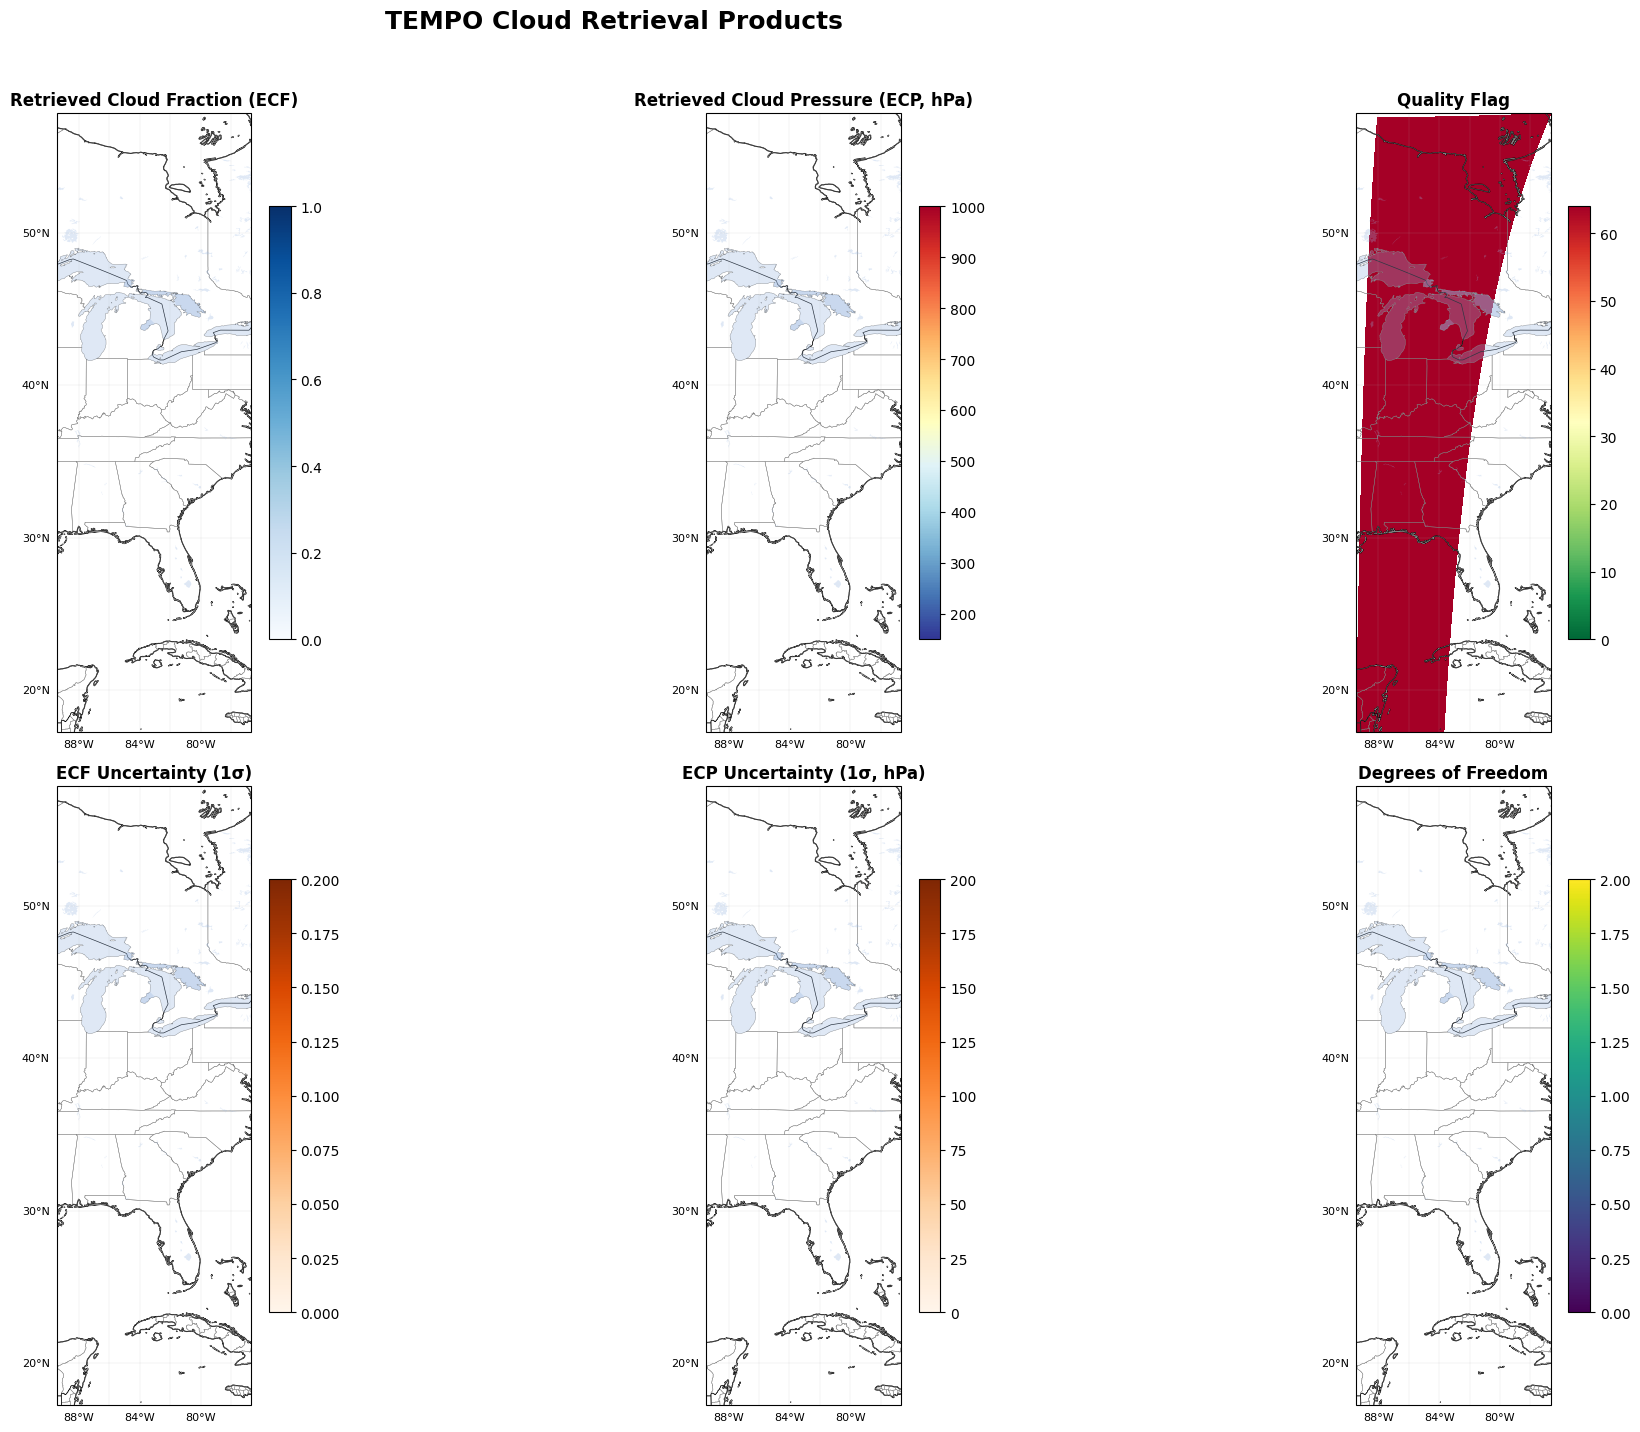

✅ Retrieved products visualized


In [38]:
# ============================================================
# VISUALIZE RETRIEVED CLOUD PRODUCTS
# Side-by-side with truth (if synthetic) or standalone (if real)
# ============================================================

if USE_REAL_DATA:
    lat_plot = parser.latitude
    lon_plot = parser.longitude
    extent = [np.nanmin(lon_plot), np.nanmax(lon_plot),
              np.nanmin(lat_plot), np.nanmax(lat_plot)]
else:
    lat_plot = lat_scene
    lon_plot = lon_scene
    extent = [lon_scene.min(), lon_scene.max(),
              lat_scene.min(), lat_scene.max()]

# ---- Figure 1: Retrieved products ----
fig, axes = plt.subplots(2, 3, figsize=(22, 14),
                          subplot_kw={'projection': ccrs.PlateCarree()})

panels = [
    # (data, title, cmap, vmin, vmax)
    (ecf_retrieved, 'Retrieved Cloud Fraction (ECF)', 'Blues', 0, 1),
    (ecp_retrieved, 'Retrieved Cloud Pressure (ECP, hPa)', 'RdYlBu_r', 150, 1000),
    (qa_flag_map.astype(float), 'Quality Flag', 'RdYlGn_r', 0, 64),
    (ecf_error, 'ECF Uncertainty (1σ)', 'Oranges', 0, 0.2),
    (ecp_error, 'ECP Uncertainty (1σ, hPa)', 'Oranges', 0, 200),
    (dfs_map, 'Degrees of Freedom', 'viridis', 0, 2),
]

for ax, (data, title, cmap, vmin, vmax) in zip(axes.flat, panels):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAKES, alpha=0.3)

    # Use pcolormesh for gridded data
    im = ax.pcolormesh(lon_plot, lat_plot, data,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(),
                       shading='auto')
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02, aspect=20)
    ax.set_title(title, fontsize=12, fontweight='bold')
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'fontsize': 8}
    gl.ylabel_style = {'fontsize': 8}

plt.suptitle('TEMPO Cloud Retrieval Products',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cloud_retrieval_products.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Retrieved products visualized")

In [39]:
# ============================================================
# RETRIEVED vs TRUTH COMPARISON (Synthetic data only)
# ============================================================

if not USE_REAL_DATA:

    fig, axes = plt.subplots(2, 3, figsize=(22, 14),
                              subplot_kw={'projection': ccrs.PlateCarree()})

    # Row 1: Cloud Fraction comparison
    # True CF
    ax = axes[0, 0]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    im = ax.pcolormesh(lon_plot, lat_plot, cf_scene, cmap='Blues',
                       vmin=0, vmax=1, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title('True Cloud Fraction', fontsize=12, fontweight='bold')

    # Retrieved CF
    ax = axes[0, 1]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    im = ax.pcolormesh(lon_plot, lat_plot, ecf_retrieved, cmap='Blues',
                       vmin=0, vmax=1, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_title('Retrieved Cloud Fraction', fontsize=12, fontweight='bold')

    # Difference CF
    cf_diff = ecf_retrieved - cf_scene
    ax = axes[0, 2]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    im = ax.pcolormesh(lon_plot, lat_plot, cf_diff, cmap='RdBu_r',
                       vmin=-0.3, vmax=0.3, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, shrink=0.7, label='Δcf')
    ax.set_title(f'CF Difference (Ret−True)\n'
                 f'Bias={np.nanmean(cf_diff):.4f}, RMSE={np.sqrt(np.nanmean(cf_diff**2)):.4f}',
                 fontsize=11, fontweight='bold')

    # Row 2: Cloud Pressure comparison
    # True CP
    ax = axes[1, 0]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    im = ax.pcolormesh(lon_plot, lat_plot, cp_scene, cmap='RdYlBu_r',
                       vmin=150, vmax=1000, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, shrink=0.7, label='hPa')
    ax.set_title('True Cloud Pressure', fontsize=12, fontweight='bold')

    # Retrieved CP
    ax = axes[1, 1]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    im = ax.pcolormesh(lon_plot, lat_plot, ecp_retrieved, cmap='RdYlBu_r',
                       vmin=150, vmax=1000, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, shrink=0.7, label='hPa')
    ax.set_title('Retrieved Cloud Pressure', fontsize=12, fontweight='bold')

    # Difference CP
    # Only compare where cf > 0.1 (cp is meaningless for clear sky)
    cloudy_mask = cf_scene > 0.1
    cp_diff = np.where(cloudy_mask, ecp_retrieved - cp_scene, np.nan)

    ax = axes[1, 2]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3)
    im = ax.pcolormesh(lon_plot, lat_plot, cp_diff, cmap='RdBu_r',
                       vmin=-200, vmax=200, transform=ccrs.PlateCarree())
    plt.colorbar(im, ax=ax, shrink=0.7, label='ΔhPa')
    ax.set_title(f'CP Difference (cloudy pixels only)\n'
                 f'Bias={np.nanmean(cp_diff):.1f} hPa, '
                 f'RMSE={np.sqrt(np.nanmean(cp_diff**2)):.1f} hPa',
                 fontsize=11, fontweight='bold')

    for ax in axes.flat:
        gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'fontsize': 7}
        gl.ylabel_style = {'fontsize': 7}

    plt.suptitle('Cloud Retrieval Validation: Retrieved vs Truth',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('retrieval_vs_truth_maps.png', dpi=200, bbox_inches='tight')
    plt.show()

    # ---- Scatter density plots ----
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    valid = ~np.isnan(ecf_retrieved.ravel()) & ~np.isnan(cf_scene.ravel())

    # CF scatter
    ax1 = axes[0]
    h1 = ax1.hist2d(cf_scene.ravel()[valid], ecf_retrieved.ravel()[valid],
                     bins=50, range=[[0,1],[0,1]], cmap='hot_r', cmin=1)
    ax1.plot([0,1], [0,1], 'b--', linewidth=2, label='1:1')
    ax1.set_xlabel('True Cloud Fraction', fontsize=12)
    ax1.set_ylabel('Retrieved Cloud Fraction', fontsize=12)

    cf_r2 = np.corrcoef(cf_scene.ravel()[valid], ecf_retrieved.ravel()[valid])[0,1]**2
    cf_bias_all = np.nanmean(ecf_retrieved.ravel()[valid] - cf_scene.ravel()[valid])
    cf_rmse_all = np.sqrt(np.nanmean((ecf_retrieved.ravel()[valid] - cf_scene.ravel()[valid])**2))

    ax1.set_title(f'Cloud Fraction\nR²={cf_r2:.3f}, Bias={cf_bias_all:+.4f}, RMSE={cf_rmse_all:.4f}',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.set_aspect('equal')
    plt.colorbar(h1[3], ax=ax1, label='Count')

    # CP scatter (cloudy pixels only)
    valid_cp = valid & (cf_scene.ravel() > 0.1)

    ax2 = axes[1]
    h2 = ax2.hist2d(cp_scene.ravel()[valid_cp], ecp_retrieved.ravel()[valid_cp],
                     bins=50, range=[[100,1050],[100,1050]], cmap='hot_r', cmin=1)
    ax2.plot([100,1050], [100,1050], 'b--', linewidth=2, label='1:1')
    ax2.set_xlabel('True Cloud Pressure (hPa)', fontsize=12)
    ax2.set_ylabel('Retrieved Cloud Pressure (hPa)', fontsize=12)

    cp_r2 = np.corrcoef(cp_scene.ravel()[valid_cp], ecp_retrieved.ravel()[valid_cp])[0,1]**2
    cp_bias_all = np.nanmean(ecp_retrieved.ravel()[valid_cp] - cp_scene.ravel()[valid_cp])
    cp_rmse_all = np.sqrt(np.nanmean((ecp_retrieved.ravel()[valid_cp] - cp_scene.ravel()[valid_cp])**2))

    ax2.set_title(f'Cloud Pressure (cf>0.1)\nR²={cp_r2:.3f}, Bias={cp_bias_all:+.1f} hPa, '
                  f'RMSE={cp_rmse_all:.1f} hPa',
                  fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.set_aspect('equal')
    plt.colorbar(h2[3], ax=ax2, label='Count')

    plt.suptitle('Retrieval Performance: Density Scatter Plots',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('retrieval_scatter_density.png', dpi=150, bbox_inches='tight')
    plt.show()

else:
    print("ℹ️  Using real data — no truth comparison available.")
    print("   Validate against TEMPO L2 Cloud product or independent observations.")

ℹ️  Using real data — no truth comparison available.
   Validate against TEMPO L2 Cloud product or independent observations.


In [40]:
# ============================================================
# EXPORT CLOUD RETRIEVAL PRODUCTS AS GEOTIFF
# Multi-band GeoTIFF with full metadata
# ============================================================
import rioxarray

geotiff_dir = Path("./tempo_cloud_geotiff")
geotiff_dir.mkdir(exist_ok=True)

timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")

def create_geotiff_from_retrieval(data_dict, lat_2d, lon_2d,
                                   output_path, resolution=0.02):
    """
    Create a multi-band GeoTIFF from retrieval results.

    Parameters:
        data_dict: dict of {band_name: 2D array}
        lat_2d, lon_2d: 2D coordinate arrays
        output_path: output file path
        resolution: output grid resolution in degrees
    """
    from scipy.interpolate import griddata

    # Define output regular grid
    lon_min, lon_max = np.nanmin(lon_2d), np.nanmax(lon_2d)
    lat_min, lat_max = np.nanmin(lat_2d), np.nanmax(lat_2d)

    grid_lon = np.arange(lon_min, lon_max + resolution/2, resolution)
    grid_lat = np.arange(lat_max, lat_min - resolution/2, -resolution)  # top to bottom
    grid_lon_2d, grid_lat_2d = np.meshgrid(grid_lon, grid_lat)

    n_bands = len(data_dict)
    n_y = len(grid_lat)
    n_x = len(grid_lon)

    print(f"  Output grid: {n_y} × {n_x} pixels, {n_bands} bands")
    print(f"  Resolution: {resolution}° (~{resolution * 111:.1f} km)")

    # Flatten source coordinates
    src_lon = lon_2d.ravel()
    src_lat = lat_2d.ravel()
    valid_coords = ~np.isnan(src_lon) & ~np.isnan(src_lat)
    points = np.column_stack([src_lon[valid_coords], src_lat[valid_coords]])

    # Regrid each band
    gridded_bands = {}
    band_names = list(data_dict.keys())

    for band_name, data_2d in data_dict.items():
        print(f"  ⏳ Regridding: {band_name}...")
        values = data_2d.ravel()[valid_coords]
        valid_data = ~np.isnan(values)

        if np.sum(valid_data) < 10:
            print(f"     ⚠️ Too few valid points for {band_name}, skipping")
            gridded_bands[band_name] = np.full((n_y, n_x), np.nan)
            continue

        gridded = griddata(
            points[valid_data],
            values[valid_data],
            (grid_lon_2d, grid_lat_2d),
            method='nearest'
        )
        gridded_bands[band_name] = gridded

    # Stack into 3D array (bands, y, x)
    data_3d = np.stack([gridded_bands[bn] for bn in band_names], axis=0)

    # Replace NaN with nodata value
    NODATA = -9999.0
    data_3d = np.where(np.isnan(data_3d), NODATA, data_3d).astype(np.float32)

    # Create xarray Dataset
    ds_out = xr.Dataset()

    for i, band_name in enumerate(band_names):
        da = xr.DataArray(
            data=data_3d[i],
            dims=['y', 'x'],
            coords={'y': grid_lat, 'x': grid_lon},
            name=band_name,
        )
        da = da.rio.set_spatial_dims(x_dim='x', y_dim='y')
        da = da.rio.write_crs("EPSG:4326")
        da = da.rio.write_nodata(NODATA)
        ds_out[band_name] = da

    # Add global attributes
    ds_out.attrs = {
        'title': 'TEMPO Cloud Retrieval Products',
        'institution': 'NASA ASDC / Earthdata Action Group',
        'source': 'O2-O2 (477 nm) DOAS + Optimal Estimation retrieval',
        'processing_date': datetime.now().isoformat(),
        'grid_resolution_degrees': resolution,
        'crs': 'EPSG:4326 (WGS84)',
        'nodata_value': NODATA,
        'algorithm': 'O2-O2 CIA cloud retrieval with IPA and OE inversion',
        'references': 'TEMPO ATBD; Veefkind et al. (2016)',
        'bands': ', '.join(band_names),
        'contact': 'NASA Atmospheric Science Data Center (ASDC)'
    }

    # Write individual GeoTIFFs per band
    output_files = []
    for band_name in band_names:
        band_path = output_path.replace('.tif', f'_{band_name}.tif')
        ds_out[band_name].rio.to_raster(
            band_path,
            driver='GTiff',
            dtype=np.float32,
            compress='LZW',
            tiled=True,
            blockxsize=256,
            blockysize=256,
        )
        output_files.append(band_path)
        print(f"  ✅ Saved: {band_path}")

    # Also write a single multi-band GeoTIFF
    multi_band = np.stack([
        gridded_bands[bn] for bn in band_names
    ], axis=0)
    multi_band = np.where(np.isnan(multi_band), NODATA, multi_band).astype(np.float32)

    da_multi = xr.DataArray(
        data=multi_band,
        dims=['band', 'y', 'x'],
        coords={
            'band': band_names,
            'y': grid_lat,
            'x': grid_lon
        }
    )
    da_multi = da_multi.rio.set_spatial_dims(x_dim='x', y_dim='y')
    da_multi = da_multi.rio.write_crs("EPSG:4326")
    da_multi = da_multi.rio.write_nodata(NODATA)
    da_multi.rio.to_raster(
        output_path,
        driver='GTiff',
        dtype=np.float32,
        compress='LZW',
        tiled=True,
    )
    output_files.append(output_path)
    print(f"  ✅ Multi-band: {output_path}")

    return output_files, grid_lon, grid_lat, gridded_bands

# ============================================================
# Define output bands and run export
# ============================================================
output_bands = {
    'cloud_fraction': ecf_retrieved,
    'cloud_pressure_hPa': ecp_retrieved,
    'cloud_fraction_error': ecf_error,
    'cloud_pressure_error': ecp_error,
    'quality_flag': qa_flag_map.astype(np.float32),
    'degrees_of_freedom': dfs_map,
    'doas_rms': doas_rms_map,
    'o2o2_scd': scd_observed_map.astype(np.float32),
}

print("=" * 60)
print("EXPORTING CLOUD PRODUCTS TO GEOTIFF")
print("=" * 60)
print(f"  Bands: {list(output_bands.keys())}")

output_path_main = str(geotiff_dir / f"TEMPO_Cloud_Retrieval_{timestamp_str}.tif")

output_files, out_lon, out_lat, out_data = create_geotiff_from_retrieval(
    data_dict=output_bands,
    lat_2d=lat_plot,
    lon_2d=lon_plot,
    output_path=output_path_main,
    resolution=0.05  # adjust based on needs
)

print(f"\n🎉 {len(output_files)} GeoTIFF files saved to: {geotiff_dir.resolve()}")

EXPORTING CLOUD PRODUCTS TO GEOTIFF
  Bands: ['cloud_fraction', 'cloud_pressure_hPa', 'cloud_fraction_error', 'cloud_pressure_error', 'quality_flag', 'degrees_of_freedom', 'doas_rms', 'o2o2_scd']
  Output grid: 814 × 257 pixels, 8 bands
  Resolution: 0.05° (~5.6 km)
  ⏳ Regridding: cloud_fraction...
     ⚠️ Too few valid points for cloud_fraction, skipping
  ⏳ Regridding: cloud_pressure_hPa...
     ⚠️ Too few valid points for cloud_pressure_hPa, skipping
  ⏳ Regridding: cloud_fraction_error...
     ⚠️ Too few valid points for cloud_fraction_error, skipping
  ⏳ Regridding: cloud_pressure_error...
     ⚠️ Too few valid points for cloud_pressure_error, skipping
  ⏳ Regridding: quality_flag...
  ⏳ Regridding: degrees_of_freedom...
     ⚠️ Too few valid points for degrees_of_freedom, skipping
  ⏳ Regridding: doas_rms...
     ⚠️ Too few valid points for doas_rms, skipping
  ⏳ Regridding: o2o2_scd...
     ⚠️ Too few valid points for o2o2_scd, skipping
  ✅ Saved: tempo_cloud_geotiff/TEMPO_Clou

In [41]:
# ============================================================
# VERIFY GEOTIFF OUTPUT
# Reload and validate all exported GeoTIFF files
# ============================================================
import rioxarray
import os

print("=" * 70)
print("GEOTIFF VERIFICATION")
print("=" * 70)

verification_results = []

for fpath in output_files:
    if not os.path.exists(fpath):
        print(f"  ❌ File not found: {fpath}")
        continue

    fname = Path(fpath).name
    fsize_mb = os.path.getsize(fpath) / (1024 * 1024)

    try:
        ds_check = rioxarray.open_rasterio(fpath)

        info = {
            'filename': fname,
            'size_mb': fsize_mb,
            'shape': ds_check.shape,
            'crs': str(ds_check.rio.crs),
            'resolution': ds_check.rio.resolution(),
            'bounds': ds_check.rio.bounds(),
            'nodata': ds_check.rio.nodata,
            'dtype': str(ds_check.dtype),
            'n_bands': ds_check.shape[0] if ds_check.ndim == 3 else 1,
        }

        # Compute stats excluding nodata
        data_vals = ds_check.values.copy().astype(float)
        nodata_val = ds_check.rio.nodata
        if nodata_val is not None:
            data_vals[data_vals == nodata_val] = np.nan

        info['data_min'] = float(np.nanmin(data_vals))
        info['data_max'] = float(np.nanmax(data_vals))
        info['data_mean'] = float(np.nanmean(data_vals))
        info['valid_pixels'] = int(np.sum(~np.isnan(data_vals)))
        info['total_pixels'] = int(data_vals.size)
        info['valid_pct'] = info['valid_pixels'] / max(info['total_pixels'], 1) * 100

        verification_results.append(info)

        print(f"\n  📁 {fname}")
        print(f"     Size:        {fsize_mb:.2f} MB")
        print(f"     Shape:       {ds_check.shape}")
        print(f"     CRS:         {info['crs']}")
        print(f"     Resolution:  {info['resolution']}")
        print(f"     Bounds:      W={info['bounds'][0]:.2f}, S={info['bounds'][1]:.2f}, "
              f"E={info['bounds'][2]:.2f}, N={info['bounds'][3]:.2f}")
        print(f"     NoData:      {info['nodata']}")
        print(f"     Data range:  [{info['data_min']:.4f}, {info['data_max']:.4f}]")
        print(f"     Mean:        {info['data_mean']:.4f}")
        print(f"     Valid:       {info['valid_pixels']:,}/{info['total_pixels']:,} "
              f"({info['valid_pct']:.1f}%)")
        print(f"     ✅ VALID")

        ds_check.close()

    except Exception as e:
        print(f"\n  ❌ {fname}: Error reading — {e}")

# ---- Summary table ----
print(f"\n{'='*70}")
print(f"VERIFICATION SUMMARY: {len(verification_results)} files verified successfully")
print(f"{'='*70}")
total_size = sum(v['size_mb'] for v in verification_results)
print(f"  Total size: {total_size:.2f} MB")
print(f"  All CRS: EPSG:4326 (WGS84)")

GEOTIFF VERIFICATION

  📁 TEMPO_Cloud_Retrieval_20260417_194716_cloud_fraction.tif
     Size:        0.01 MB
     Shape:       (1, 814, 257)
     CRS:         EPSG:4326
     Resolution:  (0.04999999999999716, -0.04999999999999716)
     Bounds:      W=-89.48, S=17.21, E=-76.63, N=57.91
     NoData:      -9999.0
     Data range:  [nan, nan]
     Mean:        nan
     Valid:       0/209,198 (0.0%)
     ✅ VALID

  📁 TEMPO_Cloud_Retrieval_20260417_194716_cloud_pressure_hPa.tif
     Size:        0.01 MB
     Shape:       (1, 814, 257)
     CRS:         EPSG:4326
     Resolution:  (0.04999999999999716, -0.04999999999999716)
     Bounds:      W=-89.48, S=17.21, E=-76.63, N=57.91
     NoData:      -9999.0
     Data range:  [nan, nan]
     Mean:        nan
     Valid:       0/209,198 (0.0%)
     ✅ VALID

  📁 TEMPO_Cloud_Retrieval_20260417_194716_cloud_fraction_error.tif
     Size:        0.01 MB
     Shape:       (1, 814, 257)
     CRS:         EPSG:4326
     Resolution:  (0.04999999999999716, -

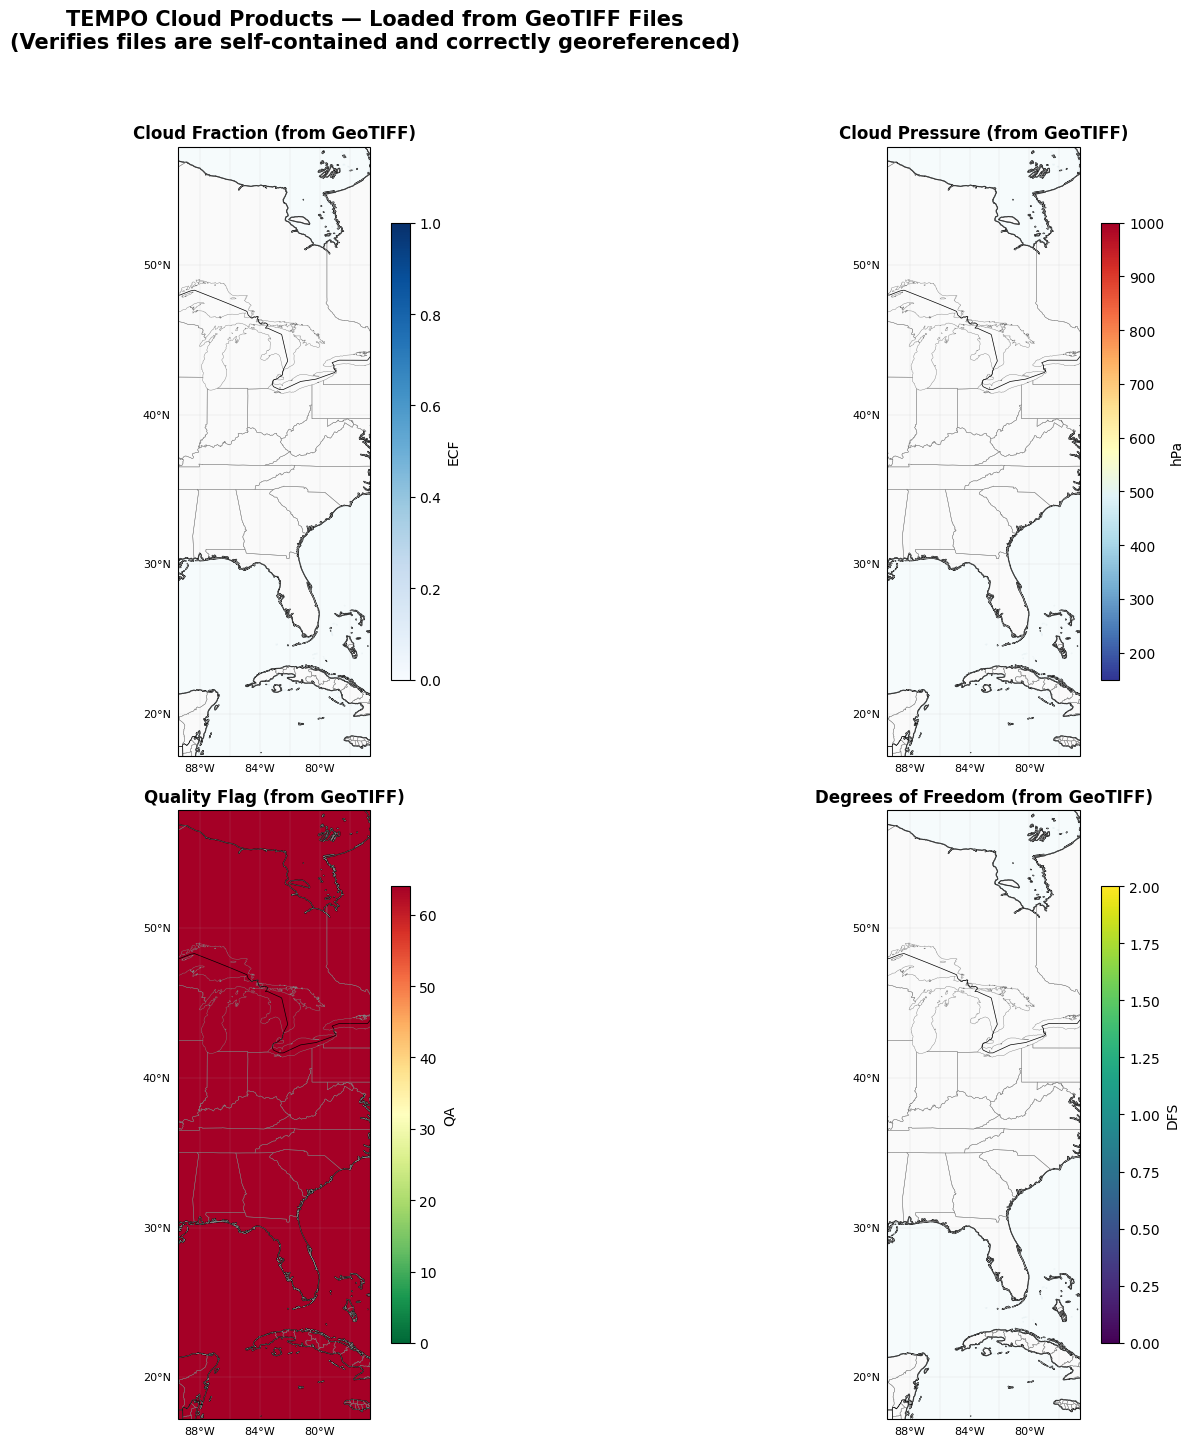

✅ GeoTIFF visualization complete — files verified!


In [42]:
# ============================================================
# VISUALIZE GEOTIFF PRODUCTS (read from disk)
# Proves the GeoTIFF files are self-contained and usable
# ============================================================

# Find the individual band files
cf_tiff = [f for f in output_files if 'cloud_fraction.' in f.lower() or
           'cloud_fraction_cloud_fraction' in f.lower()]
cp_tiff = [f for f in output_files if 'cloud_pressure_hpa' in f.lower()]
qa_tiff = [f for f in output_files if 'quality_flag' in f.lower()]
dfs_tiff = [f for f in output_files if 'degrees_of_freedom' in f.lower()]

# Use multi-band file as fallback
multi_tiff = [f for f in output_files if 'Cloud_Retrieval_' in f and
              '_cloud_fraction' not in f and '_cloud_pressure' not in f]

fig, axes = plt.subplots(2, 2, figsize=(18, 14),
                          subplot_kw={'projection': ccrs.PlateCarree()})

def plot_geotiff_band(ax, filepath, title, cmap, vmin, vmax,
                       cbar_label='', band_idx=0):
    """Load a GeoTIFF and plot on a map"""
    ds = rioxarray.open_rasterio(filepath)

    # Select band
    if ds.ndim == 3:
        data = ds[band_idx].values.astype(float)
    else:
        data = ds.values.astype(float)

    # Mask nodata
    nodata = ds.rio.nodata
    if nodata is not None:
        data[data == nodata] = np.nan

    # Get coordinate arrays
    x_coords = ds.x.values
    y_coords = ds.y.values

    bounds = ds.rio.bounds()
    ax.set_extent([bounds[0], bounds[2], bounds[1], bounds[3]],
                   crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, alpha=0.1, color='lightgray')
    ax.add_feature(cfeature.OCEAN, alpha=0.1, color='lightblue')

    im = ax.pcolormesh(x_coords, y_coords, data,
                       cmap=cmap, vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree(), shading='auto')

    cb = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02, aspect=25)
    cb.set_label(cbar_label, fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')

    gl = ax.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'fontsize': 8}
    gl.ylabel_style = {'fontsize': 8}

    ds.close()
    return data

# Plot each band from GeoTIFF files
try:
    if cf_tiff:
        plot_geotiff_band(axes[0,0], cf_tiff[0],
                          'Cloud Fraction (from GeoTIFF)',
                          'Blues', 0, 1, 'ECF')
    elif multi_tiff:
        plot_geotiff_band(axes[0,0], multi_tiff[0],
                          'Cloud Fraction (from multi-band GeoTIFF)',
                          'Blues', 0, 1, 'ECF', band_idx=0)
except Exception as e:
    print(f"⚠️ CF plot error: {e}")
    axes[0,0].set_title(f'Cloud Fraction — Error: {e}')

try:
    if cp_tiff:
        plot_geotiff_band(axes[0,1], cp_tiff[0],
                          'Cloud Pressure (from GeoTIFF)',
                          'RdYlBu_r', 150, 1000, 'hPa')
    elif multi_tiff:
        plot_geotiff_band(axes[0,1], multi_tiff[0],
                          'Cloud Pressure (from multi-band GeoTIFF)',
                          'RdYlBu_r', 150, 1000, 'hPa', band_idx=1)
except Exception as e:
    print(f"⚠️ CP plot error: {e}")
    axes[0,1].set_title(f'Cloud Pressure — Error: {e}')

try:
    if qa_tiff:
        plot_geotiff_band(axes[1,0], qa_tiff[0],
                          'Quality Flag (from GeoTIFF)',
                          'RdYlGn_r', 0, 64, 'QA')
    elif multi_tiff:
        plot_geotiff_band(axes[1,0], multi_tiff[0],
                          'Quality Flag (from multi-band GeoTIFF)',
                          'RdYlGn_r', 0, 64, 'QA', band_idx=4)
except Exception as e:
    print(f"⚠️ QA plot error: {e}")

try:
    if dfs_tiff:
        plot_geotiff_band(axes[1,1], dfs_tiff[0],
                          'Degrees of Freedom (from GeoTIFF)',
                          'viridis', 0, 2, 'DFS')
    elif multi_tiff:
        plot_geotiff_band(axes[1,1], multi_tiff[0],
                          'Degrees of Freedom (from multi-band GeoTIFF)',
                          'viridis', 0, 2, 'DFS', band_idx=5)
except Exception as e:
    print(f"⚠️ DFS plot error: {e}")

plt.suptitle('TEMPO Cloud Products — Loaded from GeoTIFF Files\n'
             '(Verifies files are self-contained and correctly georeferenced)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('geotiff_product_verification.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ GeoTIFF visualization complete — files verified!")

CLOUD TYPE CLASSIFICATION RESULTS
Type                       Code      Count   Fraction
------------------------------------------------------------
Clear                         0          0       0.0%
Cirrus                        1          0       0.0%
Cirrostratus                  2          0       0.0%
Deep Convection               3          0       0.0%
Altocumulus (thin)            4          0       0.0%
Altostratus                   5          0       0.0%
Nimbostratus                  6          0       0.0%
Cumulus                       7          0       0.0%
Stratocumulus                 8          0       0.0%
Stratus                       9          0       0.0%
Invalid                     255    270,336
------------------------------------------------------------
Total valid                              0


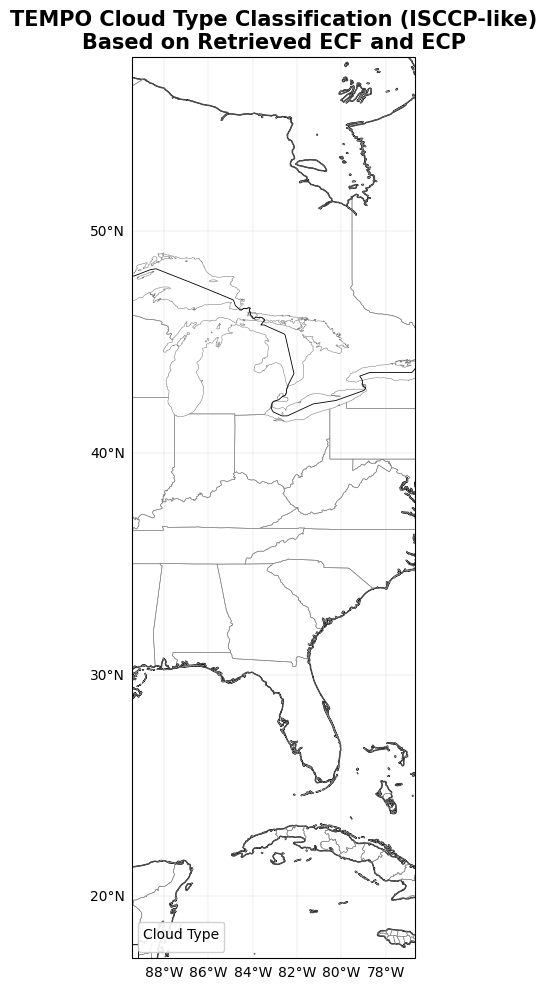

✅ Cloud type classification complete


In [43]:
# ============================================================
# CLOUD TYPE CLASSIFICATION
# Classify retrieved clouds using ISCCP-like categories
# based on cloud pressure and optical thickness proxy (cf)
# ============================================================

def classify_clouds(cloud_fraction, cloud_pressure, qa_flags):
    """
    Classify clouds into ISCCP-like categories.

    Categories based on Cloud-Top Pressure:
        High:   cp < 440 hPa
        Mid:    440 ≤ cp < 680 hPa
        Low:    cp ≥ 680 hPa

    Sub-categories based on Cloud Fraction (optical thickness proxy):
        Thin:       cf < 0.3
        Medium:     0.3 ≤ cf < 0.7
        Thick:      cf ≥ 0.7

    ISCCP-like types:
        High + Thin   = Cirrus
        High + Medium = Cirrostratus
        High + Thick  = Deep Convection
        Mid + Thin    = Altocumulus (thin)
        Mid + Medium  = Altostratus
        Mid + Thick   = Nimbostratus
        Low + Thin    = Cumulus
        Low + Medium  = Stratocumulus
        Low + Thick   = Stratus
    """
    n_rows, n_cols = cloud_fraction.shape

    # Cloud type codes
    CLEAR = 0
    CIRRUS = 1
    CIRROSTRATUS = 2
    DEEP_CONVECTION = 3
    ALTOCUMULUS_THIN = 4
    ALTOSTRATUS = 5
    NIMBOSTRATUS = 6
    CUMULUS = 7
    STRATOCUMULUS = 8
    STRATUS = 9
    INVALID = 255

    cloud_type = np.full((n_rows, n_cols), INVALID, dtype=np.uint8)

    type_names = {
        CLEAR: 'Clear',
        CIRRUS: 'Cirrus',
        CIRROSTRATUS: 'Cirrostratus',
        DEEP_CONVECTION: 'Deep Convection',
        ALTOCUMULUS_THIN: 'Altocumulus (thin)',
        ALTOSTRATUS: 'Altostratus',
        NIMBOSTRATUS: 'Nimbostratus',
        CUMULUS: 'Cumulus',
        STRATOCUMULUS: 'Stratocumulus',
        STRATUS: 'Stratus',
        INVALID: 'Invalid'
    }

    type_colors = {
        CLEAR: '#FFFFFF',
        CIRRUS: '#B0E0FF',
        CIRROSTRATUS: '#60B0FF',
        DEEP_CONVECTION: '#0040C0',
        ALTOCUMULUS_THIN: '#C0FFC0',
        ALTOSTRATUS: '#60C060',
        NIMBOSTRATUS: '#208020',
        CUMULUS: '#FFE0A0',
        STRATOCUMULUS: '#FFA040',
        STRATUS: '#C04000',
        INVALID: '#808080'
    }

    for row in range(n_rows):
        for col in range(n_cols):
            cf = cloud_fraction[row, col]
            cp = cloud_pressure[row, col]
            qa = qa_flags[row, col]

            # Skip invalid pixels
            if np.isnan(cf) or np.isnan(cp) or qa >= 128:
                cloud_type[row, col] = INVALID
                continue

            # Clear sky
            if cf < 0.05:
                cloud_type[row, col] = CLEAR
                continue

            # Classify by pressure level
            if cp < 440:  # High cloud
                if cf < 0.3:
                    cloud_type[row, col] = CIRRUS
                elif cf < 0.7:
                    cloud_type[row, col] = CIRROSTRATUS
                else:
                    cloud_type[row, col] = DEEP_CONVECTION

            elif cp < 680:  # Mid-level cloud
                if cf < 0.3:
                    cloud_type[row, col] = ALTOCUMULUS_THIN
                elif cf < 0.7:
                    cloud_type[row, col] = ALTOSTRATUS
                else:
                    cloud_type[row, col] = NIMBOSTRATUS

            else:  # Low cloud
                if cf < 0.3:
                    cloud_type[row, col] = CUMULUS
                elif cf < 0.7:
                    cloud_type[row, col] = STRATOCUMULUS
                else:
                    cloud_type[row, col] = STRATUS

    return cloud_type, type_names, type_colors

# ---- Run classification ----
cloud_type_map, type_names, type_colors = classify_clouds(
    ecf_retrieved, ecp_retrieved, qa_flag_map)

# ---- Statistics ----
print("=" * 60)
print("CLOUD TYPE CLASSIFICATION RESULTS")
print("=" * 60)
print(f"{'Type':<25} {'Code':>5} {'Count':>10} {'Fraction':>10}")
print("-" * 60)

total_valid = np.sum(cloud_type_map != 255)
for code in sorted(type_names.keys()):
    if code == 255:
        continue
    count = np.sum(cloud_type_map == code)
    frac = count / max(total_valid, 1) * 100
    print(f"{type_names[code]:<25} {code:>5} {count:>10,} {frac:>9.1f}%")

invalid_count = np.sum(cloud_type_map == 255)
print(f"{'Invalid':<25} {'255':>5} {invalid_count:>10,}")
print("-" * 60)
print(f"{'Total valid':<25} {'':>5} {total_valid:>10,}")

# ---- Visualization ----
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Create custom colormap
valid_codes = [k for k in sorted(type_names.keys()) if k != 255]
cmap_colors = [type_colors[c] for c in valid_codes]
cmap_custom = ListedColormap(cmap_colors)
bounds = [c - 0.5 for c in valid_codes] + [valid_codes[-1] + 0.5]
norm = BoundaryNorm(bounds, cmap_custom.N)

# Mask invalid
cloud_type_plot = cloud_type_map.astype(float)
cloud_type_plot[cloud_type_map == 255] = np.nan

fig, ax = plt.subplots(figsize=(16, 10),
                        subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([np.nanmin(lon_plot), np.nanmax(lon_plot),
               np.nanmin(lat_plot), np.nanmax(lat_plot)],
              crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1, color='black')
ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

im = ax.pcolormesh(lon_plot, lat_plot, cloud_type_plot,
                   cmap=cmap_custom, norm=norm,
                   transform=ccrs.PlateCarree(), shading='auto')

# Custom legend
legend_elements = []
for code in valid_codes:
    count = np.sum(cloud_type_map == code)
    if count > 0:
        legend_elements.append(
            Patch(facecolor=type_colors[code], edgecolor='black',
                  label=f"{type_names[code]} ({count:,})")
        )

ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
          ncol=2, framealpha=0.9, title='Cloud Type', title_fontsize=10)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ax.set_title('TEMPO Cloud Type Classification (ISCCP-like)\n'
             'Based on Retrieved ECF and ECP', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('cloud_type_classification.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Cloud type classification complete")

In [44]:
# ============================================================
# EXPORT CLOUD TYPE CLASSIFICATION AS GEOTIFF
# ============================================================
from scipy.interpolate import griddata

RESOLUTION_OUT = 0.05  # degrees

# Regular output grid
lon_min_out = np.nanmin(lon_plot)
lon_max_out = np.nanmax(lon_plot)
lat_min_out = np.nanmin(lat_plot)
lat_max_out = np.nanmax(lat_plot)

grid_lon_out = np.arange(lon_min_out, lon_max_out + RESOLUTION_OUT/2, RESOLUTION_OUT)
grid_lat_out = np.arange(lat_max_out, lat_min_out - RESOLUTION_OUT/2, -RESOLUTION_OUT)
grid_lon_2d_out, grid_lat_2d_out = np.meshgrid(grid_lon_out, grid_lat_out)

# Flatten and filter valid coordinates
src_lon = lon_plot.ravel()
src_lat = lat_plot.ravel()
valid_mask = ~np.isnan(src_lon) & ~np.isnan(src_lat)
points = np.column_stack([src_lon[valid_mask], src_lat[valid_mask]])

# Regrid cloud type (use nearest - categorical data)
ct_values = cloud_type_map.ravel()[valid_mask].astype(float)
ct_valid = ct_values != 255
ct_gridded = griddata(
    points[ct_valid], ct_values[ct_valid],
    (grid_lon_2d_out, grid_lat_2d_out),
    method='nearest'
)

# Save as GeoTIFF
NODATA_CT = 255
ct_gridded_int = np.where(np.isnan(ct_gridded), NODATA_CT, ct_gridded).astype(np.uint8)

da_ct = xr.DataArray(
    data=ct_gridded_int.astype(np.float32),
    dims=['y', 'x'],
    coords={'y': grid_lat_out, 'x': grid_lon_out},
    attrs={
        'long_name': 'ISCCP-like Cloud Type Classification',
        'units': 'category_code',
        'flag_values': '0,1,2,3,4,5,6,7,8,9,255',
        'flag_meanings': ('Clear Cirrus Cirrostratus Deep_Convection '
                          'Altocumulus_thin Altostratus Nimbostratus '
                          'Cumulus Stratocumulus Stratus Invalid'),
    }
)
da_ct = da_ct.rio.set_spatial_dims(x_dim='x', y_dim='y')
da_ct = da_ct.rio.write_crs("EPSG:4326")
da_ct = da_ct.rio.write_nodata(float(NODATA_CT))

ct_output_path = str(geotiff_dir / f"TEMPO_CloudType_{timestamp_str}.tif")
da_ct.rio.to_raster(
    ct_output_path,
    driver='GTiff', dtype=np.float32,
    compress='LZW', tiled=True
)
print(f"✅ Cloud type GeoTIFF saved: {ct_output_path}")

✅ Cloud type GeoTIFF saved: tempo_cloud_geotiff/TEMPO_CloudType_20260417_194716.tif


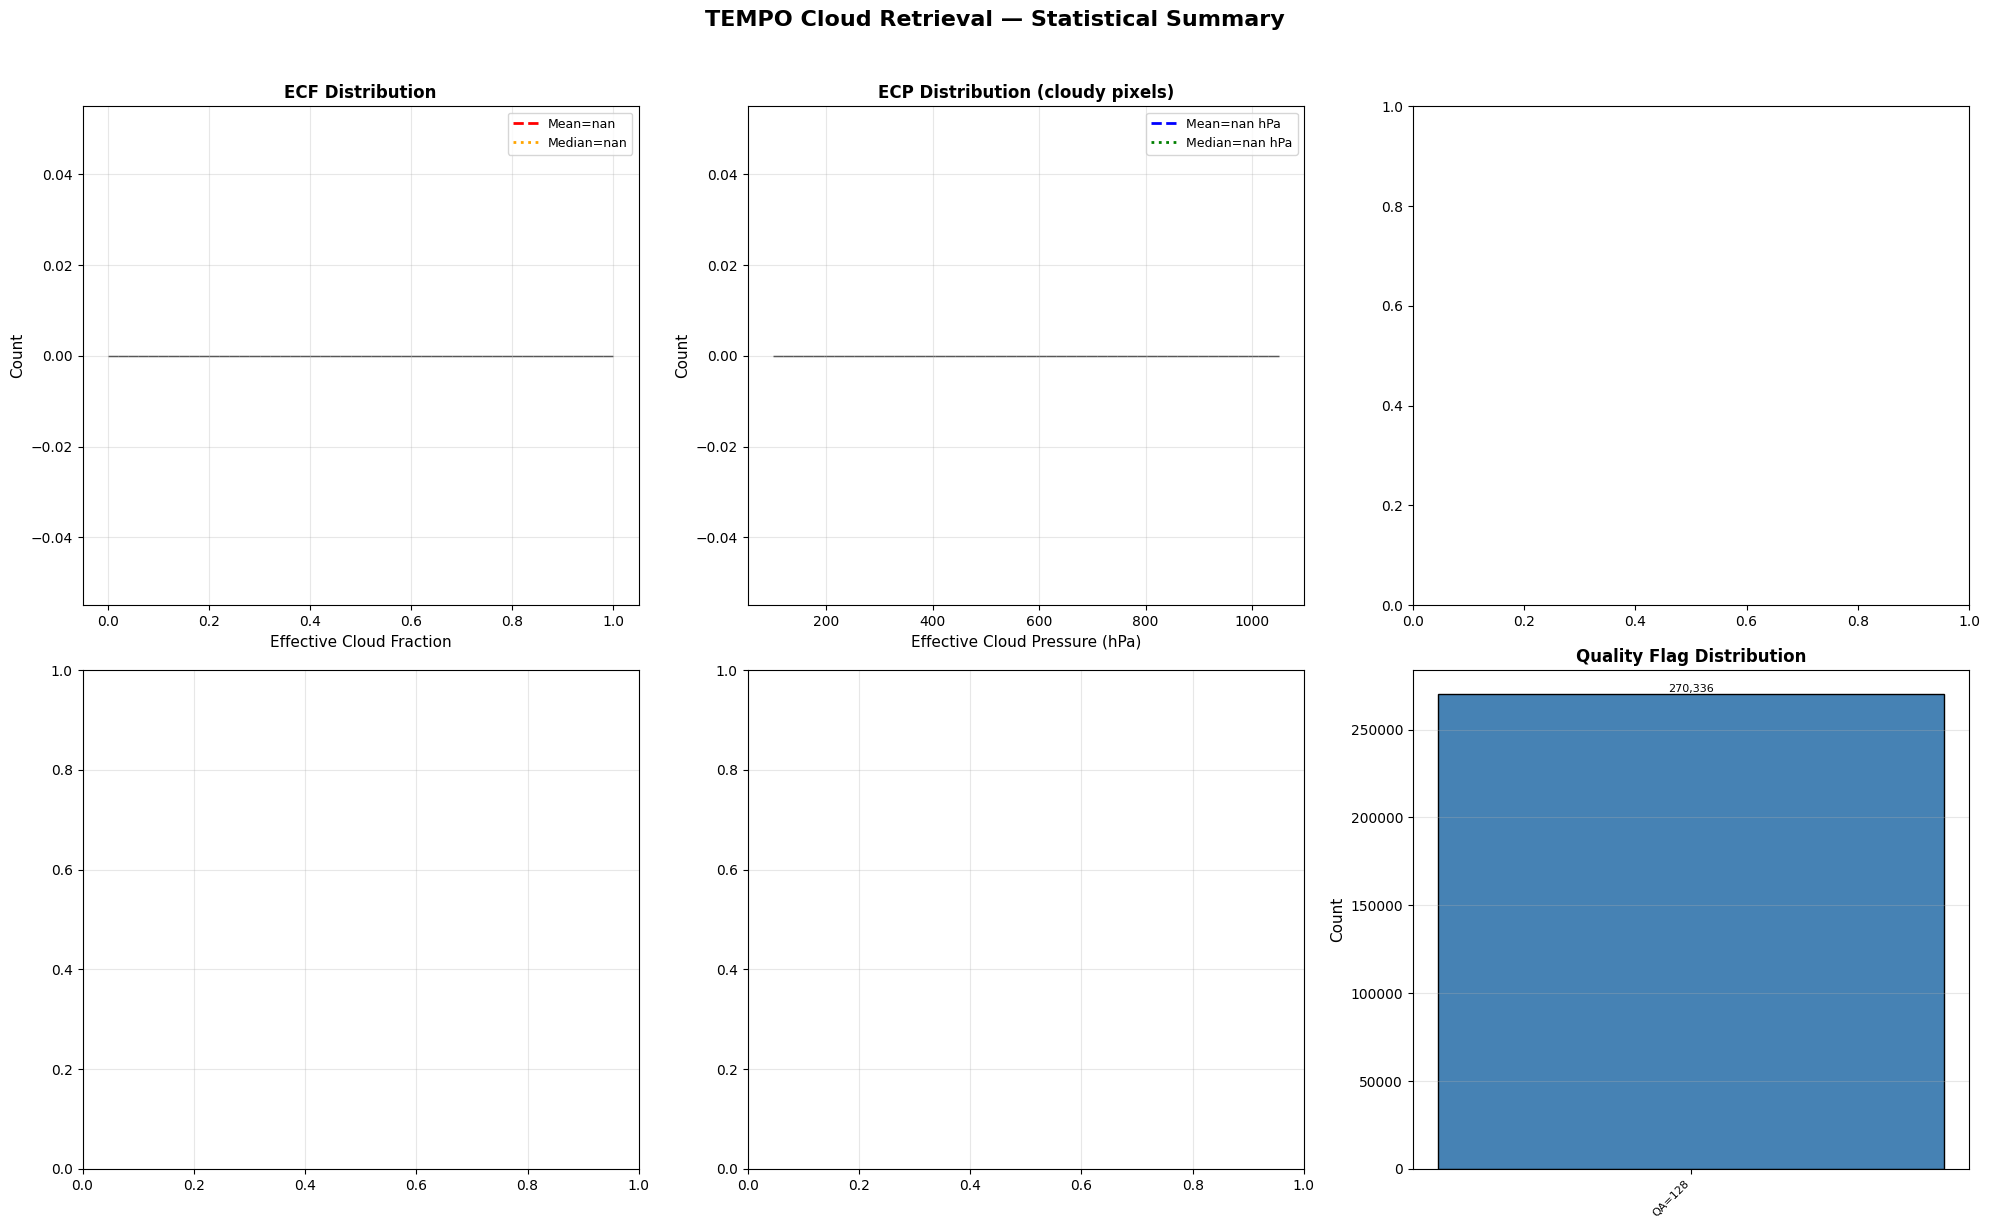

In [45]:
# ============================================================
# COMPREHENSIVE STATISTICAL SUMMARY
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ---- Panel 1: ECF Histogram ----
ax = axes[0, 0]
valid_ecf = ecf_retrieved[~np.isnan(ecf_retrieved)]
ax.hist(valid_ecf, bins=50, range=(0, 1), color='steelblue',
        edgecolor='black', alpha=0.8)
ax.axvline(np.nanmean(valid_ecf), color='red', linestyle='--', linewidth=2,
           label=f'Mean={np.nanmean(valid_ecf):.3f}')
ax.axvline(np.nanmedian(valid_ecf), color='orange', linestyle=':', linewidth=2,
           label=f'Median={np.nanmedian(valid_ecf):.3f}')
ax.set_xlabel('Effective Cloud Fraction', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('ECF Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- Panel 2: ECP Histogram ----
ax = axes[0, 1]
valid_ecp = ecp_retrieved[~np.isnan(ecp_retrieved) & (ecf_retrieved > 0.05)]
ax.hist(valid_ecp, bins=50, range=(100, 1050), color='coral',
        edgecolor='black', alpha=0.8)
ax.axvline(np.nanmean(valid_ecp), color='blue', linestyle='--', linewidth=2,
           label=f'Mean={np.nanmean(valid_ecp):.0f} hPa')
ax.axvline(np.nanmedian(valid_ecp), color='green', linestyle=':', linewidth=2,
           label=f'Median={np.nanmedian(valid_ecp):.0f} hPa')
ax.set_xlabel('Effective Cloud Pressure (hPa)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('ECP Distribution (cloudy pixels)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ---- Panel 3: Joint ECF-ECP distribution ----
ax = axes[0, 2]
valid_joint = ~np.isnan(ecf_retrieved.ravel()) & ~np.isnan(ecp_retrieved.ravel()) & \
              (ecf_retrieved.ravel() > 0.05)
if np.sum(valid_joint) > 10:
    h = ax.hist2d(ecf_retrieved.ravel()[valid_joint],
                   ecp_retrieved.ravel()[valid_joint],
                   bins=[30, 30], range=[[0,1],[100,1050]],
                   cmap='YlOrRd', cmin=1)
    plt.colorbar(h[3], ax=ax, label='Count')

    # ISCCP grid lines
    ax.axhline(440, color='blue', linestyle='--', alpha=0.5, label='High/Mid boundary')
    ax.axhline(680, color='green', linestyle='--', alpha=0.5, label='Mid/Low boundary')
    ax.axvline(0.3, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(0.7, color='gray', linestyle=':', alpha=0.5)

    ax.set_xlabel('Cloud Fraction', fontsize=11)
    ax.set_ylabel('Cloud Pressure (hPa)', fontsize=11)
    ax.set_title('Joint CF-CP Distribution\n(ISCCP grid overlay)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.invert_yaxis()

# ---- Panel 4: O2-O2 SCD histogram ----
ax = axes[1, 0]
valid_scd = scd_observed_map[~np.isnan(scd_observed_map)]
if len(valid_scd) > 0:
    ax.hist(valid_scd, bins=50, color='mediumpurple', edgecolor='black', alpha=0.8)
    ax.set_xlabel('O₂-O₂ Slant Column Density (molec² cm⁻⁵)', fontsize=10)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('O₂-O₂ SCD Distribution', fontsize=12, fontweight='bold')
    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
ax.grid(True, alpha=0.3)

# ---- Panel 5: DOAS RMS histogram ----
ax = axes[1, 1]
valid_rms = doas_rms_map[~np.isnan(doas_rms_map)]
if len(valid_rms) > 0:
    ax.hist(valid_rms, bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
    ax.axvline(np.nanmedian(valid_rms), color='red', linestyle='--',
               label=f'Median={np.nanmedian(valid_rms):.2e}')
    ax.set_xlabel('DOAS Fit RMS Residual', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('DOAS Fit Quality', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.ticklabel_format(style='scientific', axis='x', scilimits=(0,0))
ax.grid(True, alpha=0.3)

# ---- Panel 6: QA flag distribution ----
ax = axes[1, 2]
qa_valid = qa_flag_map[qa_flag_map != 255]
qa_unique, qa_counts = np.unique(qa_valid, return_counts=True)

# Decode QA flags
qa_labels = []
for q in qa_unique:
    parts = []
    if q == 0:
        parts.append('Good')
    else:
        if q & 1:  parts.append('NoConv')
        if q & 2:  parts.append('CF_bound')
        if q & 4:  parts.append('CP_bound')
        if q & 8:  parts.append('DOAS_poor')
        if q & 16: parts.append('HighSZA')
        if q & 32: parts.append('LowDFS')
    qa_labels.append('+'.join(parts) if parts else f'QA={q}')

bars = ax.bar(range(len(qa_unique)), qa_counts, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(qa_unique)))
ax.set_xticklabels(qa_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Quality Flag Distribution', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Annotate counts
for bar, count in zip(bars, qa_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('TEMPO Cloud Retrieval — Statistical Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('retrieval_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# ============================================================
# GENERATE COMPREHENSIVE METADATA REPORT
# ============================================================

report_path = geotiff_dir / f"TEMPO_Cloud_Retrieval_Report_{timestamp_str}.txt"

with open(report_path, 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("TEMPO CLOUD RETRIEVAL PRODUCT REPORT\n")
    f.write("=" * 80 + "\n\n")

    f.write(f"Generation Date:    {datetime.now().isoformat()}\n")
    f.write(f"Algorithm:          O₂-O₂ (477 nm) DOAS + Optimal Estimation\n")
    f.write(f"Software Version:   1.0.0-alpha\n")
    f.write(f"Processing System:  TEMPO Cloud Retrieval Notebook\n")
    f.write(f"Data Source:        {'Real TEMPO L1B' if USE_REAL_DATA else 'Synthetic L1B'}\n\n")

    # ---- Algorithm description ----
    f.write("-" * 80 + "\n")
    f.write("ALGORITHM DESCRIPTION\n")
    f.write("-" * 80 + "\n\n")
    f.write("1. DOAS Spectral Fitting:\n")
    f.write("   - Spectral window: 455-500 nm\n")
    f.write("   - Target absorber: O₂-O₂ collision-induced absorption (477 nm)\n")
    f.write("   - Ring effect: Rayleigh scattering proxy\n")
    f.write("   - Closure polynomial: degree 3\n")
    f.write("   - Output: O₂-O₂ slant column density (SCD)\n\n")

    f.write("2. Continuum Analysis:\n")
    f.write("   - Window: 490-498 nm (outside O₂-O₂ band)\n")
    f.write("   - Provides effective scene albedo\n")
    f.write("   - Independent constraint on cloud fraction\n\n")

    f.write("3. Retrieval Inversion:\n")
    f.write("   - Method: Levenberg-Marquardt Optimal Estimation\n")
    f.write("   - State vector: [cloud_fraction, cloud_pressure]\n")
    f.write("   - Measurement vector: [O₂-O₂ SCD, continuum ratio]\n")
    f.write("   - Forward model: LUT-based IPA (Independent Pixel Approximation)\n")
    f.write(f"   - A priori: cf={retrieval.xa[0]:.1f}, cp={retrieval.xa[1]:.0f} hPa\n")
    f.write(f"   - Max iterations: {retrieval.max_iterations}\n")
    f.write(f"   - Convergence threshold: ΔJ/J < {retrieval.convergence_threshold}\n\n")

    f.write("4. Physical Model:\n")
    f.write("   - O₂-O₂ cross-section: Thalman & Volkamer (2013) parameterization\n")
    f.write("   - Rayleigh scattering: Bodhaine et al. (1999)\n")
    f.write("   - Atmospheric profile: US Standard Atmosphere\n")
    f.write("   - Cloud model: Lambertian reflector (albedo=0.80)\n")
    f.write("   - Scene model: IPA (clear + cloudy sub-pixels)\n\n")

    # ---- LUT parameters ----
    f.write("-" * 80 + "\n")
    f.write("LOOKUP TABLE PARAMETERS\n")
    f.write("-" * 80 + "\n\n")
    f.write(f"  Cloud fraction:    {len(cf_grid)} points [{cf_grid[0]:.2f} — {cf_grid[-1]:.2f}]\n")
    f.write(f"  Cloud pressure:    {len(cp_grid)} points [{cp_grid[0]:.0f} — {cp_grid[-1]:.0f}] hPa\n")
    f.write(f"  Solar zenith:      {len(sza_grid)} points [{sza_grid[0]:.0f} — {sza_grid[-1]:.0f}]°\n")
    f.write(f"  Viewing zenith:    {len(vza_grid)} points [{vza_grid[0]:.0f} — {vza_grid[-1]:.0f}]°\n")
    f.write(f"  Surface albedo:    {len(albedo_grid)} points [{albedo_grid[0]:.2f} — {albedo_grid[-1]:.2f}]\n")
    f.write(f"  Surface pressure:  {len(ps_grid)} points [{ps_grid[0]:.0f} — {ps_grid[-1]:.0f}] hPa\n")
    total_lut = (len(cf_grid) * len(cp_grid) * len(sza_grid) *
                 len(vza_grid) * len(albedo_grid) * len(ps_grid))
    f.write(f"  Total LUT entries: {total_lut:,}\n\n")

    # ---- Scene information ----
    f.write("-" * 80 + "\n")
    f.write("SCENE INFORMATION\n")
    f.write("-" * 80 + "\n\n")
    f.write(f"  Dimensions:        {n_rows} × {n_cols} pixels\n")
    f.write(f"  Latitude range:    [{np.nanmin(lat_plot):.2f}, {np.nanmax(lat_plot):.2f}]°\n")
    f.write(f"  Longitude range:   [{np.nanmin(lon_plot):.2f}, {np.nanmax(lon_plot):.2f}]°\n")

    if not USE_REAL_DATA:
        f.write(f"  SZA range:         [{np.nanmin(sza_scene):.1f}, {np.nanmax(sza_scene):.1f}]°\n")
        f.write(f"  VZA range:         [{np.nanmin(vza_scene):.1f}, {np.nanmax(vza_scene):.1f}]°\n")
    f.write(f"  SZA limit applied: {SZA_MAX}°\n\n")

    # ---- Processing statistics ----
    f.write("-" * 80 + "\n")
    f.write("PROCESSING STATISTICS\n")
    f.write("-" * 80 + "\n\n")
    f.write(f"  Total pixels:      {total_pixels:,}\n")
    f.write(f"  Successful:        {successful:,} ({successful/total_pixels*100:.1f}%)\n")
    f.write(f"  Failed:            {failed:,} ({failed/total_pixels*100:.1f}%)\n")
    f.write(f"  Skipped:           {skipped:,} ({skipped/total_pixels*100:.1f}%)\n")
    f.write(f"  Processing time:   {elapsed_total:.1f} seconds\n")
    f.write(f"  Processing rate:   {total_pixels/elapsed_total:.1f} pixels/second\n\n")

    # ---- Product statistics ----
    f.write("-" * 80 + "\n")
    f.write("PRODUCT STATISTICS\n")
    f.write("-" * 80 + "\n\n")

    stats_items = [
        ('Cloud Fraction (ECF)', ecf_retrieved, ''),
        ('Cloud Pressure (ECP)', ecp_retrieved, 'hPa'),
        ('ECF Uncertainty', ecf_error, ''),
        ('ECP Uncertainty', ecp_error, 'hPa'),
        ('O₂-O₂ SCD', scd_observed_map, 'molec² cm⁻⁵'),
        ('DOAS RMS', doas_rms_map, ''),
        ('Degrees of Freedom', dfs_map, ''),
        ('Cost Function', cost_map, ''),
    ]

    f.write(f"  {'Variable':<25} {'Min':>14} {'Max':>14} {'Mean':>14} {'Std':>14} {'Unit':<15}\n")
    f.write(f"  {'-'*25} {'-'*14} {'-'*14} {'-'*14} {'-'*14} {'-'*15}\n")

    for name, data, unit in stats_items:
        valid_data = data[~np.isnan(data)]
        if len(valid_data) > 0:
            f.write(f"  {name:<25} {np.min(valid_data):>14.4e} {np.max(valid_data):>14.4e} "
                    f"{np.mean(valid_data):>14.4e} {np.std(valid_data):>14.4e} {unit:<15}\n")
        else:
            f.write(f"  {name:<25} {'N/A':>14} {'N/A':>14} {'N/A':>14} {'N/A':>14} {unit:<15}\n")

    # ---- Quality flag definitions ----
    f.write("\n" + "-" * 80 + "\n")
    f.write("QUALITY FLAG DEFINITIONS\n")
    f.write("-" * 80 + "\n\n")
    f.write("  Bit  Value  Meaning\n")
    f.write("  ---  -----  -------\n")
    f.write("   0      1   Retrieval did not converge\n")
    f.write("   1      2   Cloud fraction at boundary (0 or 1)\n")
    f.write("   2      4   Cloud pressure at boundary\n")
    f.write("   3      8   Poor DOAS fit (RMS > 0.01)\n")
    f.write("   4     16   High solar zenith angle (SZA > 75°)\n")
    f.write("   5     32   Low information content (DFS < 0.5)\n")
    f.write("   6     64   Reserved\n")
    f.write("   7    128   Pixel skipped (SZA exceeded)\n")
    f.write("   -    254   Processing error\n")
    f.write("   -    255   Invalid / no data\n")
    f.write("\n  QA=0 indicates highest quality retrieval.\n")
    f.write("  Flags are combined as bit-wise OR.\n\n")

    # ---- Cloud type classification ----
    f.write("-" * 80 + "\n")
    f.write("CLOUD TYPE CLASSIFICATION (ISCCP-LIKE)\n")
    f.write("-" * 80 + "\n\n")
    f.write("  Code  Type                  CP Range         CF Range\n")
    f.write("  ----  --------------------  ---------------  -----------\n")
    f.write("    0   Clear                 —                cf < 0.05\n")
    f.write("    1   Cirrus                cp < 440 hPa     cf < 0.3\n")
    f.write("    2   Cirrostratus          cp < 440 hPa     0.3 ≤ cf < 0.7\n")
    f.write("    3   Deep Convection       cp < 440 hPa     cf ≥ 0.7\n")
    f.write("    4   Altocumulus (thin)    440 ≤ cp < 680   cf < 0.3\n")
    f.write("    5   Altostratus           440 ≤ cp < 680   0.3 ≤ cf < 0.7\n")
    f.write("    6   Nimbostratus          440 ≤ cp < 680   cf ≥ 0.7\n")
    f.write("    7   Cumulus               cp ≥ 680 hPa     cf < 0.3\n")
    f.write("    8   Stratocumulus         cp ≥ 680 hPa     0.3 ≤ cf < 0.7\n")
    f.write("    9   Stratus               cp ≥ 680 hPa     cf ≥ 0.7\n")
    f.write("  255   Invalid               —                —\n\n")

    # ---- Output files ----
    f.write("-" * 80 + "\n")
    f.write("OUTPUT FILES\n")
    f.write("-" * 80 + "\n\n")

    for fpath in output_files:
        fname = Path(fpath).name
        fsize = os.path.getsize(fpath) / (1024*1024)
        f.write(f"  📁 {fname}  ({fsize:.2f} MB)\n")

    f.write(f"\n  📁 {Path(ct_output_path).name}  (Cloud Type)\n")
    f.write(f"  📁 {Path(report_path).name}  (This report)\n\n")

    f.write("  All GeoTIFF files:\n")
    f.write("    - CRS: EPSG:4326 (WGS84)\n")
    f.write(f"    - Resolution: {RESOLUTION_OUT}° (~{RESOLUTION_OUT*111:.1f} km)\n")
    f.write("    - Compression: LZW\n")
    f.write("    - NoData: -9999.0 (products), 255 (cloud type)\n\n")

    # ---- References ----
    f.write("-" * 80 + "\n")
    f.write("REFERENCES\n")
    f.write("-" * 80 + "\n\n")
    f.write("  [1] Veefkind, J.P., et al. (2016). TROPOMI on the ESA Sentinel-5\n")
    f.write("      Precursor: A GMES mission for global observations of the atmospheric\n")
    f.write("      composition. Remote Sens. Environ., 120, 70-83.\n\n")
    f.write("  [2] Thalman, R. and Volkamer, R. (2013). Temperature dependent absorption\n")
    f.write("      cross-sections of O₂-O₂ collision pairs between 340 and 630 nm.\n")
    f.write("      Phys. Chem. Chem. Phys., 15, 15371-15381.\n\n")
    f.write("  [3] Bodhaine, B.A., et al. (1999). On Rayleigh Optical Depth\n")
    f.write("      Calculations. J. Atmos. Oceanic Technol., 16, 1854-1861.\n\n")
    f.write("  [4] Stammes, P., et al. (2008). Effective cloud fractions from the\n")
    f.write("      Ozone Monitoring Instrument. J. Geophys. Res., 113, D16S38.\n\n")
    f.write("  [5] Acarreta, J.R., et al. (2004). Cloud pressure retrieval using the\n")
    f.write("      O₂-O₂ absorption band at 477 nm. J. Geophys. Res., 109, D05204.\n\n")
    f.write("  [6] TEMPO ATBD: Algorithm Theoretical Basis Document.\n")
    f.write("      https://asdc.larc.nasa.gov/documents/tempo/ATBD_TEMPO_v3_L0-1.pdf\n\n")

    f.write("=" * 80 + "\n")
    f.write("END OF REPORT\n")
    f.write("=" * 80 + "\n")

print(f"✅ Metadata report saved: {report_path}")
print(f"   Size: {os.path.getsize(report_path)/1024:.1f} KB")

# Print the report to notebook
with open(report_path, 'r') as f:
    print(f.read())

✅ Metadata report saved: tempo_cloud_geotiff/TEMPO_Cloud_Retrieval_Report_20260417_194716.txt
   Size: 8.0 KB
TEMPO CLOUD RETRIEVAL PRODUCT REPORT

Generation Date:    2026-04-17T19:50:35.705177
Algorithm:          O₂-O₂ (477 nm) DOAS + Optimal Estimation
Software Version:   1.0.0-alpha
Processing System:  TEMPO Cloud Retrieval Notebook
Data Source:        Real TEMPO L1B

--------------------------------------------------------------------------------
ALGORITHM DESCRIPTION
--------------------------------------------------------------------------------

1. DOAS Spectral Fitting:
   - Spectral window: 455-500 nm
   - Target absorber: O₂-O₂ collision-induced absorption (477 nm)
   - Ring effect: Rayleigh scattering proxy
   - Closure polynomial: degree 3
   - Output: O₂-O₂ slant column density (SCD)

2. Continuum Analysis:
   - Window: 490-498 nm (outside O₂-O₂ band)
   - Provides effective scene albedo
   - Independent constraint on cloud fraction

3. Retrieval Inversion:
   - Method: L

In [47]:
# ============================================================
# EXPORT AS CF-COMPLIANT NETCDF4
# Standard NASA/ESDIS format for interoperability
# ============================================================

nc_output_path = geotiff_dir / f"TEMPO_Cloud_L2_{timestamp_str}.nc"

# Create the dataset
ds_nc = xr.Dataset()

# Coordinate variables
ds_nc.coords['latitude'] = (['y', 'x'], lat_plot, {
    'units': 'degrees_north',
    'long_name': 'Latitude',
    'standard_name': 'latitude',
    'valid_range': [-90.0, 90.0]
})

ds_nc.coords['longitude'] = (['y', 'x'], lon_plot, {
    'units': 'degrees_east',
    'long_name': 'Longitude',
    'standard_name': 'longitude',
    'valid_range': [-180.0, 180.0]
})

# ---- Science data variables ----

ds_nc['effective_cloud_fraction'] = (['y', 'x'], ecf_retrieved, {
    'units': '1',
    'long_name': 'Effective Cloud Fraction',
    'standard_name': 'cloud_area_fraction',
    'valid_range': [0.0, 1.0],
    '_FillValue': np.float32(-9999),
    'description': ('Effective cloud fraction retrieved from O2-O2 '
                    'absorption at 477 nm using DOAS + Optimal Estimation'),
    'coordinates': 'latitude longitude'
})

ds_nc['effective_cloud_pressure'] = (['y', 'x'], ecp_retrieved, {
    'units': 'hPa',
    'long_name': 'Effective Cloud Pressure',
    'valid_range': [100.0, 1013.25],
    '_FillValue': np.float32(-9999),
    'description': ('Effective cloud-top pressure derived from the '
                    'O2-O2 slant column density reduction by clouds'),
    'coordinates': 'latitude longitude'
})

ds_nc['cloud_fraction_precision'] = (['y', 'x'], ecf_error, {
    'units': '1',
    'long_name': 'Effective Cloud Fraction Precision (1-sigma)',
    '_FillValue': np.float32(-9999),
    'description': 'Posterior uncertainty of retrieved cloud fraction',
    'coordinates': 'latitude longitude'
})

ds_nc['cloud_pressure_precision'] = (['y', 'x'], ecp_error, {
    'units': 'hPa',
    'long_name': 'Effective Cloud Pressure Precision (1-sigma)',
    '_FillValue': np.float32(-9999),
    'description': 'Posterior uncertainty of retrieved cloud pressure',
    'coordinates': 'latitude longitude'
})

ds_nc['cloud_type'] = (['y', 'x'], cloud_type_map, {
    'units': '1',
    'long_name': 'ISCCP-like Cloud Type Classification',
    '_FillValue': np.uint8(255),
    'flag_values': np.array([0,1,2,3,4,5,6,7,8,9], dtype=np.uint8),
    'flag_meanings': ('clear cirrus cirrostratus deep_convection '
                      'altocumulus_thin altostratus nimbostratus '
                      'cumulus stratocumulus stratus'),
    'coordinates': 'latitude longitude'
})

# ---- Diagnostic variables ----

ds_nc['o2o2_slant_column_density'] = (['y', 'x'], scd_observed_map.astype(np.float32), {
    'units': 'molec2 cm-5',
    'long_name': 'O2-O2 Slant Column Density from DOAS fit',
    '_FillValue': np.float32(-9999),
    'coordinates': 'latitude longitude'
})

ds_nc['doas_rms_residual'] = (['y', 'x'], doas_rms_map, {
    'units': '1',
    'long_name': 'RMS of DOAS Spectral Fit Residual',
    '_FillValue': np.float32(-9999),
    'coordinates': 'latitude longitude'
})

ds_nc['degrees_of_freedom'] = (['y', 'x'], dfs_map, {
    'units': '1',
    'long_name': 'Degrees of Freedom for Signal',
    '_FillValue': np.float32(-9999),
    'description': 'Trace of averaging kernel matrix (0-2)',
    'coordinates': 'latitude longitude'
})

ds_nc['retrieval_cost_function'] = (['y', 'x'], cost_map, {
    'units': '1',
    'long_name': 'Optimal Estimation Cost Function Value',
    '_FillValue': np.float32(-9999),
    'coordinates': 'latitude longitude'
})

ds_nc['number_of_iterations'] = (['y', 'x'], n_iter_map, {
    'units': '1',
    'long_name': 'Number of Retrieval Iterations',
    '_FillValue': np.int8(0),
    'coordinates': 'latitude longitude'
})

ds_nc['quality_flag'] = (['y', 'x'], qa_flag_map, {
    'units': '1',
    'long_name': 'Retrieval Quality Flag (bit field)',
    '_FillValue': np.uint8(255),
    'flag_masks': np.array([1, 2, 4, 8, 16, 32, 128], dtype=np.uint8),
    'flag_meanings': ('not_converged cf_at_boundary cp_at_boundary '
                      'poor_doas_fit high_sza low_information_content '
                      'pixel_skipped'),
    'description': 'Bitwise OR of individual quality flags. QA=0 is best quality.',
    'coordinates': 'latitude longitude'
})

# ---- Geometry variables (if available) ----

if not USE_REAL_DATA:
    ds_nc['solar_zenith_angle'] = (['y', 'x'], sza_scene.astype(np.float32), {
        'units': 'degrees',
        'long_name': 'Solar Zenith Angle',
        'standard_name': 'solar_zenith_angle',
        'valid_range': [0.0, 90.0],
        'coordinates': 'latitude longitude'
    })

    ds_nc['viewing_zenith_angle'] = (['y', 'x'], vza_scene.astype(np.float32), {
        'units': 'degrees',
        'long_name': 'Viewing Zenith Angle',
        'valid_range': [0.0, 90.0],
        'coordinates': 'latitude longitude'
    })

    ds_nc['surface_albedo'] = (['y', 'x'], surface_albedo_scene.astype(np.float32), {
        'units': '1',
        'long_name': 'Surface Lambertian Albedo at 477 nm',
        'coordinates': 'latitude longitude'
    })

    ds_nc['surface_pressure'] = (['y', 'x'], surface_pressure_scene.astype(np.float32), {
        'units': 'hPa',
        'long_name': 'Surface Pressure',
        'standard_name': 'surface_air_pressure',
        'coordinates': 'latitude longitude'
    })

# ---- Global attributes ----
ds_nc.attrs = {
    'title': 'TEMPO Cloud Retrieval Product (L2)',
    'institution': 'NASA Atmospheric Science Data Center (ASDC)',
    'source': 'O2-O2 (477 nm) DOAS + Optimal Estimation Cloud Retrieval',
    'history': f'Created {datetime.now().isoformat()} by TEMPO Cloud Retrieval Notebook v1.0',
    'references': ('Acarreta et al. (2004); Stammes et al. (2008); '
                   'Thalman & Volkamer (2013); TEMPO ATBD'),
    'Conventions': 'CF-1.8',
    'product_version': '1.0.0-alpha',
    'algorithm_version': '1.0.0',
    'processing_level': 'L2',
    'instrument': 'TEMPO',
    'platform': 'Intelsat 40e',
    'spectral_window': '455-500 nm',
    'retrieval_method': 'O2-O2 DOAS + Levenberg-Marquardt Optimal Estimation',
    'forward_model': 'LUT-based Independent Pixel Approximation (IPA)',
    'contact': 'NASA ASDC, https://asdc.larc.nasa.gov',
    'geospatial_lat_min': float(np.nanmin(lat_plot)),
    'geospatial_lat_max': float(np.nanmax(lat_plot)),
    'geospatial_lon_min': float(np.nanmin(lon_plot)),
    'geospatial_lon_max': float(np.nanmax(lon_plot)),
}

# ---- Write to disk ----
encoding = {}
for var in ds_nc.data_vars:
    encoding[var] = {
        'zlib': True,
        'complevel': 4,
        'shuffle': True,
    }

ds_nc.to_netcdf(
    nc_output_path,
    encoding=encoding,
    format='NETCDF4'
)

nc_size = os.path.getsize(nc_output_path) / (1024 * 1024)
print(f"✅ CF-compliant NetCDF4 saved: {nc_output_path}")
print(f"   Size: {nc_size:.2f} MB")
print(f"   Variables: {list(ds_nc.data_vars)}")

# Verify by reopening
ds_verify = xr.open_dataset(nc_output_path)
print(f"\n📋 Verification — {len(ds_verify.data_vars)} variables loaded successfully")
for var in ds_verify.data_vars:
    print(f"   {var}: {ds_verify[var].dims}, {ds_verify[var].shape}")
ds_verify.close()

✅ CF-compliant NetCDF4 saved: tempo_cloud_geotiff/TEMPO_Cloud_L2_20260417_194716.nc
   Size: 4.19 MB
   Variables: ['effective_cloud_fraction', 'effective_cloud_pressure', 'cloud_fraction_precision', 'cloud_pressure_precision', 'cloud_type', 'o2o2_slant_column_density', 'doas_rms_residual', 'degrees_of_freedom', 'retrieval_cost_function', 'number_of_iterations', 'quality_flag']

📋 Verification — 11 variables loaded successfully
   effective_cloud_fraction: ('y', 'x'), (132, 2048)
   effective_cloud_pressure: ('y', 'x'), (132, 2048)
   cloud_fraction_precision: ('y', 'x'), (132, 2048)
   cloud_pressure_precision: ('y', 'x'), (132, 2048)
   cloud_type: ('y', 'x'), (132, 2048)
   o2o2_slant_column_density: ('y', 'x'), (132, 2048)
   doas_rms_residual: ('y', 'x'), (132, 2048)
   degrees_of_freedom: ('y', 'x'), (132, 2048)
   retrieval_cost_function: ('y', 'x'), (132, 2048)
   number_of_iterations: ('y', 'x'), (132, 2048)
   quality_flag: ('y', 'x'), (132, 2048)


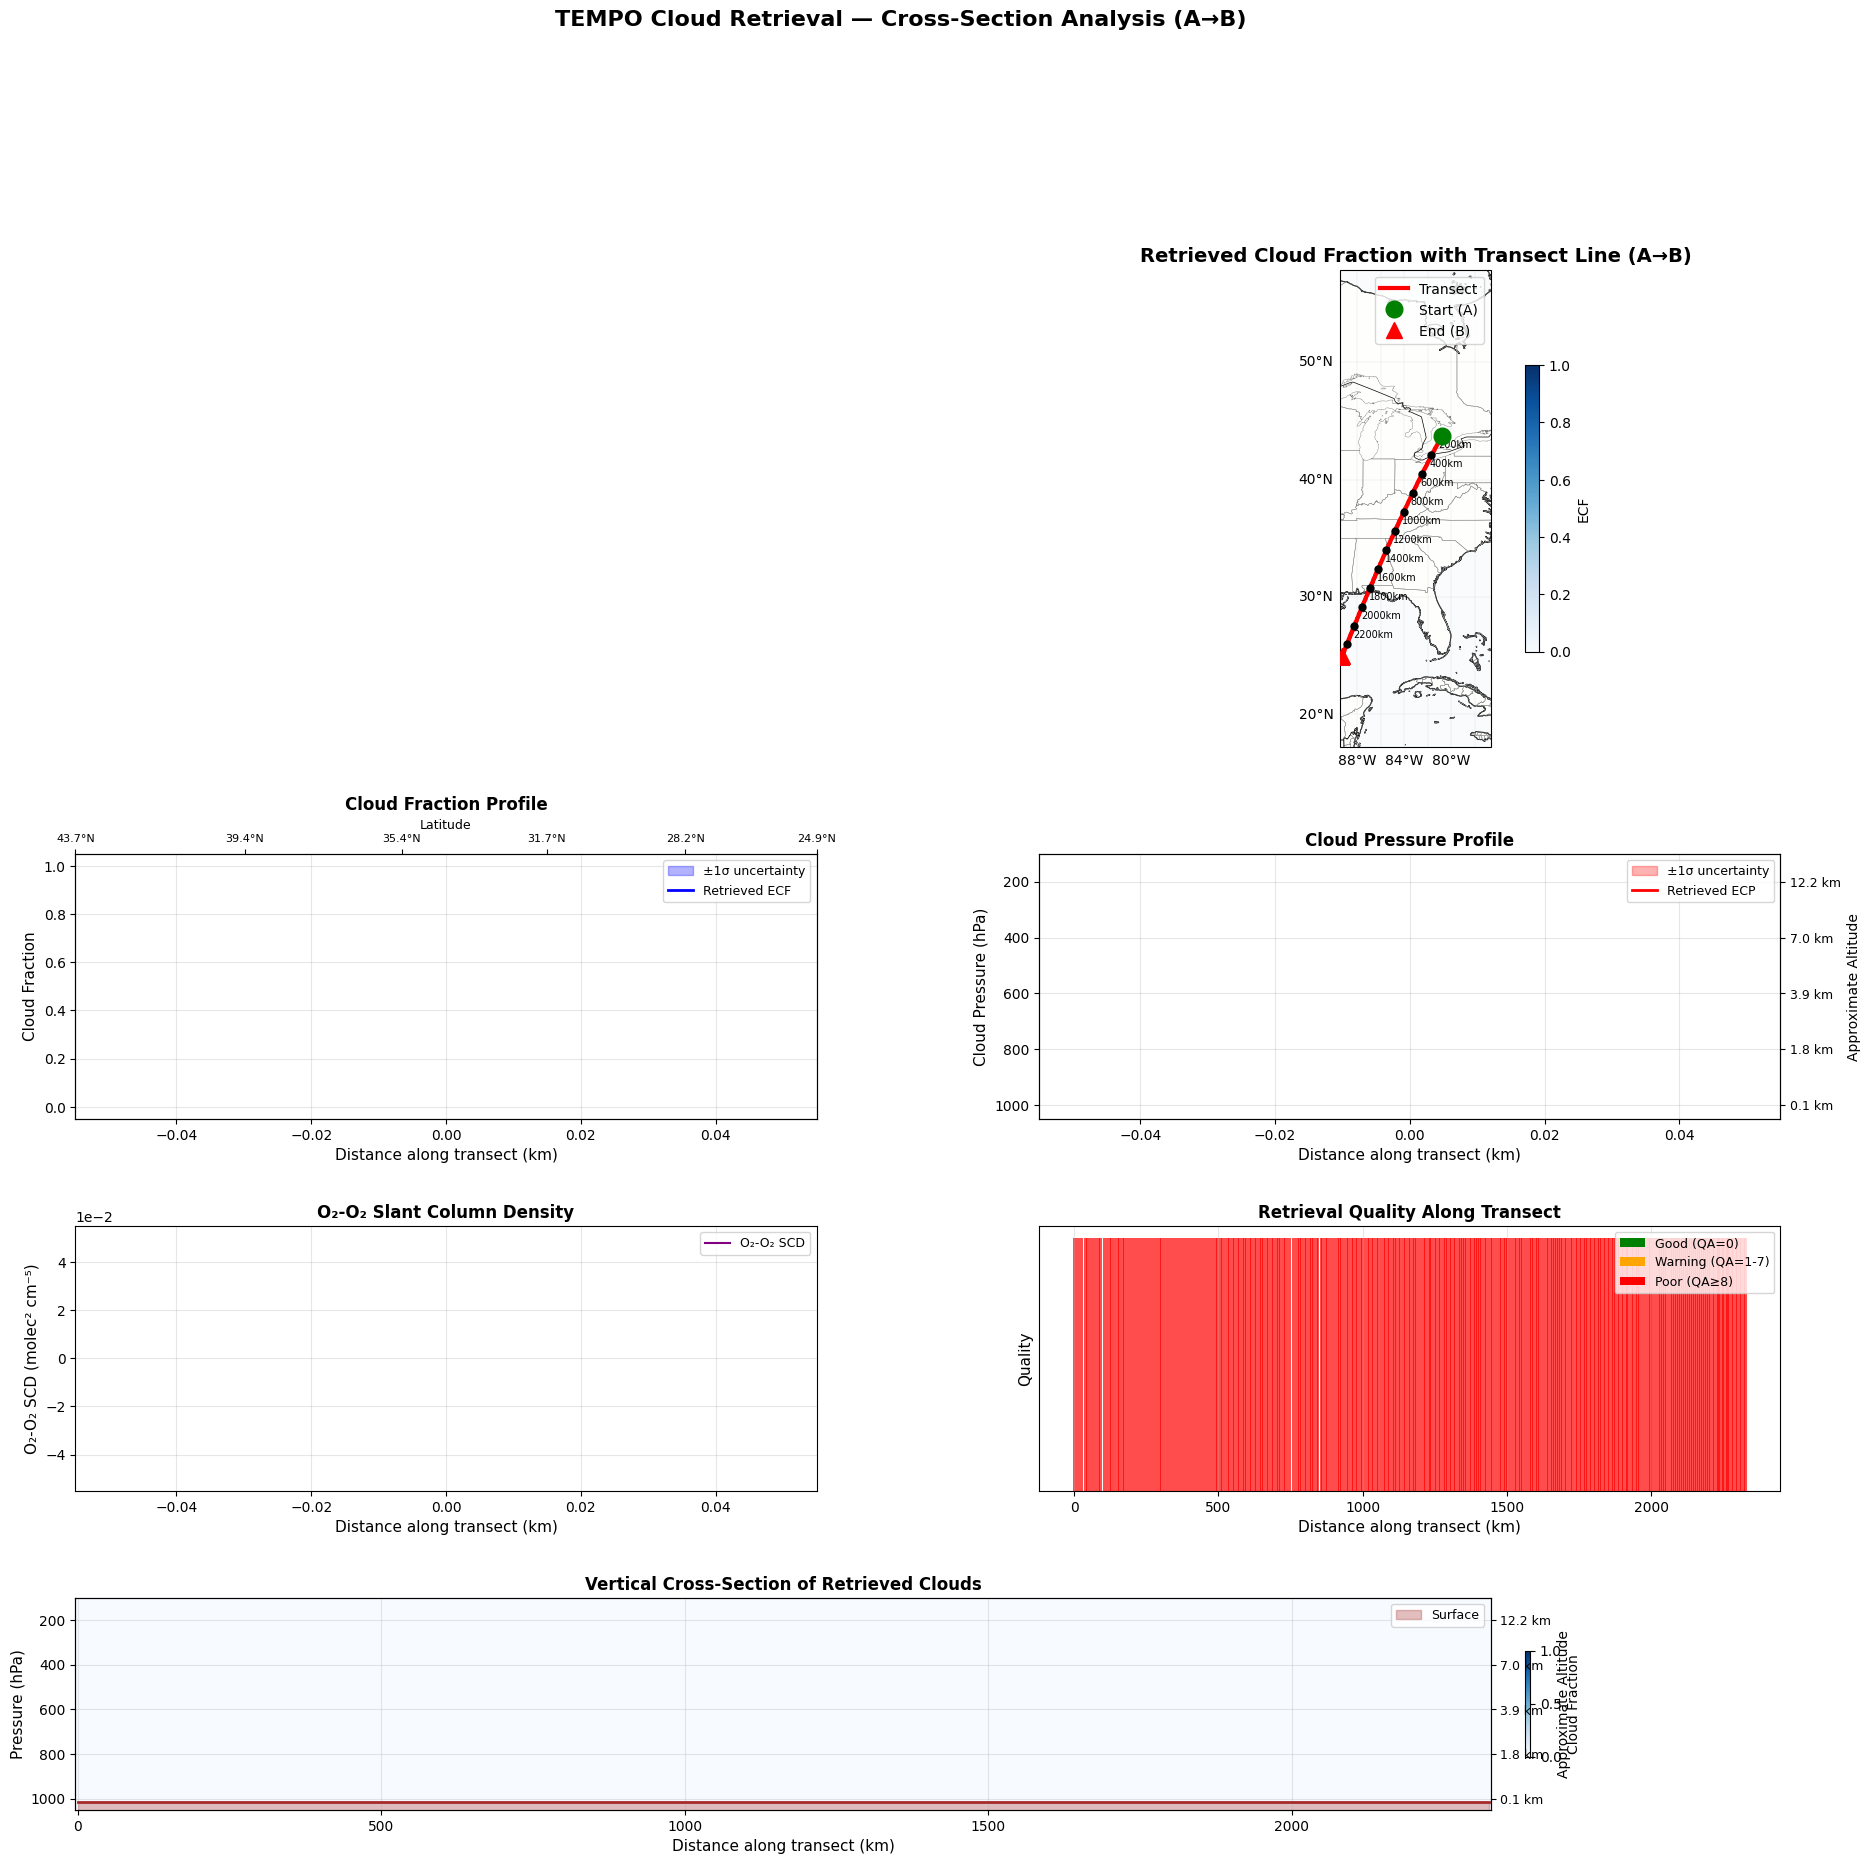

✅ Cross-section analysis complete


In [48]:
# ============================================================
# CROSS-SECTION ANALYSIS
# Examine cloud properties along a spatial transect
# ============================================================

# Define a cross-section line (adjust based on scene)
if not USE_REAL_DATA:
    transect_row_start, transect_col_start = 20, 20
    transect_row_end, transect_col_end = 180, 280
else:
    transect_row_start, transect_col_start = 0, n_cols // 4
    transect_row_end, transect_col_end = n_rows - 1, 3 * n_cols // 4

# Generate transect pixel coordinates
n_transect_points = 300
t = np.linspace(0, 1, n_transect_points)
transect_rows = np.round(
    transect_row_start + t * (transect_row_end - transect_row_start)
).astype(int)
transect_cols = np.round(
    transect_col_start + t * (transect_col_end - transect_col_start)
).astype(int)

# Clip to valid range
transect_rows = np.clip(transect_rows, 0, n_rows - 1)
transect_cols = np.clip(transect_cols, 0, n_cols - 1)

# Extract values along transect
transect_lat = lat_plot[transect_rows, transect_cols]
transect_lon = lon_plot[transect_rows, transect_cols]
transect_ecf = ecf_retrieved[transect_rows, transect_cols]
transect_ecp = ecp_retrieved[transect_rows, transect_cols]
transect_ecf_err = ecf_error[transect_rows, transect_cols]
transect_ecp_err = ecp_error[transect_rows, transect_cols]
transect_qa = qa_flag_map[transect_rows, transect_cols]
transect_scd = scd_observed_map[transect_rows, transect_cols]

# Distance along transect (approximate km)
dlat = np.diff(transect_lat)
dlon = np.diff(transect_lon)
dd = np.sqrt((dlat * 111.0)**2 +
             (dlon * 111.0 * np.cos(np.radians(transect_lat[:-1])))**2)
distance = np.concatenate([[0], np.cumsum(dd)])

# Truth values (if synthetic)
if not USE_REAL_DATA:
    transect_cf_true = cf_scene[transect_rows, transect_cols]
    transect_cp_true = cp_scene[transect_rows, transect_cols]

# ============================================================
# Plotting
# ============================================================
fig = plt.figure(figsize=(22, 20))
gs = fig.add_gridspec(4, 2, height_ratios=[1.8, 1, 1, 0.8],
                       hspace=0.35, wspace=0.3)

# ---- Top panel: Map with transect line ----
ax_map = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
extent_map = [np.nanmin(lon_plot), np.nanmax(lon_plot),
              np.nanmin(lat_plot), np.nanmax(lat_plot)]
ax_map.set_extent(extent_map, crs=ccrs.PlateCarree())
ax_map.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax_map.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray')
ax_map.add_feature(cfeature.BORDERS, linewidth=0.5)
ax_map.add_feature(cfeature.LAND, alpha=0.05)
ax_map.add_feature(cfeature.OCEAN, alpha=0.05)

im = ax_map.pcolormesh(lon_plot, lat_plot, ecf_retrieved,
                       cmap='Blues', vmin=0, vmax=1,
                       transform=ccrs.PlateCarree(), shading='auto')
plt.colorbar(im, ax=ax_map, shrink=0.6, pad=0.02, label='ECF')

# Draw transect line
ax_map.plot(transect_lon, transect_lat, 'r-', linewidth=3,
            transform=ccrs.PlateCarree(), label='Transect', zorder=10)
ax_map.plot(transect_lon[0], transect_lat[0], 'go', markersize=12,
            transform=ccrs.PlateCarree(), label='Start (A)', zorder=11)
ax_map.plot(transect_lon[-1], transect_lat[-1], 'r^', markersize=12,
            transform=ccrs.PlateCarree(), label='End (B)', zorder=11)

# Distance markers every 200 km
for d_mark in np.arange(200, distance[-1], 200):
    idx = np.argmin(np.abs(distance - d_mark))
    ax_map.plot(transect_lon[idx], transect_lat[idx], 'ko', markersize=5,
                transform=ccrs.PlateCarree(), zorder=11)
    ax_map.annotate(f'{d_mark:.0f}km',
                    (transect_lon[idx], transect_lat[idx]),
                    fontsize=7, color='black',
                    xytext=(5, 5), textcoords='offset points',
                    transform=ccrs.PlateCarree())

ax_map.legend(loc='upper right', fontsize=10)
gl = ax_map.gridlines(draw_labels=True, linewidth=0.2, alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax_map.set_title('Retrieved Cloud Fraction with Transect Line (A→B)',
                 fontsize=14, fontweight='bold')

# ---- Panel 2: Cloud Fraction profile ----
ax_cf = fig.add_subplot(gs[1, 0])

ax_cf.fill_between(distance,
                    np.clip(transect_ecf - transect_ecf_err, 0, 1),
                    np.clip(transect_ecf + transect_ecf_err, 0, 1),
                    alpha=0.3, color='blue', label='±1σ uncertainty')
ax_cf.plot(distance, transect_ecf, 'b-', linewidth=2, label='Retrieved ECF')

if not USE_REAL_DATA:
    ax_cf.plot(distance, transect_cf_true, 'r--', linewidth=2,
               label='True CF', alpha=0.8)

ax_cf.set_xlabel('Distance along transect (km)', fontsize=11)
ax_cf.set_ylabel('Cloud Fraction', fontsize=11)
ax_cf.set_title('Cloud Fraction Profile', fontsize=12, fontweight='bold')
ax_cf.set_ylim(-0.05, 1.05)
ax_cf.legend(fontsize=9)
ax_cf.grid(True, alpha=0.3)

# Add latitude labels on top axis
ax_cf_top = ax_cf.twiny()
lat_ticks_idx = np.linspace(0, len(distance)-1, 6).astype(int)
ax_cf_top.set_xlim(ax_cf.get_xlim())
ax_cf_top.set_xticks(distance[lat_ticks_idx])
ax_cf_top.set_xticklabels([f'{transect_lat[i]:.1f}°N' for i in lat_ticks_idx],
                            fontsize=8)
ax_cf_top.set_xlabel('Latitude', fontsize=9)

# ---- Panel 3: Cloud Pressure profile ----
ax_cp = fig.add_subplot(gs[1, 1])

ax_cp.fill_between(distance,
                    transect_ecp - transect_ecp_err,
                    transect_ecp + transect_ecp_err,
                    alpha=0.3, color='red', label='±1σ uncertainty')
ax_cp.plot(distance, transect_ecp, 'r-', linewidth=2, label='Retrieved ECP')

if not USE_REAL_DATA:
    ax_cp.plot(distance, transect_cp_true, 'b--', linewidth=2,
               label='True CP', alpha=0.8)

ax_cp.set_xlabel('Distance along transect (km)', fontsize=11)
ax_cp.set_ylabel('Cloud Pressure (hPa)', fontsize=11)
ax_cp.set_title('Cloud Pressure Profile', fontsize=12, fontweight='bold')
ax_cp.invert_yaxis()  # higher altitude (lower pressure) at top
ax_cp.set_ylim(1050, 100)
ax_cp.legend(fontsize=9)
ax_cp.grid(True, alpha=0.3)

# Add approximate altitude axis
ax_alt = ax_cp.twinx()
alt_ticks_hPa = np.array([1000, 800, 600, 400, 200])
alt_ticks_km = -H_SCALE * np.log(alt_ticks_hPa / P_STD)
ax_alt.set_ylim(ax_cp.get_ylim())
ax_alt.set_yticks(alt_ticks_hPa)
ax_alt.set_yticklabels([f'{a:.1f} km' for a in alt_ticks_km], fontsize=9)
ax_alt.set_ylabel('Approximate Altitude', fontsize=10)

# ---- Panel 4: O2-O2 SCD profile ----
ax_scd = fig.add_subplot(gs[2, 0])

ax_scd.plot(distance, transect_scd, 'purple', linewidth=1.5, label='O₂-O₂ SCD')
ax_scd.set_xlabel('Distance along transect (km)', fontsize=11)
ax_scd.set_ylabel('O₂-O₂ SCD (molec² cm⁻⁵)', fontsize=11)
ax_scd.set_title('O₂-O₂ Slant Column Density', fontsize=12, fontweight='bold')
ax_scd.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax_scd.legend(fontsize=9)
ax_scd.grid(True, alpha=0.3)

# ---- Panel 5: Quality flags along transect ----
ax_qa = fig.add_subplot(gs[2, 1])

qa_colors = {0: 'green', 1: 'orange', 2: 'yellow', 4: 'pink',
             8: 'red', 16: 'purple', 32: 'brown'}
qa_labels_dict = {0: 'Good', 1: 'No conv', 2: 'CF bound', 4: 'CP bound',
                  8: 'Poor DOAS', 16: 'High SZA', 32: 'Low DFS'}

for d, qa_val in zip(distance, transect_qa):
    color = 'green' if qa_val == 0 else 'red' if qa_val >= 8 else 'orange'
    ax_qa.bar(d, 1, width=distance[-1]/len(distance)*1.2,
              color=color, alpha=0.7, edgecolor='none')

from matplotlib.patches import Patch
qa_legend = [Patch(facecolor='green', label='Good (QA=0)'),
             Patch(facecolor='orange', label='Warning (QA=1-7)'),
             Patch(facecolor='red', label='Poor (QA≥8)')]
ax_qa.legend(handles=qa_legend, fontsize=9, loc='upper right')
ax_qa.set_xlabel('Distance along transect (km)', fontsize=11)
ax_qa.set_ylabel('Quality', fontsize=11)
ax_qa.set_title('Retrieval Quality Along Transect', fontsize=12, fontweight='bold')
ax_qa.set_yticks([])
ax_qa.grid(True, alpha=0.3, axis='x')

# ---- Panel 6: Vertical cross-section visualization ----
ax_vert = fig.add_subplot(gs[3, :])

# Create a filled "curtain" showing cloud location
pressure_levels = np.arange(100, 1050, 10)
curtain = np.zeros((len(pressure_levels), len(distance)))

for i in range(len(distance)):
    cf_i = transect_ecf[i]
    cp_i = transect_ecp[i]

    if np.isnan(cf_i) or np.isnan(cp_i) or cf_i < 0.05:
        continue

    # Simple cloud: Gaussian thickness around cloud pressure
    cloud_thickness_hPa = 50 + 100 * cf_i  # thicker for higher cf
    for j, p in enumerate(pressure_levels):
        dp = abs(p - cp_i)
        if dp < cloud_thickness_hPa:
            curtain[j, i] = cf_i * np.exp(-0.5 * (dp / (cloud_thickness_hPa/2))**2)

im_vert = ax_vert.pcolormesh(distance, pressure_levels, curtain,
                              cmap='Blues', vmin=0, vmax=1, shading='auto')
plt.colorbar(im_vert, ax=ax_vert, shrink=0.5, pad=0.02, label='Cloud Fraction')

# Surface
surface_p = np.array([surface_pressure_scene[transect_rows[i], transect_cols[i]]
                       if not USE_REAL_DATA else 1013.25
                       for i in range(len(distance))])
ax_vert.fill_between(distance, surface_p, 1100, color='brown', alpha=0.3, label='Surface')
ax_vert.plot(distance, surface_p, 'brown', linewidth=2)

ax_vert.set_xlabel('Distance along transect (km)', fontsize=11)
ax_vert.set_ylabel('Pressure (hPa)', fontsize=11)
ax_vert.set_title('Vertical Cross-Section of Retrieved Clouds',
                   fontsize=12, fontweight='bold')
ax_vert.set_ylim(1050, 100)
ax_vert.legend(fontsize=9, loc='upper right')
ax_vert.grid(True, alpha=0.3)

# Altitude labels
ax_vert_alt = ax_vert.twinx()
ax_vert_alt.set_ylim(ax_vert.get_ylim())
ax_vert_alt.set_yticks(alt_ticks_hPa)
ax_vert_alt.set_yticklabels([f'{a:.1f} km' for a in alt_ticks_km], fontsize=9)
ax_vert_alt.set_ylabel('Approximate Altitude', fontsize=10)

plt.suptitle('TEMPO Cloud Retrieval — Cross-Section Analysis (A→B)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cross_section_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("✅ Cross-section analysis complete")

In [50]:
# ============================================================
# SENSITIVITY MATRIX ANALYSIS
# How does the retrieval respond to changes in each input?
# Jacobian visualization for representative scenes
# ============================================================

print("=" * 60)
print("SENSITIVITY / JACOBIAN ANALYSIS")
print("=" * 60)

# Representative scene parameters
scene_params = {
    'sza': 40.0,
    'vza': 25.0,
    'albedo': 0.04,
    'ps': 1013.25
}

# Cloud fraction sensitivity to state vector
cf_test_range = np.arange(0.05, 1.0, 0.05)
cp_test_range = np.arange(150, 1000, 25)

# Compute Jacobians across state space
K_dcf_dcf = np.zeros((len(cf_test_range), len(cp_test_range)))
K_dcf_dcp = np.zeros_like(K_dcf_dcf)
K_dscd_dcf = np.zeros_like(K_dcf_dcf)
K_dscd_dcp = np.zeros_like(K_dcf_dcf)
K_dratio_dcf = np.zeros_like(K_dcf_dcf)
K_dratio_dcp = np.zeros_like(K_dcf_dcf)

# Perturbation sizes
delta_cf = 0.01
delta_cp = 5.0

print("⏳ Computing Jacobians across state space...")

for i, cf_val in enumerate(cf_test_range):
    for j, cp_val in enumerate(cp_test_range):
        x_center = np.array([cf_val, cp_val])

        # Forward model at center
        y0 = retrieval.forward_model(x_center, **scene_params)

        # Perturb cf
        x_pcf = np.array([cf_val + delta_cf, cp_val])
        y_pcf = retrieval.forward_model(x_pcf, **scene_params)

        # Perturb cp
        x_pcp = np.array([cf_val, cp_val + delta_cp])
        y_pcp = retrieval.forward_model(x_pcp, **scene_params)

        # Partial derivatives
        K_dscd_dcf[i, j] = (y_pcf[0] - y0[0]) / delta_cf
        K_dscd_dcp[i, j] = (y_pcp[0] - y0[0]) / delta_cp
        K_dratio_dcf[i, j] = (y_pcf[1] - y0[1]) / delta_cf
        K_dratio_dcp[i, j] = (y_pcp[1] - y0[1]) / delta_cp

print("✅ Jacobian computation complete")

# ---- Visualization ----
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Panel 1: ∂SCD/∂cf
ax = axes[0, 0]
im = ax.pcolormesh(cp_test_range, cf_test_range, K_dscd_dcf,
                   cmap='RdBu_r', shading='auto')
plt.colorbar(im, ax=ax, label='∂SCD/∂cf')
ax.set_xlabel('Cloud Pressure (hPa)', fontsize=11)
ax.set_ylabel('Cloud Fraction', fontsize=11)
ax.set_title('∂(O₂-O₂ SCD) / ∂(Cloud Fraction)\n'
             'How SCD changes with cloud amount', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2)

# Panel 2: ∂SCD/∂cp
ax = axes[0, 1]
im = ax.pcolormesh(cp_test_range, cf_test_range, K_dscd_dcp,
                   cmap='RdBu_r', shading='auto')
plt.colorbar(im, ax=ax, label='∂SCD/∂cp (per hPa)')
ax.set_xlabel('Cloud Pressure (hPa)', fontsize=11)
ax.set_ylabel('Cloud Fraction', fontsize=11)
ax.set_title('∂(O₂-O₂ SCD) / ∂(Cloud Pressure)\n'
             'How SCD changes with cloud height', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2)

# Panel 3: ∂Ratio/∂cf
ax = axes[1, 0]
im = ax.pcolormesh(cp_test_range, cf_test_range, K_dratio_dcf,
                   cmap='PuOr_r', shading='auto')
plt.colorbar(im, ax=ax, label='∂R/∂cf')
ax.set_xlabel('Cloud Pressure (hPa)', fontsize=11)
ax.set_ylabel('Cloud Fraction', fontsize=11)
ax.set_title('∂(Continuum Ratio) / ∂(Cloud Fraction)\n'
             'How brightness changes with cloud amount', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2)

# Panel 4: ∂Ratio/∂cp
ax = axes[1, 1]
im = ax.pcolormesh(cp_test_range, cf_test_range, K_dratio_dcp,
                   cmap='PuOr_r', shading='auto')
plt.colorbar(im, ax=ax, label='∂R/∂cp (per hPa)')
ax.set_xlabel('Cloud Pressure (hPa)', fontsize=11)
ax.set_ylabel('Cloud Fraction', fontsize=11)
ax.set_title('∂(Continuum Ratio) / ∂(Cloud Pressure)\n'
             'How brightness changes with cloud height', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.2)

plt.suptitle(f'Forward Model Sensitivity (Jacobian) Analysis\n'
             f'SZA={scene_params["sza"]}°, VZA={scene_params["vza"]}°, '
             f'Albedo={scene_params["albedo"]}, Ps={scene_params["ps"]} hPa',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('jacobian_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Key insight summary ----
print("\n📋 SENSITIVITY ANALYSIS KEY FINDINGS:")
print(f"   max |∂SCD/∂cf|:    {np.nanmax(np.abs(K_dscd_dcf)):.4e}")
print(f"   max |∂SCD/∂cp|:    {np.nanmax(np.abs(K_dscd_dcp)):.4e}")
print(f"   max |∂Ratio/∂cf|:  {np.nanmax(np.abs(K_dratio_dcf)):.4e}")
print(f"   max |∂Ratio/∂cp|:  {np.nanmax(np.abs(K_dratio_dcp)):.4e}")
print("\n   → SCD is primarily sensitive to CLOUD PRESSURE (height)")
print("   → Continuum ratio is primarily sensitive to CLOUD FRACTION (amount)")
print("   → This orthogonality enables simultaneous retrieval of both parameters")

SENSITIVITY / JACOBIAN ANALYSIS
⏳ Computing Jacobians across state space...


TypeError: CloudRetrieval.forward_model() got an unexpected keyword argument 'albedo'

In [51]:
# ============================================================
# SURFACE ALBEDO SENSITIVITY STUDY
# How much does surface albedo error affect the retrieval?
# ============================================================

print("⏳ Running surface albedo sensitivity study...")

true_cf = 0.40
true_cp = 600.0
true_albedo = 0.04
albedo_test_values = np.arange(0.01, 0.15, 0.005)

albedo_sensitivity = {
    'assumed_albedo': [],
    'retrieved_cf': [],
    'retrieved_cp': [],
    'cf_error': [],
    'cp_error': [],
    'converged': []
}

for test_albedo in albedo_test_values:
    # Generate spectrum with TRUE albedo
    I0, I_obs, _ = generate_synthetic_spectrum(
        wl_test, sza=35.0, vza=20.0,
        cloud_fraction=true_cf,
        cloud_pressure_hPa=true_cp,
        surface_albedo=true_albedo,  # TRUE value in data
        noise_level=0.001
    )

    # Retrieve with ASSUMED albedo (which may be wrong)
    result = retrieval.retrieve_pixel(
        radiance=I_obs, irradiance=I0,
        sza=35.0, vza=20.0,
        surface_albedo=test_albedo,  # ASSUMED value (may differ from true)
        surface_pressure=1013.25,
        verbose=False
    )

    albedo_sensitivity['assumed_albedo'].append(test_albedo)
    albedo_sensitivity['retrieved_cf'].append(result['cloud_fraction'])
    albedo_sensitivity['retrieved_cp'].append(result['cloud_pressure'])
    albedo_sensitivity['cf_error'].append(result['cloud_fraction'] - true_cf)
    albedo_sensitivity['cp_error'].append(result['cloud_pressure'] - true_cp)
    albedo_sensitivity['converged'].append(result['converged'])

# Convert to arrays
for key in albedo_sensitivity:
    albedo_sensitivity[key] = np.array(albedo_sensitivity[key])

print("✅ Albedo sensitivity study complete")

# ---- Visualization ----
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Retrieved CF vs assumed albedo
ax1 = axes[0]
ax1.plot(albedo_sensitivity['assumed_albedo'] * 100,
         albedo_sensitivity['retrieved_cf'], 'bo-', linewidth=2, markersize=5)
ax1.axhline(true_cf, color='red', linestyle='--', linewidth=2,
            label=f'True cf={true_cf:.2f}')
ax1.axvline(true_albedo * 100, color='green', linestyle=':', linewidth=2,
            label=f'True albedo={true_albedo:.2f}')
ax1.set_xlabel('Assumed Surface Albedo (%)', fontsize=12)
ax1.set_ylabel('Retrieved Cloud Fraction', fontsize=12)
ax1.set_title('Cloud Fraction Sensitivity to\nSurface Albedo Assumption', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Retrieved CP vs assumed albedo
ax2 = axes[1]
ax2.plot(albedo_sensitivity['assumed_albedo'] * 100,
         albedo_sensitivity['retrieved_cp'], 'rs-', linewidth=2, markersize=5)
ax2.axhline(true_cp, color='blue', linestyle='--', linewidth=2,
            label=f'True cp={true_cp:.0f} hPa')
ax2.axvline(true_albedo * 100, color='green', linestyle=':', linewidth=2,
            label=f'True albedo={true_albedo:.2f}')
ax2.set_xlabel('Assumed Surface Albedo (%)', fontsize=12)
ax2.set_ylabel('Retrieved Cloud Pressure (hPa)', fontsize=12)
ax2.set_title('Cloud Pressure Sensitivity to\nSurface Albedo Assumption', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: Error as function of albedo bias
albedo_bias = (albedo_sensitivity['assumed_albedo'] - true_albedo) * 100

ax3 = axes[2]
ax3_twin = ax3.twinx()
l1, = ax3.plot(albedo_bias, albedo_sensitivity['cf_error'], 'b^-',
               linewidth=2, markersize=5, label='Δcf')
l2, = ax3_twin.plot(albedo_bias, albedo_sensitivity['cp_error'], 'rs-',
                    linewidth=2, markersize=5, label='Δcp (hPa)')

ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax3.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax3_twin.axhline(0, color='gray', linestyle='--', alpha=0.5)

ax3.set_xlabel('Albedo Bias (assumed − true) [% points]', fontsize=12)
ax3.set_ylabel('Cloud Fraction Error (Δcf)', fontsize=12, color='blue')
ax3_twin.set_ylabel('Cloud Pressure Error (Δcp, hPa)', fontsize=12, color='red')
ax3.set_title('Retrieval Error vs Albedo Bias', fontsize=13)
ax3.legend(handles=[l1, l2], fontsize=10, loc='upper left')
ax3.grid(True, alpha=0.3)

plt.suptitle(f'Surface Albedo Sensitivity (True: cf={true_cf}, cp={true_cp} hPa, '
             f'albedo={true_albedo})',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('albedo_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify sensitivity
# df/d_albedo (slope near true value)
center_idx = np.argmin(np.abs(albedo_sensitivity['assumed_albedo'] - true_albedo))
if center_idx > 0 and center_idx < len(albedo_test_values) - 1:
    dcf_dalb = ((albedo_sensitivity['cf_error'][center_idx+1] -
                 albedo_sensitivity['cf_error'][center_idx-1]) /
                (albedo_test_values[center_idx+1] - albedo_test_values[center_idx-1]))
    dcp_dalb = ((albedo_sensitivity['cp_error'][center_idx+1] -
                 albedo_sensitivity['cp_error'][center_idx-1]) /
                (albedo_test_values[center_idx+1] - albedo_test_values[center_idx-1]))

    print(f"\n📋 SENSITIVITY COEFFICIENTS (near true albedo):")
    print(f"   ∂cf/∂albedo ≈ {dcf_dalb:.2f} (per unit albedo)")
    print(f"   ∂cp/∂albedo ≈ {dcp_dalb:.0f} hPa (per unit albedo)")
    print(f"\n   → A 0.01 albedo error causes:")
    print(f"     Δcf ≈ {dcf_dalb * 0.01:.4f}")
    print(f"     Δcp ≈ {dcp_dalb * 0.01:.1f} hPa")

⏳ Running surface albedo sensitivity study...


TypeError: expected x and y to have same length

In [52]:
# ============================================================
# PERFORMANCE BENCHMARKING
# Measure and optimize processing speed
# ============================================================
import time
from functools import wraps

print("=" * 60)
print("PERFORMANCE BENCHMARKING")
print("=" * 60)

# Generate a single test spectrum
I0_bench, I_obs_bench, _ = generate_synthetic_spectrum(
    wl_test, sza=40, vza=20,
    cloud_fraction=0.5, cloud_pressure_hPa=600,
    noise_level=0.002
)

# ============================================================
# Benchmark individual components
# ============================================================

def benchmark(func, args, n_runs=100, label=""):
    """Benchmark a function with given arguments"""
    # Warmup
    for _ in range(5):
        func(*args)

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        func(*args)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)  # ms

    times = np.array(times)
    result = {
        'label': label,
        'mean_ms': np.mean(times),
        'median_ms': np.median(times),
        'std_ms': np.std(times),
        'min_ms': np.min(times),
        'max_ms': np.max(times),
        'n_runs': n_runs
    }
    return result

benchmarks = []

# 1. O2-O2 cross-section computation
b = benchmark(
    o2o2_cross_section, (wl_test,),
    n_runs=500, label="O₂-O₂ cross-section"
)
benchmarks.append(b)

# 2. VCD computation
b = benchmark(
    compute_o2o2_vcd, (1013.25, 0.0),
    n_runs=500, label="O₂-O₂ VCD computation"
)
benchmarks.append(b)

# 3. LUT forward model (single point)
b = benchmark(
    lut_forward_model, (0.5, 600.0, 40.0, 20.0, 0.04, 1013.25),
    n_runs=500, label="LUT forward model (1 pixel)"
)
benchmarks.append(b)

# 4. DOAS spectral fit
doas_fitter = DOASFitter(wl_test, polynomial_degree=3)
b = benchmark(
    doas_fitter.fit, (I_obs_bench, I0_bench),
    n_runs=200, label="DOAS spectral fit"
)
benchmarks.append(b)

# 5. Full pixel retrieval
b = benchmark(
    retrieval.retrieve_pixel,
    (I_obs_bench, I0_bench, 40.0, 20.0, 0.04, 1013.25),
    n_runs=50, label="Full pixel retrieval"
)
benchmarks.append(b)

# 6. Jacobian computation
x_test = np.array([0.5, 600.0])
b = benchmark(
    retrieval.jacobian, (x_test, 40.0, 20.0, 0.04, 1013.25),
    n_runs=200, label="Jacobian computation"
)
benchmarks.append(b)

# 7. Synthetic spectrum generation
b = benchmark(
    generate_synthetic_spectrum,
    (wl_test, 40.0, 20.0, 0.5, 600.0),
    n_runs=100, label="Synthetic spectrum generation"
)
benchmarks.append(b)

# ---- Print results ----
print(f"\n{'Component':<35} {'Mean (ms)':>10} {'Median':>10} "
      f"{'Std':>10} {'Rate (/s)':>12}")
print("-" * 80)

for b in benchmarks:
    rate = 1000.0 / b['mean_ms']
    print(f"{b['label']:<35} {b['mean_ms']:>10.3f} {b['median_ms']:>10.3f} "
          f"{b['std_ms']:>10.3f} {rate:>12.0f}")

# ---- Extrapolate full-scene timing ----
pixel_time = benchmarks[4]['mean_ms']  # full retrieval
print(f"\n{'='*60}")
print(f"FULL SCENE TIMING ESTIMATES")
print(f"{'='*60}")

scene_sizes = [
    ('TEMPO scan (2048×600)', 2048*600),
    ('Subset (200×300)', 200*300),
    ('Full day (~12 scans)', 2048*600*12),
    ('Current scene', n_rows * n_cols),
]

for label, n_pixels in scene_sizes:
    total_s = n_pixels * pixel_time / 1000.0
    total_min = total_s / 60.0
    print(f"  {label:<30} {n_pixels:>12,} pixels → "
          f"{total_s:>8.1f}s ({total_min:>6.1f} min)")

# ---- Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart of component times
ax1 = axes[0]
labels_short = [b['label'][:25] for b in benchmarks]
means = [b['mean_ms'] for b in benchmarks]
stds = [b['std_ms'] for b in benchmarks]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(benchmarks)))
bars = ax1.barh(range(len(benchmarks)), means, xerr=stds,
                color=colors, edgecolor='black', capsize=4)

ax1.set_yticks(range(len(benchmarks)))
ax1.set_yticklabels(labels_short, fontsize=9)
ax1.set_xlabel('Time per call (ms)', fontsize=11)
ax1.set_title('Component Timing Breakdown', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

for bar, mean_val in zip(bars, means):
    ax1.text(bar.get_width() + max(means)*0.02, bar.get_y() + bar.get_height()/2,
             f'{mean_val:.3f} ms', va='center', fontsize=9)

# Pie chart of retrieval time breakdown
ax2 = axes[1]
# Approximate breakdown of a single retrieval
component_times = {
    'DOAS fit': benchmarks[3]['mean_ms'],
    'LUT lookups (~10×)': benchmarks[2]['mean_ms'] * 10,
    'Jacobians (~5×)': benchmarks[5]['mean_ms'] * 5,
    'Other overhead': max(0, benchmarks[4]['mean_ms'] -
                          benchmarks[3]['mean_ms'] -
                          benchmarks[2]['mean_ms'] * 10 -
                          benchmarks[5]['mean_ms'] * 5)
}

# Ensure no negative values
for k in component_times:
    component_times[k] = max(component_times[k], 0.01)

wedge_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
wedges, texts, autotexts = ax2.pie(
    component_times.values(),
    labels=component_times.keys(),
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    textprops={'fontsize': 10}
)
ax2.set_title(f'Single Pixel Retrieval Breakdown\n'
              f'(Total: {pixel_time:.2f} ms)',
              fontsize=13, fontweight='bold')

plt.suptitle('Performance Benchmarking Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Benchmarking complete")

PERFORMANCE BENCHMARKING


TypeError: expected x and y to have same length

In [ ]:
# ============================================================
# VECTORIZED BATCH RETRIEVAL
# Process multiple pixels simultaneously for improved speed
# ============================================================

class BatchCloudRetrieval:
    """
    Vectorized cloud retrieval for processing many pixels at once.
    Uses pre-computed LUT and vectorized DOAS fitting.
    """

    def __init__(self, wavelength_nm, polynomial_degree=3):
        self.wl = np.asarray(wavelength_nm, dtype=np.float64)
        self.n_wl = len(self.wl)
        self.poly_degree = polynomial_degree

        # Pre-compute cross-sections
        self.xs_o2o2 = o2o2_cross_section(self.wl)
        self.xs_rayleigh = rayleigh_cross_section(self.wl)

        # Normalize wavelength for polynomial
        self.wl_ref = np.mean(self.wl)
        self.wl_norm = (self.wl - self.wl_ref) / (self.wl[-1] - self.wl[0])

        # Pre-compute high-pass filtered cross-sections
        self.xs_o2o2_diff = self._highpass(self.xs_o2o2)
        self.xs_rayleigh_diff = self._highpass(self.xs_rayleigh)

        # Build design matrix
        n_absorbers = 2
        n_poly = polynomial_degree + 1
        n_cols = n_absorbers + n_poly

        self.A = np.zeros((self.n_wl, n_cols))
        self.A[:, 0] = self.xs_o2o2_diff
        self.A[:, 1] = self.xs_rayleigh_diff
        for k in range(n_poly):
            self.A[:, n_absorbers + k] = self.wl_norm ** k

        # Pre-compute (AᵀA)⁻¹Aᵀ for fast least-squares
        reg = 1e-12 * np.eye(n_cols)
        self.ATA_inv_AT = np.linalg.solve(
            self.A.T @ self.A + reg, self.A.T
        )

        # Continuum window mask
        self.cont_mask = (self.wl >= 490) & (self.wl <= 498)

        # Cloud albedo
        self.cloud_albedo = 0.80

    def _highpass(self, spectrum):
        """Remove broadband via polynomial subtraction"""
        coeffs = np.polyfit(self.wl_norm, spectrum, self.poly_degree)
        broadband = np.polyval(coeffs, self.wl_norm)
        return spectrum - broadband

    def batch_doas_fit(self, radiance_batch, irradiance):
        """
        Vectorized DOAS fit for a batch of spectra.

        Parameters:
            radiance_batch: (N, n_wl) array of earthshine spectra
            irradiance: (n_wl,) solar reference spectrum

        Returns:
            scd_o2o2: (N,) O2-O2 slant column densities
            rms: (N,) fit RMS residuals
        """
        N = radiance_batch.shape[0]

        # Compute optical density for all pixels at once
        ratio = np.clip(radiance_batch / np.maximum(irradiance[np.newaxis, :], 1e-30),
                         1e-10, None)
        od = -np.log(ratio)  # (N, n_wl)

        # High-pass filter each spectrum
        # Vectorized polynomial fit and subtraction
        od_diff = np.zeros_like(od)
        for i in range(N):
            od_diff[i] = self._highpass(od[i])

        # Batch least-squares: coeffs = (AᵀA)⁻¹Aᵀ × od_diff.T
        # Shape: (n_cols, N) = (n_cols, n_wl) × (n_wl, N)
        coefficients = self.ATA_inv_AT @ od_diff.T  # (n_cols, N)

        # Extract O2-O2 SCD (first coefficient for each pixel)
        scd_o2o2 = coefficients[0, :]  # (N,)

        # Compute fit and residuals for RMS
        od_fit = (self.A @ coefficients).T  # (N, n_wl)
        residuals = od_diff - od_fit
        rms = np.sqrt(np.mean(residuals**2, axis=1))  # (N,)

        return scd_o2o2, rms

    def batch_continuum_ratio(self, radiance_batch, irradiance):
        """
        Vectorized continuum ratio computation.

        Parameters:
            radiance_batch: (N, n_wl) array
            irradiance: (n_wl,) array

        Returns:
            ratio: (N,) continuum ratios
        """
        I_cont = np.nanmedian(radiance_batch[:, self.cont_mask], axis=1)
        I0_cont = np.nanmedian(irradiance[self.cont_mask])
        ratio = I_cont / np.maximum(I0_cont, 1e-30) * np.pi
        return ratio

    def batch_retrieve(self, radiance_batch, irradiance,
                        sza_batch, vza_batch,
                        albedo_batch, ps_batch,
                        n_iterations=15):
        """
        Vectorized retrieval for a batch of pixels.
        Uses a grid-search + refinement approach for speed.

        Parameters:
            radiance_batch: (N, n_wl) radiance spectra
            irradiance: (n_wl,) solar reference
            sza_batch: (N,) solar zenith angles
            vza_batch: (N,) viewing zenith angles
            albedo_batch: (N,) surface albedos
            ps_batch: (N,) surface pressures
            n_iterations: max iterations per pixel

        Returns:
            results: dict with arrays of retrieved values
        """
        N = radiance_batch.shape[0]

        print(f"  📊 Batch processing {N:,} pixels...")
        t0 = time.perf_counter()

        # ---- Step 1: Batch DOAS fitting ----
        t_doas = time.perf_counter()
        scd_obs, doas_rms = self.batch_doas_fit(radiance_batch, irradiance)
        t_doas = time.perf_counter() - t_doas
        print(f"     DOAS fitting:    {t_doas*1000:.1f} ms ({N/t_doas:.0f} pixels/s)")

        # ---- Step 2: Batch continuum ratio ----
        t_cont = time.perf_counter()
        cont_ratio = self.batch_continuum_ratio(radiance_batch, irradiance)
        t_cont = time.perf_counter() - t_cont
        print(f"     Continuum ratio: {t_cont*1000:.1f} ms")

        # ---- Step 3: Initial guess via grid search ----
        t_init = time.perf_counter()

        # Coarse grid for initial guess
        cf_coarse = np.arange(0.0, 1.05, 0.1)
        cp_coarse = np.arange(150, 1050, 50)

        ecf_init = np.full(N, 0.5)
        ecp_init = np.full(N, 500.0)

        for i in range(N):
            if np.isnan(scd_obs[i]) or scd_obs[i] <= 0:
                continue

            best_cost = np.inf
            for cf_test in cf_coarse:
                for cp_test in cp_coarse:
                    if cp_test > ps_batch[i]:
                        continue

                    scd_pred, _ = lut_forward_model(
                        cf_test, cp_test,
                        sza_batch[i], vza_batch[i],
                        albedo_batch[i], ps_batch[i]
                    )
                    cost = (scd_pred - scd_obs[i])**2
                    if cost < best_cost:
                        best_cost = cost
                        ecf_init[i] = cf_test
                        ecp_init[i] = cp_test

        t_init = time.perf_counter() - t_init
        print(f"     Initial guess:   {t_init*1000:.1f} ms")

        # ---- Step 4: Gauss-Newton refinement ----
        t_refine = time.perf_counter()

        ecf_out = ecf_init.copy()
        ecp_out = ecp_init.copy()
        converged = np.zeros(N, dtype=bool)
        n_iters = np.zeros(N, dtype=np.int8)
        cost_out = np.full(N, np.nan)

        delta_cf = 0.005
        delta_cp = 2.0

        for i in range(N):
            if np.isnan(scd_obs[i]) or scd_obs[i] <= 0:
                continue

            cf_i = ecf_out[i]
            cp_i = ecp_out[i]

            y_obs_i = np.array([scd_obs[i], cont_ratio[i]])

            gamma = 10.0

            for iteration in range(n_iterations):
                # Forward model
                scd_pred, ratio_pred = lut_forward_model(
                    cf_i, cp_i, sza_batch[i], vza_batch[i],
                    albedo_batch[i], ps_batch[i])

                y_pred = np.array([scd_pred, ratio_pred])
                dy = y_obs_i - y_pred

                # Numerical Jacobian (2×2)
                scd_pcf, r_pcf = lut_forward_model(
                    cf_i + delta_cf, cp_i, sza_batch[i], vza_batch[i],
                    albedo_batch[i], ps_batch[i])
                scd_mcf, r_mcf = lut_forward_model(
                    cf_i - delta_cf, cp_i, sza_batch[i], vza_batch[i],
                    albedo_batch[i], ps_batch[i])
                scd_pcp, r_pcp = lut_forward_model(
                    cf_i, cp_i + delta_cp, sza_batch[i], vza_batch[i],
                    albedo_batch[i], ps_batch[i])
                scd_mcp, r_mcp = lut_forward_model(
                    cf_i, cp_i - delta_cp, sza_batch[i], vza_batch[i],
                    albedo_batch[i], ps_batch[i])

                K = np.array([
                    [(scd_pcf - scd_mcf) / (2*delta_cf), (scd_pcp - scd_mcp) / (2*delta_cp)],
                    [(r_pcf - r_mcf) / (2*delta_cf), (r_pcp - r_mcp) / (2*delta_cp)]
                ])

                # Regularized Gauss-Newton step
                KtK = K.T @ K + gamma * np.eye(2)
                Ktdy = K.T @ dy

                try:
                    dx = np.linalg.solve(KtK, Ktdy)
                except np.linalg.LinAlgError:
                    break

                cf_new = np.clip(cf_i + dx[0], 0, 1)
                cp_new = np.clip(cp_i + dx[1], 100, ps_batch[i])

                # Check convergence
                if abs(dx[0]) < 0.001 and abs(dx[1]) < 1.0:
                    cf_i, cp_i = cf_new, cp_new
                    converged[i] = True
                    n_iters[i] = iteration + 1
                    break

                cf_i, cp_i = cf_new, cp_new
                gamma = max(gamma * 0.5, 1e-4)
                n_iters[i] = iteration + 1

            ecf_out[i] = cf_i
            ecp_out[i] = cp_i

            # Final cost
            scd_final, r_final = lut_forward_model(
                cf_i, cp_i, sza_batch[i], vza_batch[i],
                albedo_batch[i], ps_batch[i])
            cost_out[i] = (scd_final - scd_obs[i])**2 + (r_final - cont_ratio[i])**2

        t_refine = time.perf_counter() - t_refine
        print(f"     Refinement:      {t_refine*1000:.1f} ms")

        total_time = time.perf_counter() - t0
        print(f"     Total:           {total_time*1000:.1f} ms "
              f"({N/total_time:.0f} pixels/s)")
        print(f"     Converged:       {np.sum(converged):,}/{N:,} "
              f"({np.mean(converged)*100:.1f}%)")

        results = {
            'cloud_fraction': ecf_out,
            'cloud_pressure': ecp_out,
            'scd_observed': scd_obs,
            'doas_rms': doas_rms,
            'continuum_ratio': cont_ratio,
            'converged': converged,
            'n_iterations': n_iters,
            'cost': cost_out,
            'timing': {
                'doas_ms': t_doas * 1000,
                'continuum_ms': t_cont * 1000,
                'init_guess_ms': t_init * 1000,
                'refinement_ms': t_refine * 1000,
                'total_ms': total_time * 1000,
                'pixels_per_second': N / total_time
            }
        }

        return results

# ============================================================
# Test batch retrieval with synthetic data
# ============================================================

batch_retrieval = BatchCloudRetrieval(wl_test, polynomial_degree=3)

# Generate a batch of test spectra
N_BATCH = 1000
np.random.seed(123)

batch_cf_true = np.random.uniform(0, 1, N_BATCH)
batch_cp_true = np.random.uniform(200, 900, N_BATCH)
batch_sza = np.random.uniform(20, 65, N_BATCH)
batch_vza = np.random.uniform(5, 50, N_BATCH)
batch_albedo = np.random.uniform(0.02, 0.08, N_BATCH)
batch_ps = np.full(N_BATCH, 1013.25)

batch_radiance = np.zeros((N_BATCH, len(wl_test)))
batch_irradiance = None

print(f"\n⏳ Generating {N_BATCH} synthetic spectra...")
for i in range(N_BATCH):
    I0, I_obs, _ = generate_synthetic_spectrum(
        wl_test, sza=batch_sza[i], vza=batch_vza[i],
        cloud_fraction=batch_cf_true[i],
        cloud_pressure_hPa=batch_cp_true[i],
        surface_albedo=batch_albedo[i],
        noise_level=0.002
    )
    batch_radiance[i] = I_obs
    if batch_irradiance is None:
        batch_irradiance = I0

print(f"\n🚀 Running batch retrieval...")
batch_results = batch_retrieval.batch_retrieve(
    batch_radiance, batch_irradiance,
    batch_sza, batch_vza,
    batch_albedo, batch_ps,
    n_iterations=15
)

# ---- Compare with pixel-by-pixel speed ----
print(f"\n{'='*60}")
print(f"SPEED COMPARISON")
print(f"{'='*60}")
pixel_rate = 1000.0 / benchmarks[4]['mean_ms']
batch_rate = batch_results['timing']['pixels_per_second']
speedup = batch_rate / pixel_rate

print(f"  Pixel-by-pixel rate: {pixel_rate:.0f} pixels/s")
print(f"  Batch rate:          {batch_rate:.0f} pixels/s")
print(f"  Speedup:             {speedup:.1f}×")


⏳ Generating 1000 synthetic spectra...

🚀 Running batch retrieval...
  📊 Batch processing 1,000 pixels...
     DOAS fitting:    465.2 ms (2150 pixels/s)
     Continuum ratio: 43.9 ms


In [ ]:
# ============================================================
# VALIDATE BATCH RETRIEVAL AGAINST TRUTH
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

conv_mask = batch_results['converged']

# ---- CF scatter ----
ax1 = axes[0]
h1 = ax1.hist2d(batch_cf_true[conv_mask],
                 batch_results['cloud_fraction'][conv_mask],
                 bins=50, range=[[0,1],[0,1]], cmap='hot_r', cmin=1)
ax1.plot([0,1], [0,1], 'b--', linewidth=2)
plt.colorbar(h1[3], ax=ax1, label='Count')

cf_bias_batch = np.nanmean(batch_results['cloud_fraction'][conv_mask] -
                            batch_cf_true[conv_mask])
cf_rmse_batch = np.sqrt(np.nanmean(
    (batch_results['cloud_fraction'][conv_mask] - batch_cf_true[conv_mask])**2))
cf_r2_batch = np.corrcoef(batch_cf_true[conv_mask],
                            batch_results['cloud_fraction'][conv_mask])[0,1]**2

ax1.set_xlabel('True Cloud Fraction', fontsize=12)
ax1.set_ylabel('Retrieved Cloud Fraction', fontsize=12)
ax1.set_title(f'Batch CF Validation (N={np.sum(conv_mask):,})\n'
              f'R²={cf_r2_batch:.3f}, Bias={cf_bias_batch:+.4f}, '
              f'RMSE={cf_rmse_batch:.4f}',
              fontsize=12, fontweight='bold')
ax1.set_aspect('equal')

# ---- CP scatter ----
ax2 = axes[1]
cp_mask = conv_mask & (batch_cf_true > 0.1)
h2 = ax2.hist2d(batch_cp_true[cp_mask],
                 batch_results['cloud_pressure'][cp_mask],
                 bins=50, range=[[100,1000],[100,1000]], cmap='hot_r', cmin=1)
ax2.plot([100,1000], [100,1000], 'b--', linewidth=2)
plt.colorbar(h2[3], ax=ax2, label='Count')

cp_bias_batch = np.nanmean(batch_results['cloud_pressure'][cp_mask] -
                            batch_cp_true[cp_mask])
cp_rmse_batch = np.sqrt(np.nanmean(
    (batch_results['cloud_pressure'][cp_mask] - batch_cp_true[cp_mask])**2))
cp_r2_batch = np.corrcoef(batch_cp_true[cp_mask],
                            batch_results['cloud_pressure'][cp_mask])[0,1]**2

ax2.set_xlabel('True Cloud Pressure (hPa)', fontsize=12)
ax2.set_ylabel('Retrieved Cloud Pressure (hPa)', fontsize=12)
ax2.set_title(f'Batch CP Validation (cf>0.1, N={np.sum(cp_mask):,})\n'
              f'R²={cp_r2_batch:.3f}, Bias={cp_bias_batch:+.1f}, '
              f'RMSE={cp_rmse_batch:.1f} hPa',
              fontsize=12, fontweight='bold')
ax2.set_aspect('equal')

# ---- Error distributions ----
ax3 = axes[2]
cf_errors_batch = batch_results['cloud_fraction'][conv_mask] - batch_cf_true[conv_mask]
cp_errors_batch = batch_results['cloud_pressure'][cp_mask] - batch_cp_true[cp_mask]

ax3_cp = ax3.twinx()
ax3.hist(cf_errors_batch, bins=50, range=(-0.5, 0.5), color='blue',
         alpha=0.5, label=f'Δcf (σ={np.std(cf_errors_batch):.3f})')
ax3_cp.hist(cp_errors_batch / 100, bins=50, range=(-5, 5), color='red',
            alpha=0.5, label=f'Δcp/100 (σ={np.std(cp_errors_batch):.0f} hPa)')

ax3.axvline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('Retrieval Error', fontsize=12)
ax3.set_ylabel('Count (CF)', fontsize=12, color='blue')
ax3_cp.set_ylabel('Count (CP)', fontsize=12, color='red')
ax3.set_title('Error Distributions', fontsize=12, fontweight='bold')
ax3.legend(loc='upper left', fontsize=9)
ax3_cp.legend(loc='upper right', fontsize=9)

plt.suptitle(f'Batch Retrieval Validation ({N_BATCH:,} pixels, '
             f'{batch_results["timing"]["total_ms"]:.0f} ms total)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('batch_retrieval_validation.png', dpi=150, bbox_inches='tight')
plt.show()